# Causal Reasoning in Dynamical Systems with NumPyro and Diffrax

Many systems in epidemiology, physics and engineering are described by ordinary differential equations (ODEs). The equations carry causal knowledge: they say how a change in one variable changes the others over time. But an ODE is not a causal graph, so the usual tools of causal inference, like the do-calculus, do not apply to it directly. [ChiRho](https://basisresearch.github.io/chirho/) extends the semantics of interventions to ODEs. Intervening on the system at time $t$ means simulating up to $t$, modifying the state, and simulating forward from the modified state. With this semantics a differential equation becomes a probabilistic program in which we can condition on data and intervene, like in any other model.

In this notebook we port two ChiRho tutorials to [NumPyro](https://num.pyro.ai/), with [Diffrax](https://docs.kidger.site/diffrax/) as the ODE solver. The first one, [Causal reasoning in dynamical systems](https://basisresearch.github.io/chirho/dynamical_intro.html), fits an SIR epidemic model to two weeks of daily measurements and predicts the effect of lockdowns that start at fixed, uncertain or state-dependent times. The second one, [Hierarchical Bayesian models with dynamical systems](https://basisresearch.github.io/chirho/dynamical_multi.html), fits the same model to three towns whose rates are drawn from shared distributions, so that measurements in one town inform the predictions for the other two.

Why port them? NumPyro already has the effect handlers that carry the vocabulary of the tutorials: `condition` attaches the measurements, and `seed` and `trace` draw synthetic data. What it lacks is a simulator that stops at an event and modifies the state. We write one in a little over a hundred lines on top of Diffrax, and JAX gives us the rest. The simulator is compiled once, mapped over towns with `vmap`, and differentiated through for variational inference. The table below maps the ChiRho components to their counterparts here.

| ChiRho | This notebook |
|---|---|
| `simulate` with the `TorchDiffEq` solver | `diffrax.diffeqsolve` inside a compiled `simulate` function |
| `LogTrajectory(times, is_traced=True)` | `SaveAt(ts=times)` and `numpyro.deterministic` |
| `StaticBatchObservation` and `condition` | solve at the measurement times, then `numpyro.handlers.condition` |
| `StaticIntervention` and `DynamicIntervention` | a `diffrax.Event`: stop at the event, overwrite part of the state, restart |
| `pyro.condition` on the true rates for the ground truth | `numpyro.handlers.condition` on the true rates |
| state tensors with one entry per town | `simulate` mapped over towns with `jax.vmap` |

We keep the assumptions of the original tutorials. The dynamics are deterministic, the model is the true data generating process, and there are no unobserved confounders of the parameters. We assume you know the basics of NumPyro, in particular its effect handlers and stochastic variational inference (SVI). Here are the steps we follow:

1. **Prepare Notebook.** Imports and settings.
2. **Interventions in Dynamical Systems.** We state what an intervention on an ODE means.
3. **The Simulator.** We write the simulator with interventions on top of Diffrax, as a handful of small functions.
4. **The SIR Model.** We write the dynamics and the observation model, and simulate the ground truth and the measurements.
5. **Causal Probabilistic Program.** We put priors on the rates and look at the prior predictive distribution.
6. **Parameter Inference.** We fit the rates with SVI and check the posterior.
7. **Exploring Interventions.** We predict the effect of four lockdown policies.
8. **Comparing Interventions.** We summarize each policy by two numbers and compare them in a forest plot.
9. **Three Towns.** We extend the simulator to several towns and simulate the data of the second tutorial.
10. **Multilevel Model.** We write the hierarchical prior on the rates and look at what it implies.
11. **Inference from One Town.** We fit the model to the measurements of a single town.
12. **Lockdown in Every Town.** We predict the effect of a lockdown in every town, before and after seeing the data.
13. **Comparing Towns.** We compare the predictions across towns in a forest plot.
14. **Conclusion.** We recap what we learned.

## Prepare Notebook

The `jaxtyping` magic below wraps every function and class defined in this notebook with a run-time type checker (`beartype`). Inside compiled code the check runs once, when the function is traced, so it costs nothing afterwards.

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

Next, we import the libraries and set the plotting defaults. We enable double precision because the ODE tolerances below need it.

In [2]:
from collections.abc import Callable

import arviz as az
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optimistix as optx
import xarray as xr
from jax import lax, random
from jaxtyping import Array, ArrayLike, Bool, Float, Int, PRNGKeyArray, Real
from numpyro.handlers import condition, seed, trace
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoMultivariateNormal
from numpyro.infer.initialization import init_to_median
from numpyro.infer.svi import SVIRunResult

jax.config.update(name="jax_enable_x64", val=True)  # the ODE tolerances need it

rng_key = random.PRNGKey(seed=123)

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

## Interventions in Dynamical Systems

Let $X(t)$ be the state of the system at time $t$, and let the dynamics be $dX/dt = f(X, \theta)$ with parameters $\theta$. ChiRho defines an intervention on the system at time $t$ in three steps:

1. Simulate up to $t$.
2. Modify the state, $X(t) = \text{do}(X(t), X')$, where $X'$ overwrites some entries of the state.
3. Simulate forward from the modified state.

In ChiRho an intervention is an effect handler around `simulate`. Here it is a value with two parts: an event function `event_fn(t, X, threshold)` whose first zero crossing says *when* to intervene, and a dictionary `value` that says *which* entries of the state to overwrite, and with what.

A static intervention at a fixed time is the special case `event_fn = t - time`. A state-dependent intervention, for instance a lockdown that starts once the number of infected exceeds a threshold, is any other event function. The solver locates the zero crossing of either kind with a root finder. ChiRho treats the static case apart and stops the solver at the known time, which is cheaper. We keep one mechanism for both, for simplicity.

Each intervention fires at most once. So $n$ interventions split the simulation into at most $n + 1$ uninterrupted segments, and this is how we write the simulator.

## The Simulator

Everything in this section is a pure function of arrays. The dynamics take their parameters as an argument, `dynamics(state, params)`, and so do the event functions. This is what lets JAX compile the simulator once and reuse it for every draw of the parameters.

### Types

Shapes and dtypes are annotated with `jaxtyping`. The state of the system is a dictionary of scalars, `{"S": ..., "I": ..., "R": ...}`, and a trajectory is the same dictionary with one value per logging time. The dimension name `time` ties arrays together: a function that takes `Times` and returns a `Trajectory` is checked to return as many values as it was given times. The magic also checks the functions defined inside other functions, so the annotations of the loop bodies below must accept traced values.

In [3]:
Number = Real[ArrayLike, ""]  # a Python number or a 0-d array
Scalar = Float[Array, ""]
Times = Float[Array, " time"]

Params = dict[str, Scalar]  # {"beta": ..., "gamma": ...}
State = dict[str, Scalar]  # {"S": ..., "I": ..., "R": ...} at one time
Trajectory = dict[str, Float[Array, " time"]]  # the same, at each logging time
Samples = dict[str, Array]  # draws from `Predictive`, with a leading draw axis

Dynamics = Callable[[State, Params], State]  # (state, params) -> d state / dt
EventFn = Callable[[Scalar, State, Scalar], Scalar]  # (t, state, threshold) -> float


def as_scalar(x: Number) -> Scalar:
    """Cast a number to a float 0-d array."""
    return jnp.asarray(x, dtype=float)


def as_scalars(tree: dict[str, Number]) -> dict[str, Scalar]:
    """Cast every value of a dictionary with `as_scalar`."""
    return {k: as_scalar(v) for k, v in tree.items()}

### Interventions

An `Intervention` holds the event function, its threshold and the value to write into the state. It is ChiRho's `DynamicIntervention`, and `static_intervention` is its `StaticIntervention`.

In [4]:
class Intervention(eqx.Module):
    """Overwrite `value` in the state when `event_fn(t, state, threshold)` hits zero."""

    event_fn: EventFn
    threshold: Scalar = eqx.field(converter=as_scalar)
    value: State = eqx.field(converter=as_scalars)


def time_reached(t: Scalar, state: State, time: Scalar) -> Scalar:
    """Event function of a static intervention, which is zero at `time`."""
    return t - time


def static_intervention(time: Number, value: dict[str, Number]) -> Intervention:
    """Intervene at a fixed (possibly random) time."""
    return Intervention(time_reached, time, value)

### One Segment

The function `solve_segment` runs the ODE solver from a start time until an event fires, or until the last logging time if none does. It returns a `Segment` with the state at the logging times it reached (Diffrax leaves the others at infinity), the time and state at which it stopped, and which event stopped it. The solver settings are the defaults of ChiRho's `TorchDiffEq` solver.

In [5]:
class Segment(eqx.Module):
    """One uninterrupted solve, from a start time to an event or to the last time."""

    trajectory: Trajectory  # the state at the logging times the segment reached
    stop_time: Scalar
    stop_state: State
    hit: Bool[Array, " interventions"]  # the intervention that stopped the solve


SOLVER = dfx.Dopri5()
STEPSIZE_CONTROLLER = dfx.PIDController(rtol=1e-7, atol=1e-9)  # torchdiffeq defaults
MAX_STEPS = 4096


def solve_segment(
    dynamics: Dynamics,
    params: Params,
    state: State,
    start_time: Scalar,
    logging_times: Times,
    event: dfx.Event | None,
) -> Segment:
    """Solve from `start_time` until `event` fires or the last logging time."""
    end_time = logging_times[-1]
    solution = dfx.diffeqsolve(
        dfx.ODETerm(lambda t, state, params: dynamics(state, params)),
        SOLVER,
        t0=start_time,
        t1=end_time,
        dt0=None,
        y0=state,
        args=params,
        stepsize_controller=STEPSIZE_CONTROLLER,
        saveat=dfx.SaveAt(
            subs=[
                # the state at the logging times, infinity where the solve stopped
                dfx.SubSaveAt(ts=jnp.clip(logging_times, start_time, end_time)),
                # the time and state at which the solve stopped
                dfx.SubSaveAt(t1=True),
            ]
        ),
        event=event,
        max_steps=MAX_STEPS,
    )
    trajectory, stop_state = solution.ys
    hit = jnp.zeros(0, dtype=bool) if event is None else jnp.stack(solution.event_mask)
    return Segment(
        trajectory, solution.ts[1][0], {k: v[0] for k, v in stop_state.items()}, hit
    )

### Pending Events

Inside a compiled loop the set of events must be the same in every iteration. So `pending_events` builds one event function per intervention and switches off the interventions that already fired: their event function returns a positive constant, which never crosses zero. The root finder locates the event time within a solver step.

In [6]:
ROOT_FINDER = optx.Newton(rtol=1e-8, atol=1e-8, norm=optx.rms_norm)


def pending_events(
    interventions: tuple[Intervention, ...], fired: Bool[Array, " interventions"]
) -> dfx.Event | None:
    """The event functions of the interventions that have not fired yet."""
    if not interventions:
        return None

    def cond_fn(i: int, intervention: Intervention) -> Callable[..., Scalar]:
        def fn(t: Scalar, y: State, args: Params, **kwargs) -> Scalar:
            # Diffrax calls event functions with the keywords `t`, `y` and `args`
            event = intervention.event_fn(t, y, intervention.threshold)
            return jnp.where(fired[i], 1.0, event)

        return fn

    return dfx.Event(
        [cond_fn(i, intervention) for i, intervention in enumerate(interventions)],
        ROOT_FINDER,
    )

### Chaining Segments

Finally, `simulate` chains the segments. After each segment it overwrites the state with the value of the intervention that fired (the second step above) and keeps the part of the trajectory that the segment covered. Three JAX features do the work:

- **`lax.fori_loop` over the segments.** A Python `for` loop would trace the ODE solver once per segment. With `fori_loop` it is traced once, whatever the number of interventions, which cuts the compilation time. The loop carry is the `Simulation` record. The remaining Python loop, over the tuple of interventions, is unrolled when the function is traced, because the event functions differ.
- **`eqx.filter_jit`.** The simulator is compiled once per combination of dynamics, event functions and array shapes. Arrays (parameters, states, times, thresholds) are traced and can change freely between calls. Functions are static, which is why the dynamics and the event functions are module-level functions rather than closures over their parameters.
- **Differentiability.** With a fixed number of iterations, `fori_loop` supports reverse-mode differentiation, so the same function serves inference.

In [7]:
class Simulation(eqx.Module):
    """What `simulate` carries from one segment to the next."""

    time: Scalar
    state: State
    fired: Bool[Array, " interventions"]  # the interventions applied so far
    trajectory: Trajectory  # the state at the logging times reached so far


@eqx.filter_jit
def simulate(
    dynamics: Dynamics,
    params: Params,
    init_state: State,
    start_time: Number,
    logging_times: Times,
    interventions: tuple[Intervention, ...] = (),
) -> Trajectory:
    """Solve the dynamics from `start_time` and return the state at `logging_times`."""

    def next_segment(_: Int[ArrayLike, ""], sim: Simulation) -> Simulation:
        event = pending_events(interventions, sim.fired)
        segment = solve_segment(
            dynamics, params, sim.state, sim.time, logging_times, event
        )
        # overwrite the state with the value of the intervention that fired, if any
        state = segment.stop_state
        for i, intervention in enumerate(interventions):
            state = state | {
                k: jnp.where(segment.hit[i], v, state[k])
                for k, v in intervention.value.items()
            }
        # keep the logging times in (start, stop], the ones this segment covered
        reached = (logging_times > sim.time) & (logging_times <= segment.stop_time)
        trajectory = {
            k: jnp.where(reached, segment.trajectory[k], v)
            for k, v in sim.trajectory.items()
        }
        return Simulation(segment.stop_time, state, sim.fired | segment.hit, trajectory)

    start = Simulation(
        time=jnp.asarray(start_time, dtype=logging_times.dtype),
        state=init_state,
        fired=jnp.zeros(len(interventions), dtype=bool),
        # until a segment says otherwise, the system sits at its initial state
        trajectory={
            k: jnp.broadcast_to(v, logging_times.shape) for k, v in init_state.items()
        },
    )
    if not interventions:  # a single segment needs no loop
        return next_segment(0, start).trajectory
    return lax.fori_loop(0, len(interventions) + 1, next_segment, start).trajectory

## The SIR Model

The SIR model has three compartments: $S(t)$ susceptible, $I(t)$ infected and $R(t)$ recovered individuals at time $t$. The infection rate $\beta$ and the recovery rate $\gamma$ govern the flows between them:

$$
\frac{dS}{dt} = -\beta S I, \qquad
\frac{dI}{dt} = \beta S I - \gamma I, \qquad
\frac{dR}{dt} = \gamma I .
$$

We do not observe the compartments directly. The measurements are Poisson counts of the infected and the recovered. The susceptible are never measured.

In [8]:
def sir_dynamics(state: State, params: Params) -> State:
    """Time derivative of the SIR compartments."""
    beta, gamma = params["beta"], params["gamma"]
    return {
        "S": -beta * state["S"] * state["I"],
        "I": beta * state["S"] * state["I"] - gamma * state["I"],
        "R": gamma * state["I"],
    }


def sir_observation_model(trajectory: Trajectory) -> None:
    """Poisson measurements of the infected and the recovered."""
    numpyro.sample("I_obs", dist.Poisson(trajectory["I"]).to_event(1))
    numpyro.sample("R_obs", dist.Poisson(trajectory["R"]).to_event(1))

Next, we simulate the ground truth and the measurements of the first tutorial. The epidemic starts at $t = 0$ with $99$ million susceptible, $1$ million infected and no recovered. The true rates are $\beta = 0.03$ and $\gamma = 0.5$. We want to forecast the dynamics until $t = 3$ months, and we take one measurement per day between $t = 0.5$ and $t = 1$ months.

In [9]:
init_state = as_scalars({"S": 99.0, "I": 1.0, "R": 0.0})  # millions of people
start_time = 0.0
end_time = 3.0
logging_times = jnp.arange(start_time, end_time, 0.1)

true_params = as_scalars({"beta": 0.03, "gamma": 0.5})
sir_true_traj = simulate(
    sir_dynamics, true_params, init_state, start_time, logging_times
)

obs_start_time = 0.5
obs_end_time = 1.0
obs_times = jnp.linspace(obs_start_time, obs_end_time, 15, endpoint=False)  # daily
sir_obs_traj = simulate(sir_dynamics, true_params, init_state, start_time, obs_times)

rng_key, rng_subkey = random.split(rng_key)
with trace() as tr, seed(rng_seed=rng_subkey):
    sir_observation_model(sir_obs_traj)
sir_data = {k: tr[k]["value"] for k in ["I_obs", "R_obs"]}

Let's look at the ground truth and the measurements. Each compartment keeps its color in every figure below.

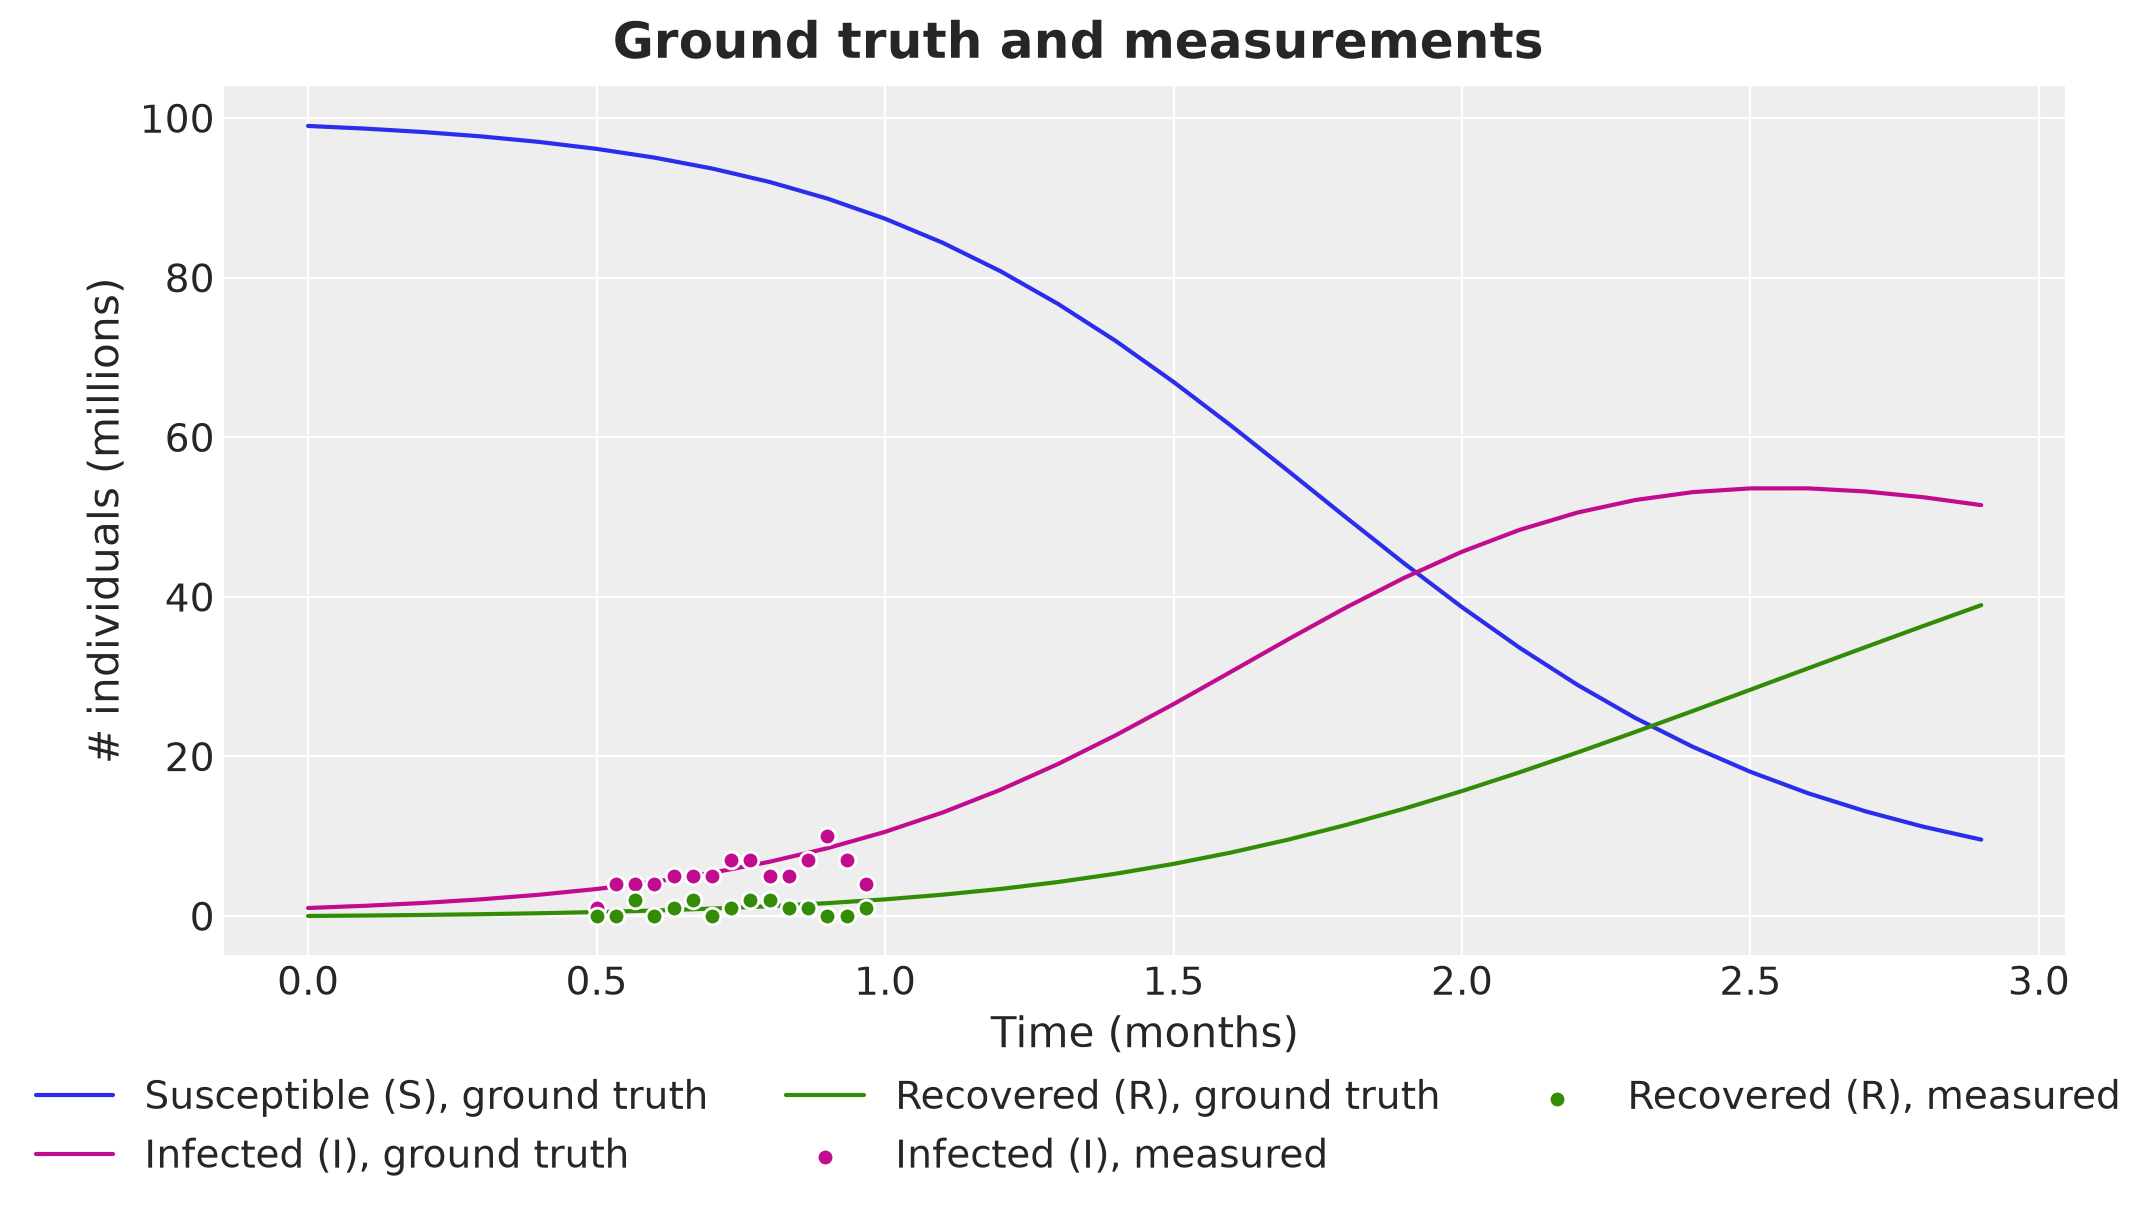

In [10]:
COMPARTMENTS = {"S": "Susceptible", "I": "Infected", "R": "Recovered"}
COLORS = {"S": "C0", "I": "C3", "R": "C2"}

fig, ax = plt.subplots(layout="constrained")
for name, long_name in COMPARTMENTS.items():
    ax.plot(
        logging_times,
        sir_true_traj[name],
        color=COLORS[name],
        label=f"{long_name} ({name}), ground truth",
    )
for name in ["I", "R"]:
    ax.scatter(
        obs_times,
        sir_data[f"{name}_obs"],
        color=COLORS[name],
        edgecolor="white",
        zorder=3,
        label=f"{COMPARTMENTS[name]} ({name}), measured",
    )
ax.set(xlabel="Time (months)", ylabel="# individuals (millions)")
fig.legend(loc="outside lower center", ncol=3)
fig.suptitle("Ground truth and measurements", fontsize=18, fontweight="bold");

The measurements cover the rise of the epidemic only. The peak of the infections comes after the measurement window.

## Causal Probabilistic Program

We turn the simulator into a probabilistic program by putting uniform priors on $\beta$ and $\gamma$, as in the original tutorial. The ODE solve is then a deterministic function of the sampled rates. The function `log_trajectory` records every compartment in the trace, which is what ChiRho's `LogTrajectory(is_traced=True)` does, so that `Predictive` returns the trajectories.

In [11]:
def bayesian_sir() -> Params:
    """Uniform priors on the infection and recovery rates."""
    beta = numpyro.sample("beta", dist.Uniform(0, 1))
    gamma = numpyro.sample("gamma", dist.Uniform(0, 1))
    return {"beta": beta, "gamma": gamma}


def log_trajectory(
    trajectory: dict[str, Float[Array, "*batch time"]],
) -> dict[str, Float[Array, "*batch time"]]:
    """Record every compartment in the trace, like `LogTrajectory(is_traced=True)`."""
    return {k: numpyro.deterministic(k, v) for k, v in trajectory.items()}


def simulated_bayesian_sir(
    init_state: State, start_time: Number, logging_times: Times
) -> Trajectory:
    """The SIR trajectory under the prior on the rates."""
    params = bayesian_sir()
    return log_trajectory(
        simulate(sir_dynamics, params, init_state, start_time, logging_times)
    )

`Predictive` traces and compiles the model again at every call. Wrapped in `jax.jit`, it compiles on the first call only, and later calls with other argument values, for instance other lockdown dates or strengths, reuse the compiled program. We draw $200$ samples, as in the original tutorial.

Four presentation choices differ from the original and change no result: the bands are $94\%$ intervals instead of $95\%$, we plot the SVI loss instead of printing it, we add a posterior predictive check of the measurements, and we show the prior of the town-level rates for one town only.

In [12]:
num_samples = 200

rng_key, rng_subkey = random.split(rng_key)
prior_predictive = jax.jit(Predictive(simulated_bayesian_sir, num_samples=num_samples))
sir_prior_samples = prior_predictive(rng_subkey, init_state, start_time, logging_times)

To look at the draws we use three small plotting helpers. `plot_trajectories` draws, for each compartment, the mean and the $94\%$ equal-tailed interval of the draws against time, together with the ground truth. `plot_measurements` adds the measured counts. `figure_legend` collects the labels of all panels into one legend below the figure, where it cannot hide the data. The entries shared by the panels appear once, in the color of the last panel.

In [13]:
def plot_trajectories(
    samples: Samples,
    truth: dict[str, Array] | None,
    times: Times,
    axes: np.ndarray,
    compartments: tuple[str, ...] = ("S", "I", "R"),
    estimate_label: str = "Posterior mean",
    units: str = "millions",
) -> None:
    """Mean and HDI band of the draws of each compartment, with the ground truth."""
    for ax, name in zip(axes, compartments, strict=True):
        draws = np.asarray(samples[name])
        lower, upper = az.eti(draws, prob=HDI_PROB, axis=0).T
        ax.fill_between(
            times,
            lower,
            upper,
            color=COLORS[name],
            alpha=0.3,
            label=f"{HDI_PROB:.0%} interval",
        )
        ax.plot(times, draws.mean(axis=0), color=COLORS[name], label=estimate_label)
        if truth is not None:
            ax.plot(
                times, truth[name], color="black", linestyle="--", label="Ground truth"
            )
        ax.set(
            title=COMPARTMENTS[name],
            xlabel="Time (months)",
            ylabel=f"# {COMPARTMENTS[name].lower()} ({units})",
        )


def plot_measurements(
    data: dict[str, Array], times: Times, axes: np.ndarray, label: str = "Measured"
) -> None:
    """Scatter of the measured infected and recovered on their two panels."""
    for ax, name in zip(axes, ["I", "R"], strict=True):
        ax.scatter(
            times, data[f"{name}_obs"], color="black", s=15, zorder=3, label=label
        )


def figure_legend(fig: plt.Figure, axes: np.ndarray, ncol: int = 4) -> None:
    """One legend below the panels, with each label once."""
    entries = {
        label: handle
        for ax in axes.flat
        for handle, label in zip(*ax.get_legend_handles_labels(), strict=True)
    }
    fig.legend(entries.values(), entries.keys(), loc="outside lower center", ncol=ncol)

Here is the prior predictive distribution of the trajectories.

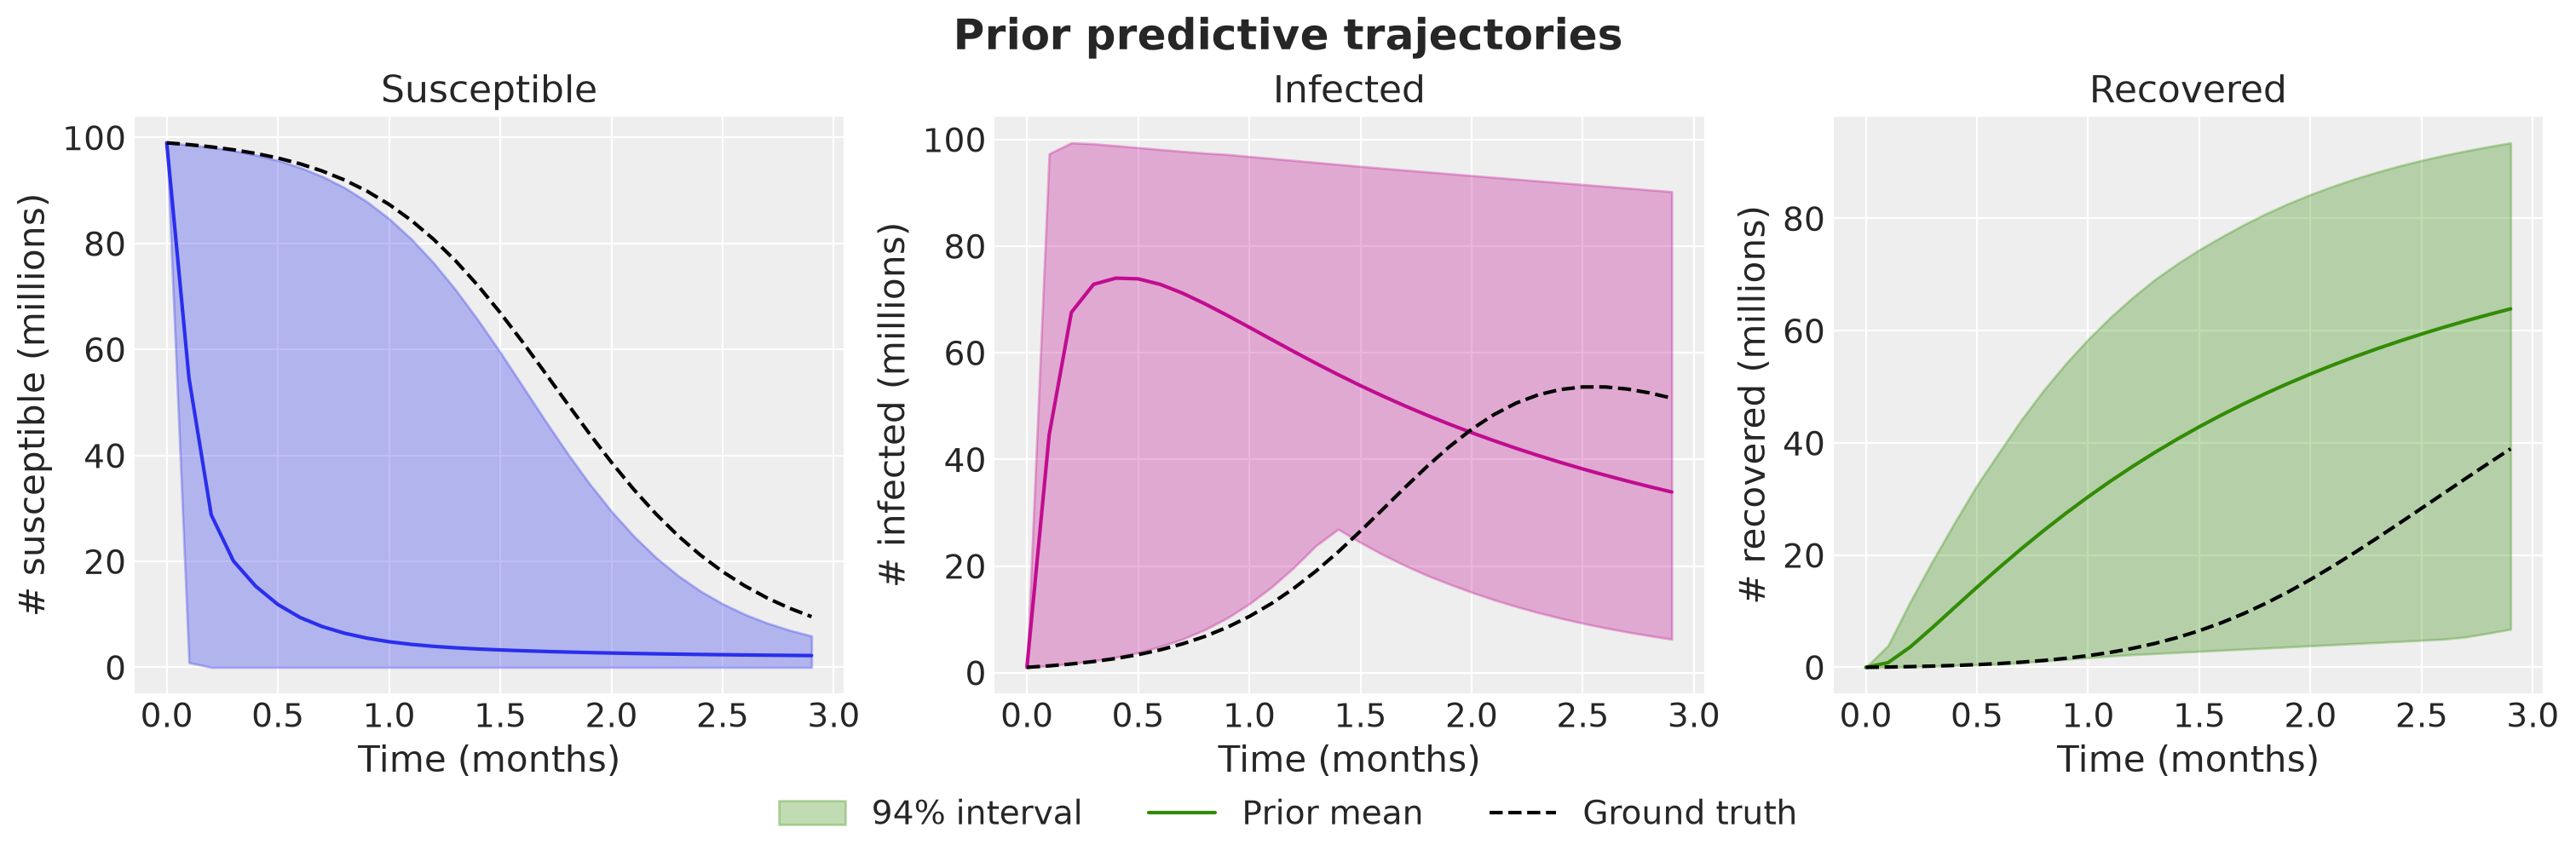

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(
    sir_prior_samples, sir_true_traj, logging_times, axes, estimate_label="Prior mean"
)
figure_legend(fig, axes)
fig.suptitle("Prior predictive trajectories", fontsize=18, fontweight="bold");

Without any data, the prior puts extremely broad uncertainty on the dynamics, which is what we want from a weak prior.

## Parameter Inference

To condition on the data we solve the ODE at the measurement times and score the measurements under the observation model. This is what ChiRho's `StaticBatchObservation` handler does. Here `observed_sir` is the generative model of the measurements, and `condition` attaches the data to it.

As in the original, we approximate the posterior with SVI and a multivariate normal guide, trained with Adam at learning rate $0.03$ for $1000$ steps. `init_to_median` matches Pyro's default initialization of the guide. `SVI.run` compiles the optimization loop, so there is nothing to add.

In [15]:
def observed_sir(obs_times: Times, init_state: State, start_time: Number) -> None:
    """The generative model of the measurements."""
    params = bayesian_sir()
    sir_observation_model(
        simulate(sir_dynamics, params, init_state, start_time, obs_times)
    )


def run_svi(
    model: Callable,
    rng_key: PRNGKeyArray,
    *model_args,
    num_steps: int,
    learning_rate: float = 0.03,
) -> tuple[AutoMultivariateNormal, SVIRunResult]:
    """Fit a multivariate normal guide with Adam, as in the ChiRho tutorials."""
    guide = AutoMultivariateNormal(model, init_loc_fn=init_to_median)
    svi = SVI(model, guide, numpyro.optim.Adam(learning_rate), Trace_ELBO())
    return guide, svi.run(rng_key, num_steps, *model_args, progress_bar=False)


num_steps = 1000

rng_key, rng_subkey = random.split(rng_key)
sir_guide, sir_svi_result = run_svi(
    condition(observed_sir, data=sir_data),
    rng_subkey,
    obs_times,
    init_state,
    start_time,
    num_steps=num_steps,
)

Let's check that the optimization converged.

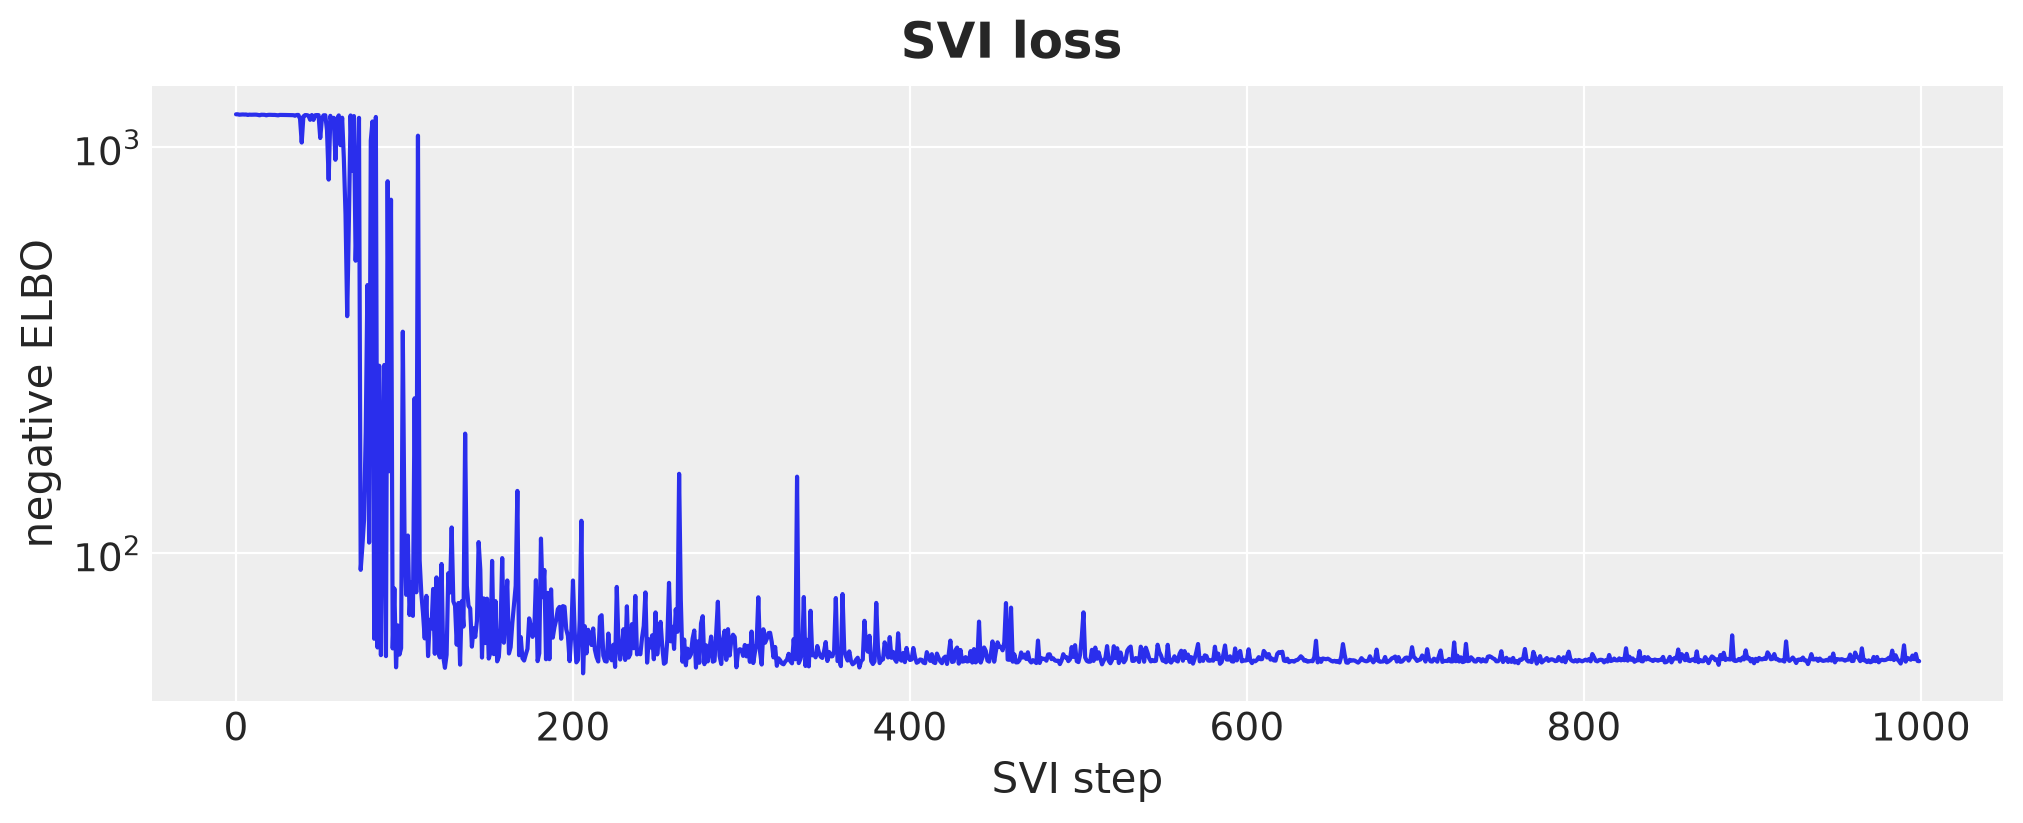

In [16]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(sir_svi_result.losses)
ax.set(xlabel="SVI step", ylabel="negative ELBO", yscale="log")
fig.suptitle("SVI loss", fontsize=18, fontweight="bold");

The loss settles after a few hundred steps, at about $54$, which is good!

Now we draw $200$ values of $(\beta, \gamma)$ from the guide. We reuse these draws for every predictive distribution below, so that all interventions are compared on the same posterior draws. The helper `to_datatree` packs draws into the ArviZ format for the parameter plots, and `label_density_axes` labels the axes of those plots.

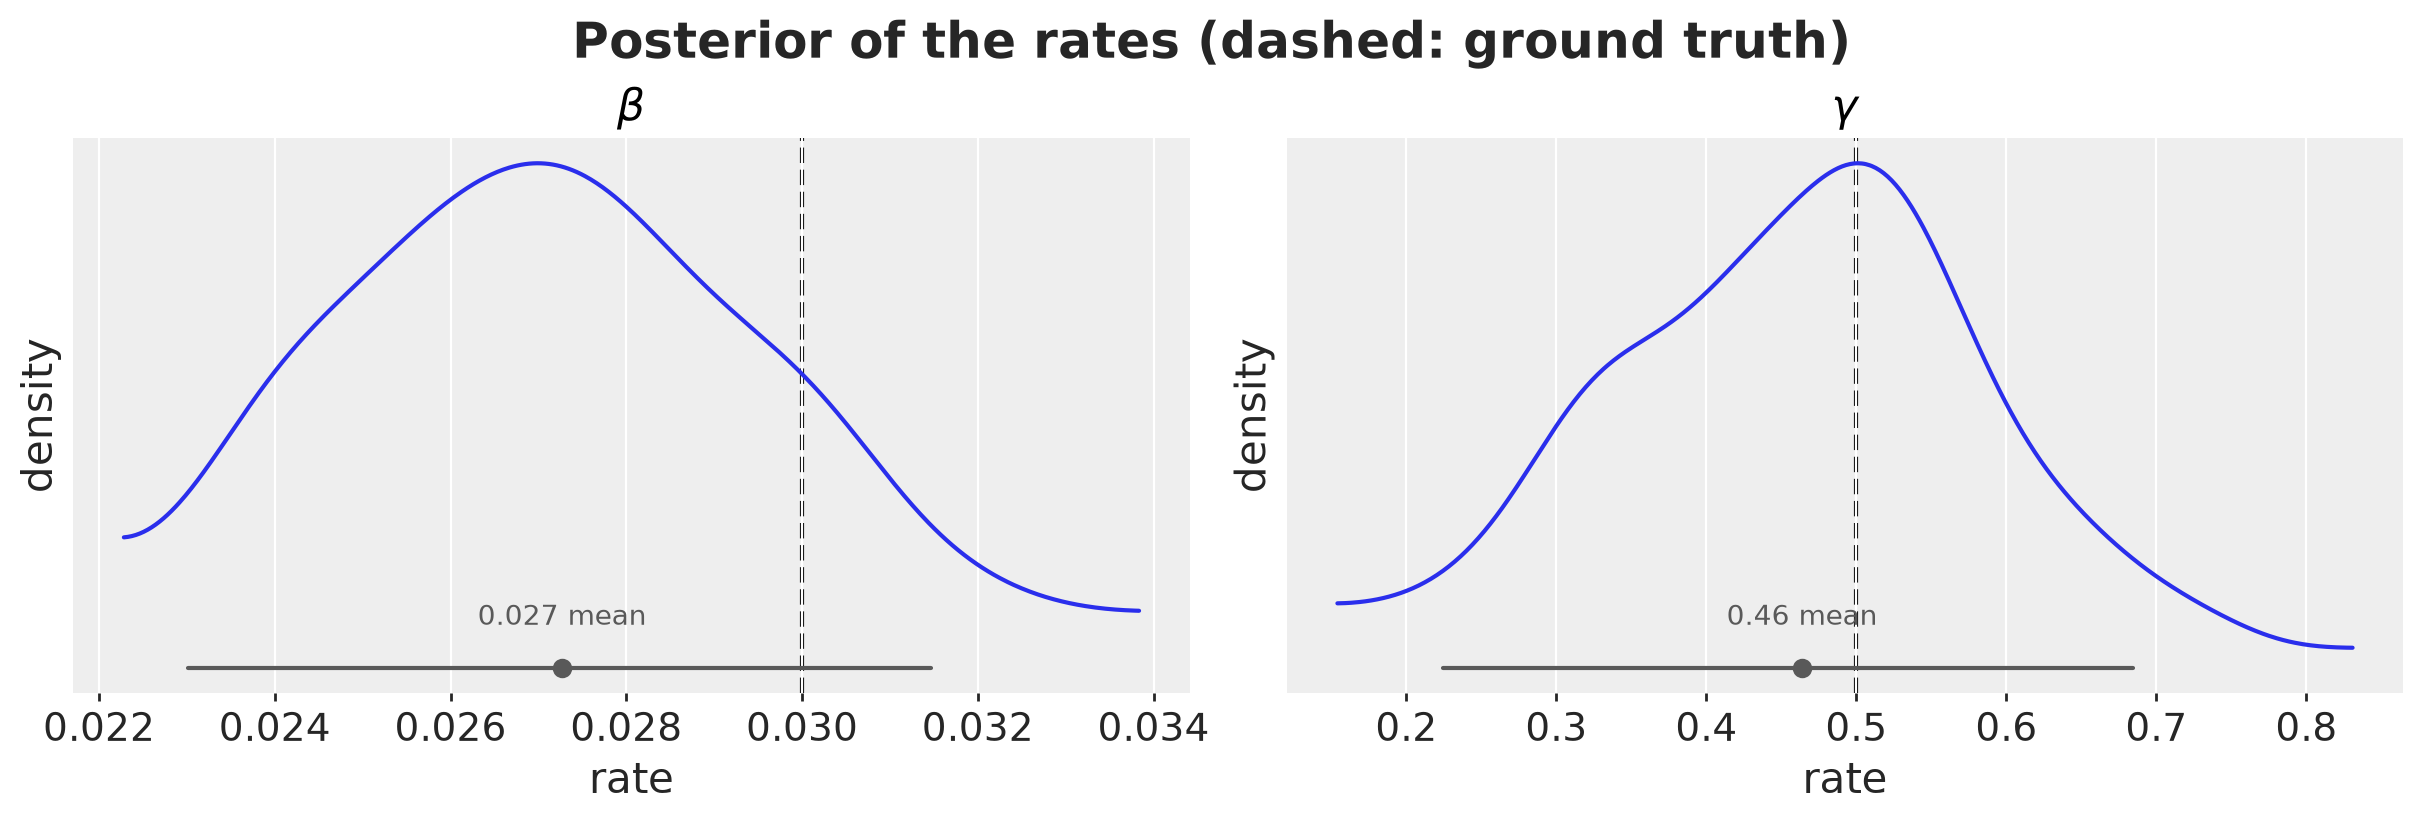

In [17]:
def to_datatree(
    dims: dict[str, list[str]] | None = None,
    coords: dict[str, list[str]] | None = None,
    **groups: Samples,
) -> xr.DataTree:
    """Draws with a leading draw axis as an ArviZ `DataTree` with one chain."""
    return az.from_dict(
        {g: {k: np.asarray(v)[None] for k, v in s.items()} for g, s in groups.items()},
        dims=dims,
        coords=coords,
    )


PARAMETER_LABELS = az.labels.MapLabeller(
    var_name_map={"beta": r"$\beta$", "gamma": r"$\gamma$"}
)

rng_key, rng_subkey = random.split(rng_key)
sir_posterior = sir_guide.sample_posterior(
    rng_subkey, sir_svi_result.params, sample_shape=(num_samples,)
)


def label_density_axes(pc: az.PlotCollection, xlabel: str = "rate") -> None:
    """Axis labels for every panel of an ArviZ density plot."""
    for ax in pc.viz["figure"].item().axes:
        ax.set(xlabel=xlabel, ylabel="density")


pc = az.plot_dist(
    to_datatree(posterior=sir_posterior),
    kind="kde",
    point_estimate="mean",
    labeller=PARAMETER_LABELS,
    figure_kwargs={"figsize": (12, 4)},
)
az.add_lines(
    pc, true_params, visuals={"ref_line": {"color": "black", "linestyle": "--"}}
)
label_density_axes(pc)
pc.viz["figure"].item().suptitle(
    "Posterior of the rates (dashed: ground truth)", fontsize=18, fontweight="bold"
);

Both posteriors cover the true rates. The posterior of $\beta$ is tight, with a $94\%$ HDI from $0.023$ to $0.031$, while the posterior of $\gamma$ is wide, from $0.22$ to $0.68$. This is not surprising: the measurements cover the early rise of the epidemic, where the growth rate $\beta S - \gamma$ is dominated by $\beta S$, so they say little about $\gamma$.

Next, we push the same draws through the observation model to get the posterior predictive distribution of the measurements, and compare it with the measurements themselves.

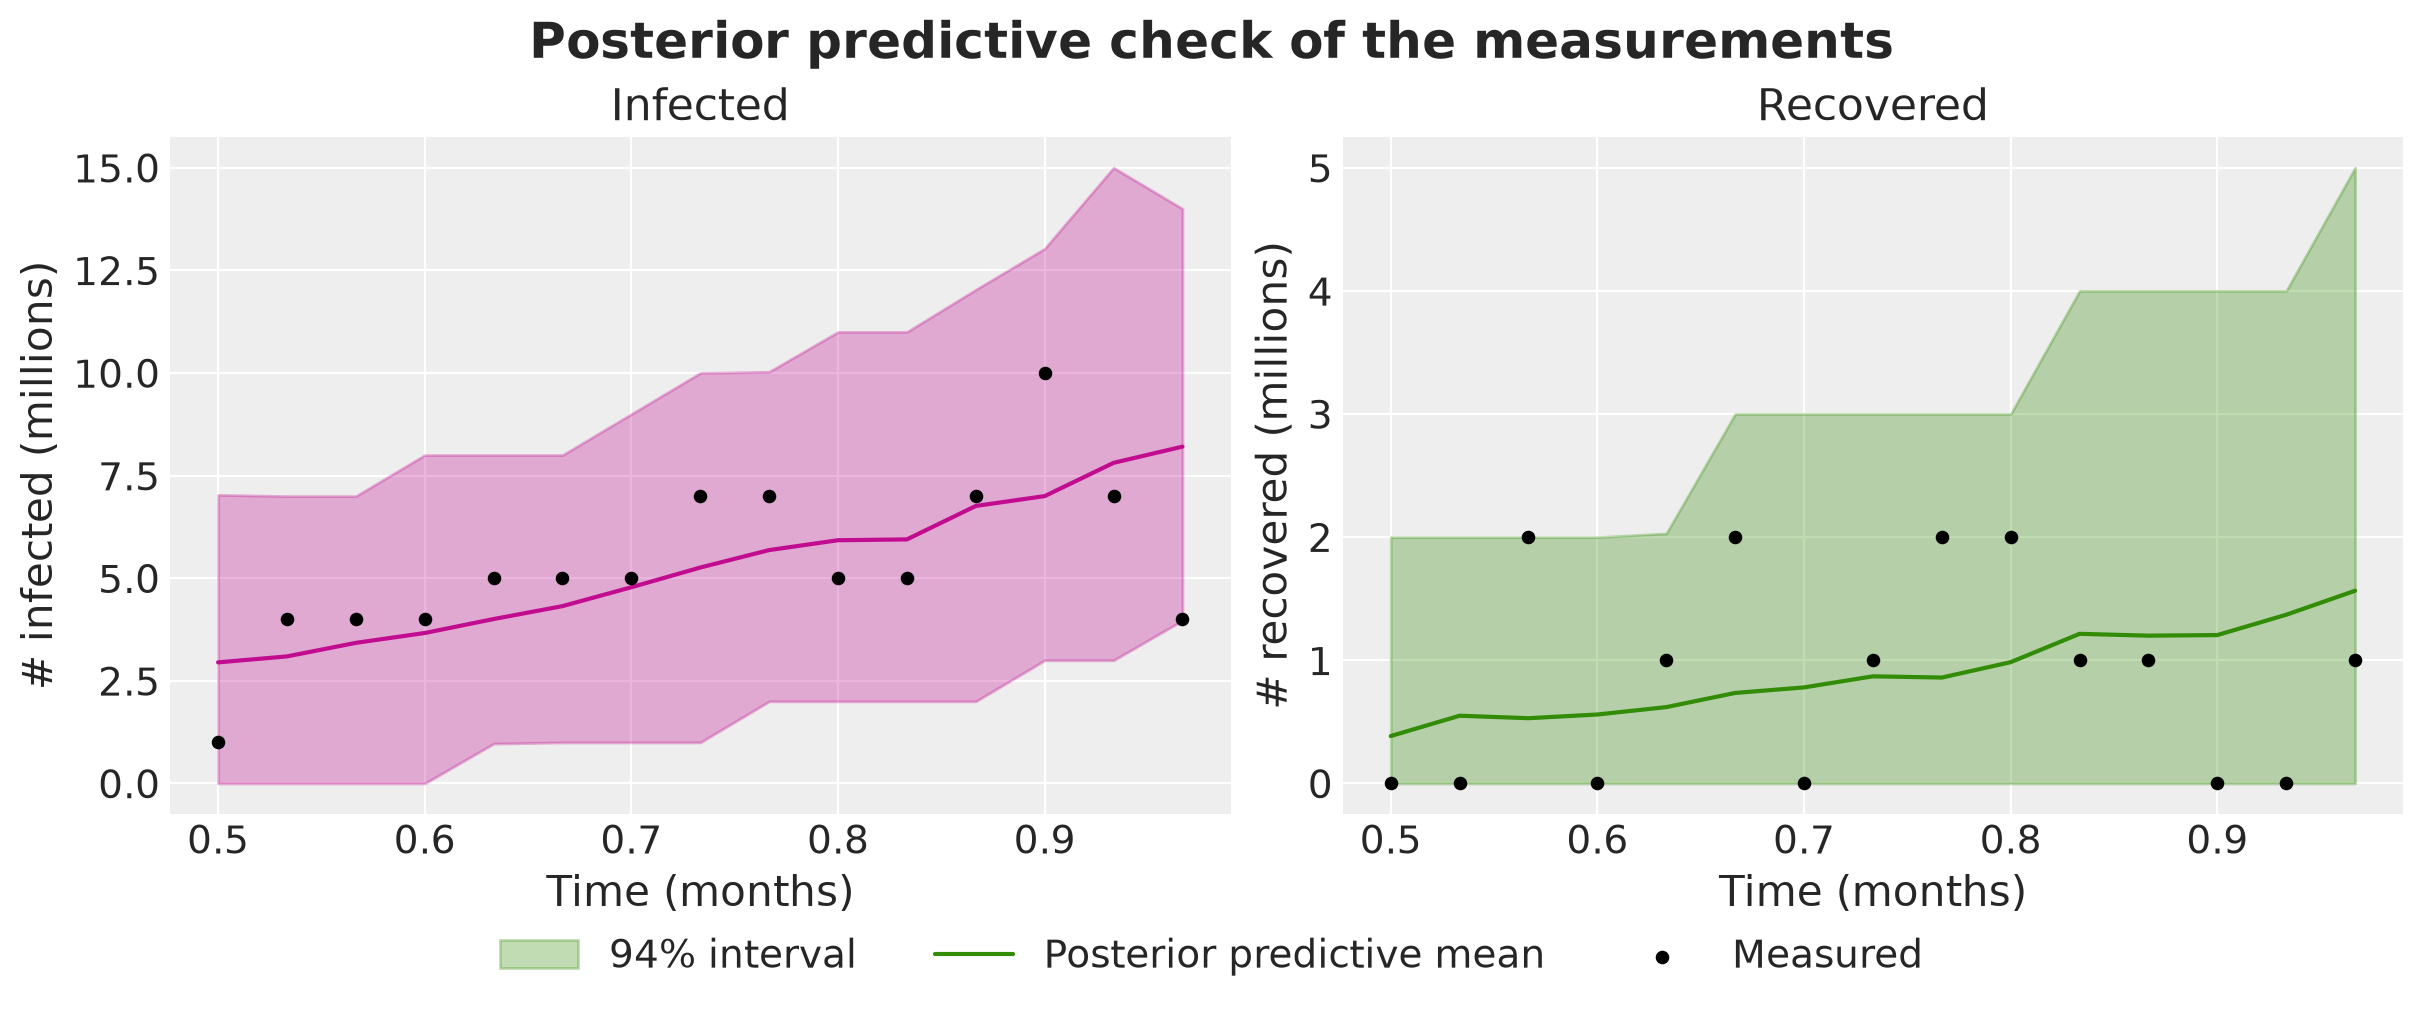

In [18]:
rng_key, rng_subkey = random.split(rng_key)
measurement_predictive = jax.jit(
    Predictive(observed_sir, posterior_samples=sir_posterior)
)
measurement_samples = measurement_predictive(
    rng_subkey, obs_times, init_state, start_time
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
plot_trajectories(
    {"I": measurement_samples["I_obs"], "R": measurement_samples["R_obs"]},
    None,
    obs_times,
    axes,
    compartments=("I", "R"),
    estimate_label="Posterior predictive mean",
)
plot_measurements(sir_data, obs_times, axes)
figure_legend(fig, axes)
fig.suptitle(
    "Posterior predictive check of the measurements", fontsize=18, fontweight="bold"
);

The measurements sit inside the posterior predictive band.

Finally, let's look at the posterior over the latent trajectories, including the forecast beyond the measurement period.

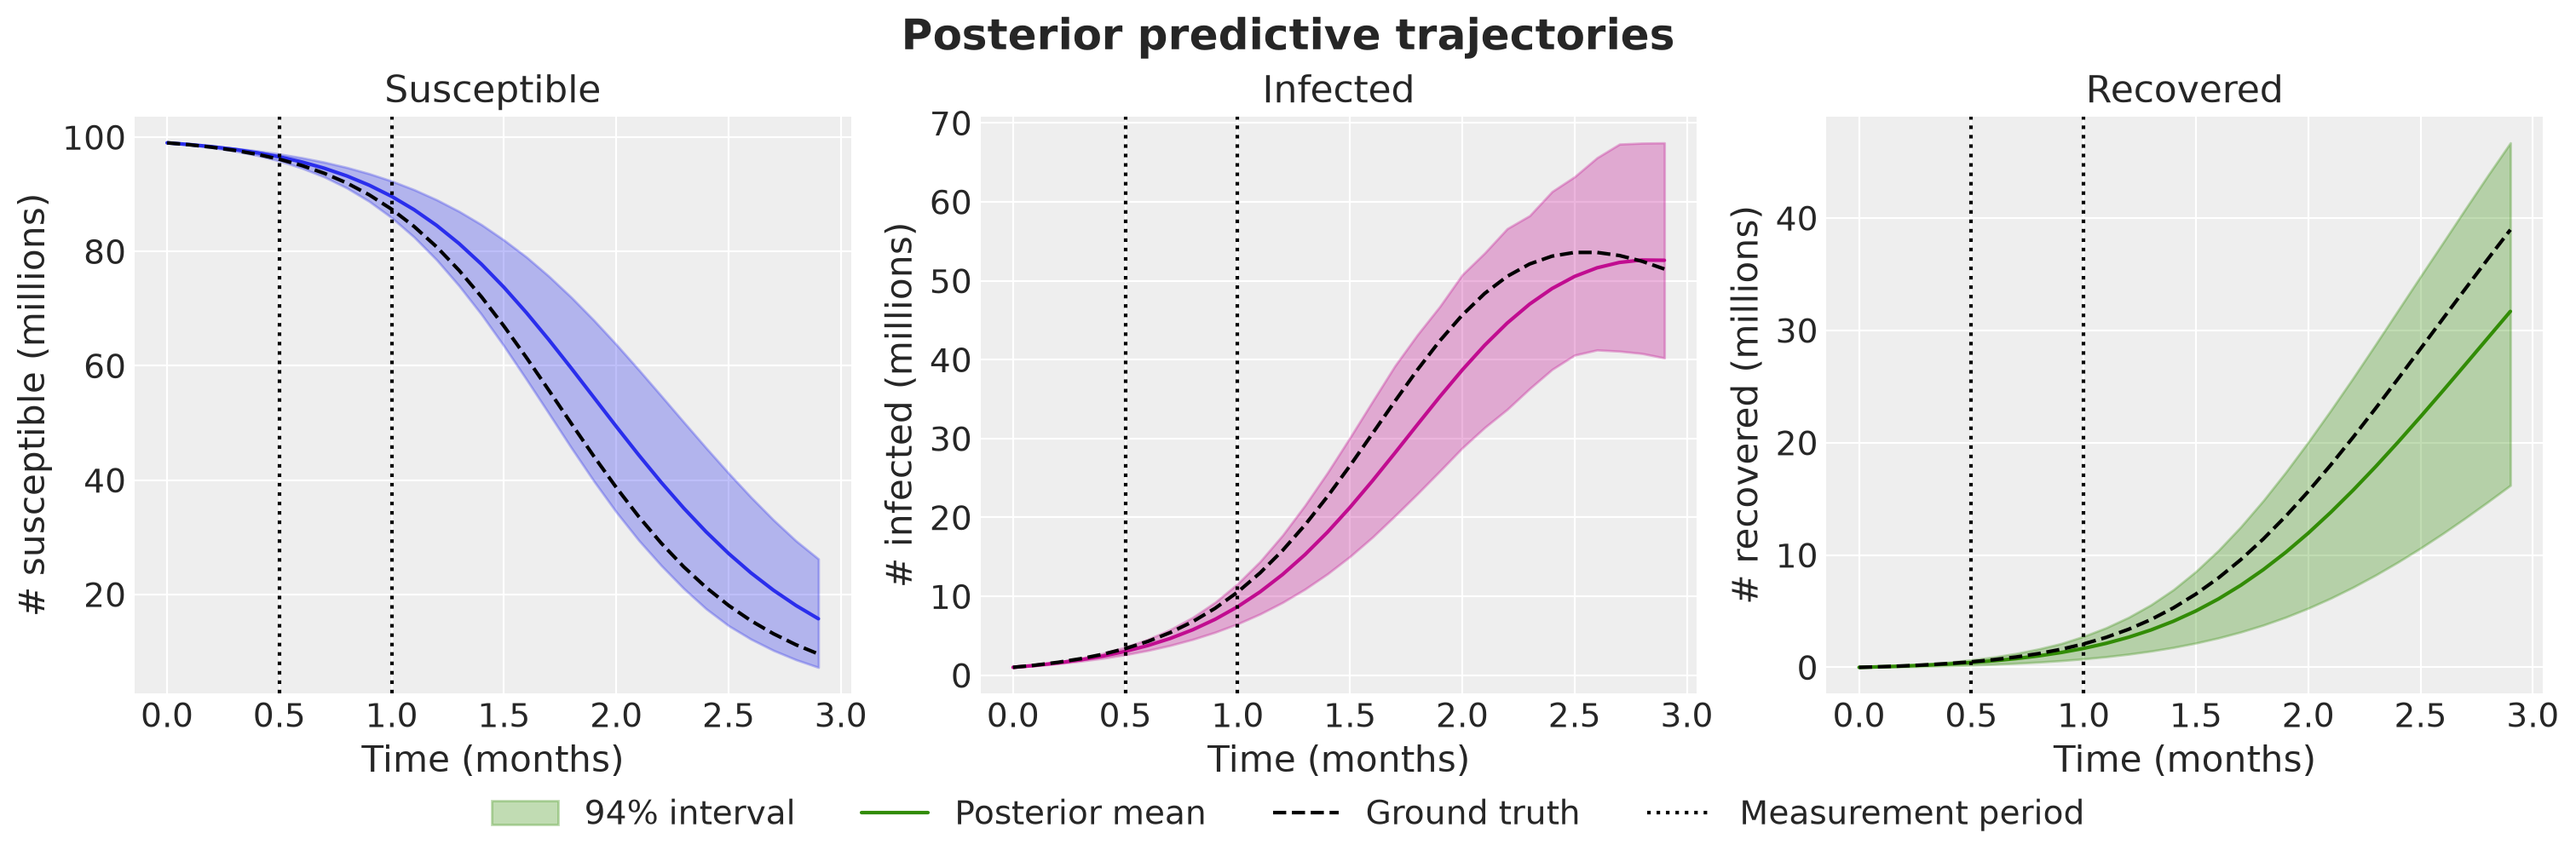

In [19]:
rng_key, rng_subkey = random.split(rng_key)
sir_predictive = jax.jit(
    Predictive(simulated_bayesian_sir, posterior_samples=sir_posterior)
)
sir_posterior_samples = sir_posterior | sir_predictive(
    rng_subkey, init_state, start_time, logging_times
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(sir_posterior_samples, sir_true_traj, logging_times, axes)
for ax in axes:
    ax.axvline(obs_start_time, color="black", linestyle=":", label="Measurement period")
    ax.axvline(obs_end_time, color="black", linestyle=":")
figure_legend(fig, axes)
fig.suptitle("Posterior predictive trajectories", fontsize=18, fontweight="bold");

The posterior predictive distribution covers the ground truth over the whole horizon, including the peak of the infections and the final number of recovered, which are outside the measurement window.

## Exploring Interventions

Suppose the government can enact lockdown measures of strength $l(t) \in [0, 1]$ that reduce the transmission rate,

$$\beta(t) = (1 - l(t)) \beta_0,$$

where $\beta_0$ is the unmitigated transmission rate. As in the original, we add $l$ to the state with zero dynamics, so it only changes when we intervene on it.

In [20]:
def sir_dynamics_lockdown(state: State, params: Params) -> State:
    """SIR dynamics with the infection rate scaled by `1 - l`, and `dl/dt = 0`."""
    beta = (1 - state["l"]) * params["beta"]
    derivative = sir_dynamics(state, params | {"beta": beta})
    return derivative | {"l": jnp.zeros_like(state["l"])}


init_state_lockdown = init_state | as_scalars({"l": 0.0})

### Deterministic Lockdown

First, we model a deterministic intervention: the transmission rate is reduced by $75\%$ between $t = 1$ and $t = 2$. This is two static interventions on $l$, one that sets it to the lockdown strength and one that sets it back to zero.

In [21]:
def intervened_sir(
    lockdown_start: Number,
    lockdown_end: Number,
    lockdown_strength: Number,
    init_state: State,
    start_time: Number,
    logging_times: Times,
) -> Trajectory:
    """The SIR trajectory under a lockdown with a fixed start, end and strength."""
    params = bayesian_sir()
    interventions = (
        static_intervention(lockdown_start, {"l": lockdown_strength}),
        static_intervention(lockdown_end, {"l": 0.0}),
    )
    return log_trajectory(
        simulate(
            sir_dynamics_lockdown,
            params,
            init_state,
            start_time,
            logging_times,
            interventions,
        )
    )

The ground truth under the lockdown fixes the rates to their true values with `condition`, as `pyro.condition` does in the original. The predictive distribution uses the posterior draws of the rates.

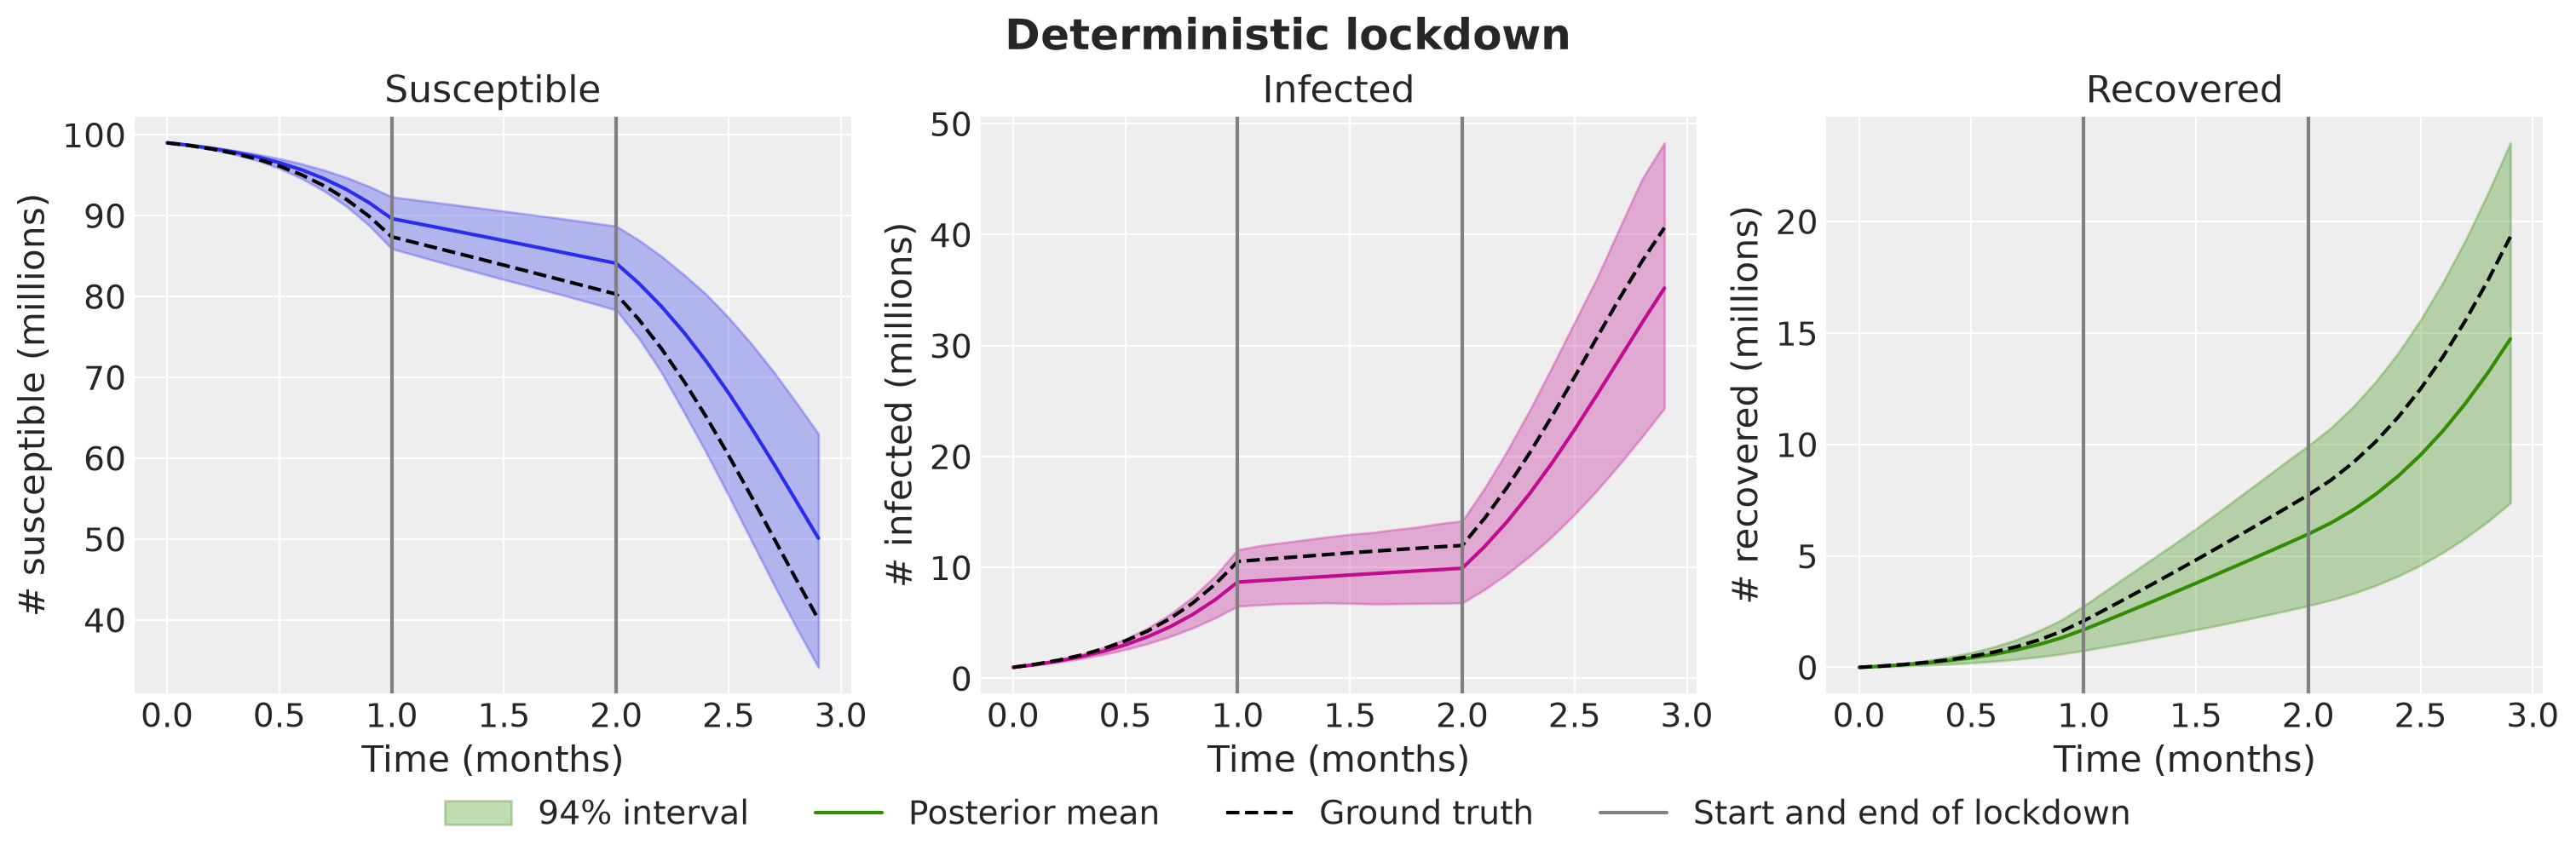

In [22]:
lockdown_start = 1.0
lockdown_end = 2.0
lockdown_strength = 0.75

true_intervened_sir = condition(intervened_sir, data=true_params)
true_intervened_traj = true_intervened_sir(
    lockdown_start,
    lockdown_end,
    lockdown_strength,
    init_state_lockdown,
    start_time,
    logging_times,
)

rng_key, rng_subkey = random.split(rng_key)
intervened_predictive = jax.jit(
    Predictive(intervened_sir, posterior_samples=sir_posterior)
)
intervened_samples = intervened_predictive(
    rng_subkey,
    lockdown_start,
    lockdown_end,
    lockdown_strength,
    init_state_lockdown,
    start_time,
    logging_times,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(intervened_samples, true_intervened_traj, logging_times, axes)
for ax in axes:
    ax.axvline(lockdown_start, color="gray", label="Start and end of lockdown")
    ax.axvline(lockdown_end, color="gray")
figure_legend(fig, axes)
fig.suptitle("Deterministic lockdown", fontsize=18, fontweight="bold");

The lockdown indeed flattens the curve: the number of infected stays almost flat between $t = 1$ and $t = 2$, and grows again once the lockdown is lifted.

### Uncertain Lockdown

When the lockdown starts and ends may be outside the policymaker's control. To represent that uncertainty we draw the two dates from uniform distributions and call the same program. Nothing else changes: the event times are now random inputs of the solver.

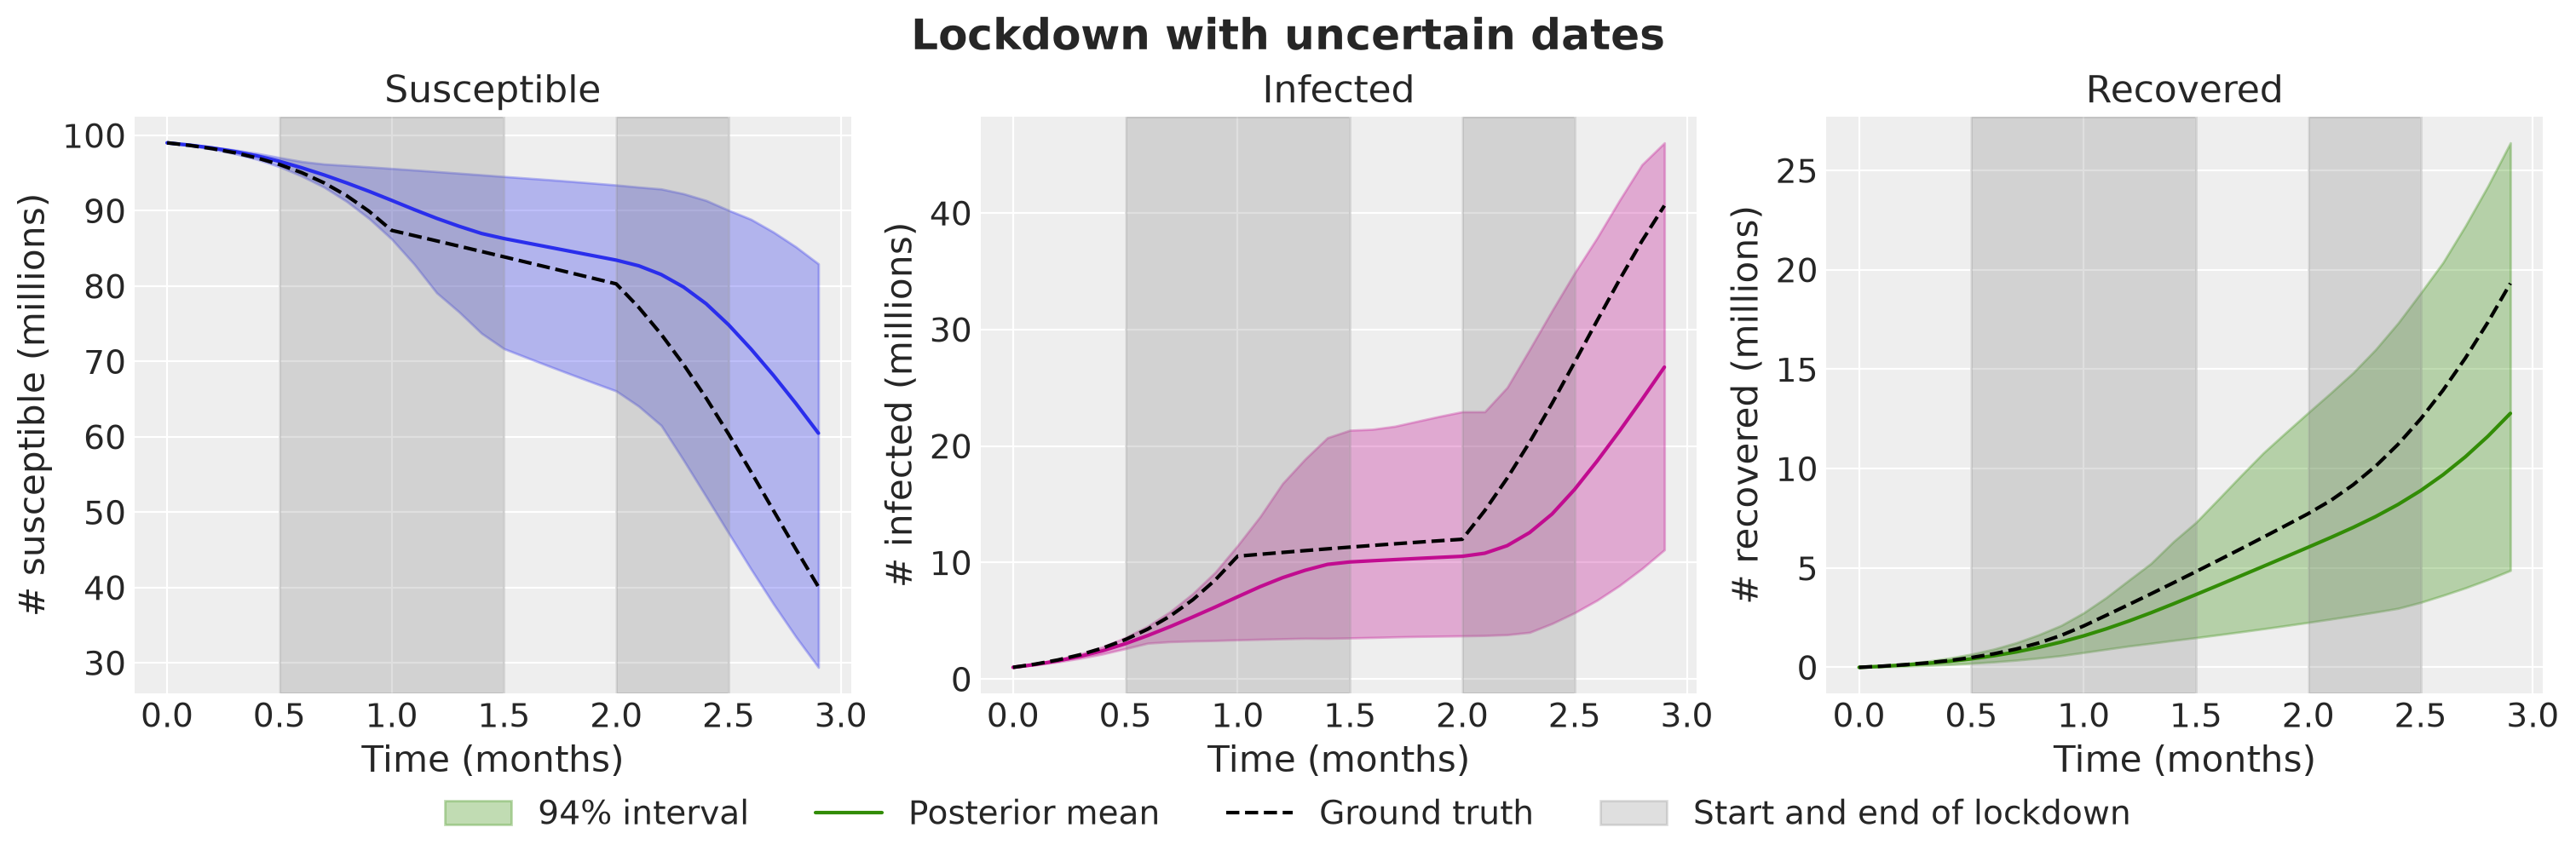

In [23]:
def uncertain_intervened_sir(
    lockdown_strength: Number,
    init_state: State,
    start_time: Number,
    logging_times: Times,
) -> Trajectory:
    """`intervened_sir` with the start and end of the lockdown drawn from uniforms."""
    lockdown_start = numpyro.sample("lockdown_start", dist.Uniform(0.5, 1.5))
    lockdown_end = numpyro.sample("lockdown_end", dist.Uniform(2.0, 2.5))
    return intervened_sir(
        lockdown_start,
        lockdown_end,
        lockdown_strength,
        init_state,
        start_time,
        logging_times,
    )


rng_key, rng_subkey = random.split(rng_key)
uncertain_intervened_predictive = jax.jit(
    Predictive(uncertain_intervened_sir, posterior_samples=sir_posterior)
)
uncertain_intervened_samples = uncertain_intervened_predictive(
    rng_subkey, lockdown_strength, init_state_lockdown, start_time, logging_times
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(
    uncertain_intervened_samples, true_intervened_traj, logging_times, axes
)
for ax in axes:
    ax.axvspan(0.5, 1.5, color="gray", alpha=0.25, label="Start and end of lockdown")
    ax.axvspan(2.0, 2.5, color="gray", alpha=0.25)
figure_legend(fig, axes)
fig.suptitle("Lockdown with uncertain dates", fontsize=18, fontweight="bold");

The uncertainty about the dates widens the bands around the start and the end of the lockdown, where the trajectories now disagree on when the curve bends.

### State-Dependent Lockdown

More realistic policies respond to the state of the epidemic. Here the government issues a lockdown that reduces transmission by $90\%$ as soon as $30$ million people are infected, and lifts it once $20$ million have recovered. We do not know in advance when either happens: the solver finds the intervention times as zero crossings of the two event functions.

In [24]:
def government_lockdown_policy(t: Scalar, state: State, target: Scalar) -> Scalar:
    """Positive once the number of infected exceeds `target`."""
    return state["I"] - target


def government_lift_policy(t: Scalar, state: State, target: Scalar) -> Scalar:
    """Negative once the number of recovered exceeds `target`."""
    return target - state["R"]


def dynamic_intervened_sir(
    lockdown_trigger: Number,
    lockdown_lift_trigger: Number,
    lockdown_strength: Number,
    init_state: State,
    start_time: Number,
    logging_times: Times,
) -> Trajectory:
    """A lockdown from `I = lockdown_trigger` until `R = lockdown_lift_trigger`."""
    params = bayesian_sir()
    interventions = (
        Intervention(
            government_lockdown_policy, lockdown_trigger, {"l": lockdown_strength}
        ),
        Intervention(government_lift_policy, lockdown_lift_trigger, {"l": 0.0}),
    )
    return log_trajectory(
        simulate(
            sir_dynamics_lockdown,
            params,
            init_state,
            start_time,
            logging_times,
            interventions,
        )
    )

As before, the ground truth fixes the rates with `condition`, and the predictive distribution uses the posterior draws.

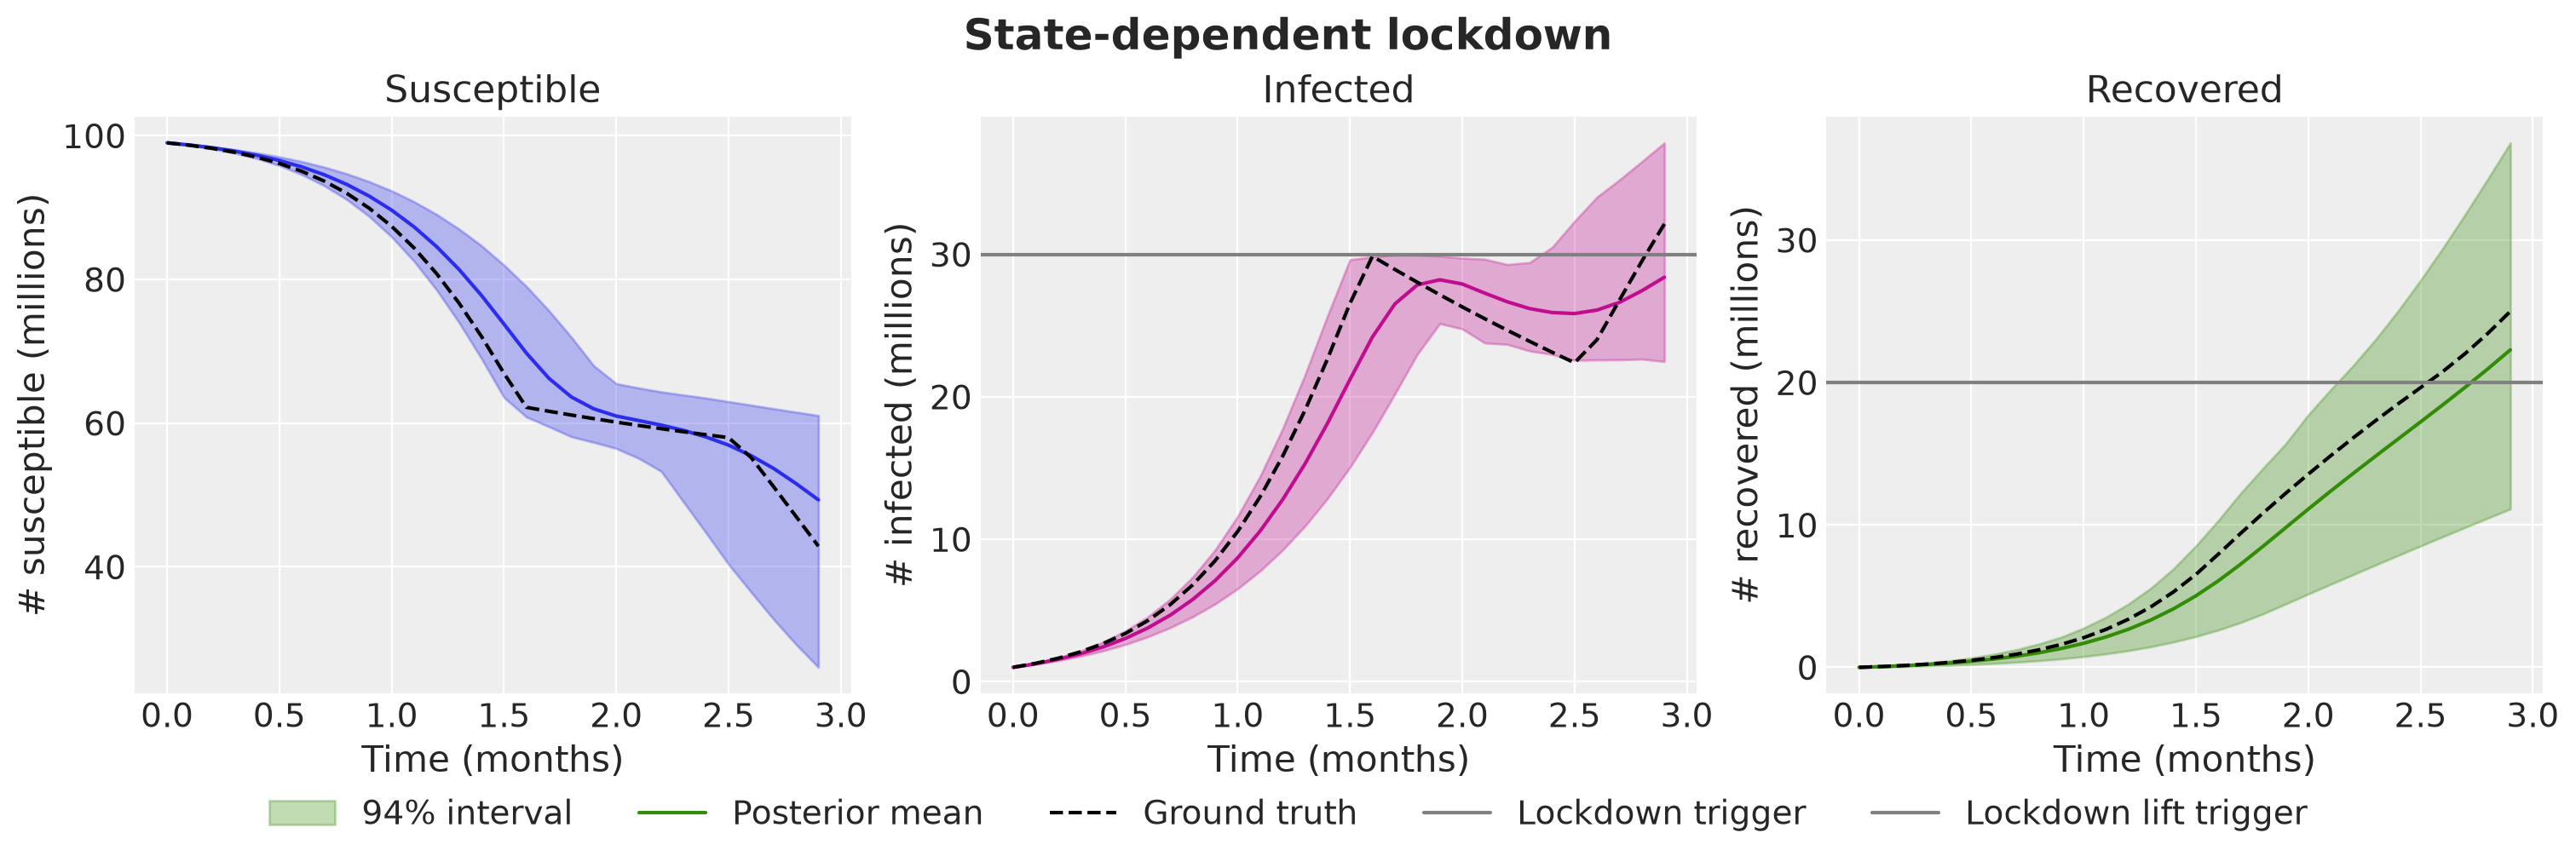

In [25]:
lockdown_trigger = 30.0
lockdown_lift_trigger = 20.0
dynamic_lockdown_strength = 0.9

true_dynamic_intervened_sir = condition(dynamic_intervened_sir, data=true_params)
true_dynamic_intervened_traj = true_dynamic_intervened_sir(
    lockdown_trigger,
    lockdown_lift_trigger,
    dynamic_lockdown_strength,
    init_state_lockdown,
    start_time,
    logging_times,
)

rng_key, rng_subkey = random.split(rng_key)
dynamic_intervened_predictive = jax.jit(
    Predictive(dynamic_intervened_sir, posterior_samples=sir_posterior)
)
dynamic_intervened_samples = dynamic_intervened_predictive(
    rng_subkey,
    lockdown_trigger,
    lockdown_lift_trigger,
    dynamic_lockdown_strength,
    init_state_lockdown,
    start_time,
    logging_times,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(
    dynamic_intervened_samples, true_dynamic_intervened_traj, logging_times, axes
)
axes[1].axhline(lockdown_trigger, color="gray", label="Lockdown trigger")
axes[2].axhline(lockdown_lift_trigger, color="gray", label="Lockdown lift trigger")
figure_legend(fig, axes, ncol=5)
fig.suptitle("State-dependent lockdown", fontsize=18, fontweight="bold");

Once the number of infected reaches $30$ million, at about $t = 1.6$, the lockdown turns the growth around and the number of infected drifts down. The epidemic resumes once $20$ million have recovered, at about $t = 2.5$. Both intervention times are found by the solver.

### Uncertain Triggers

Finally, the trigger conditions themselves can be uncertain. Again we only need to draw them from distributions and call the same program.

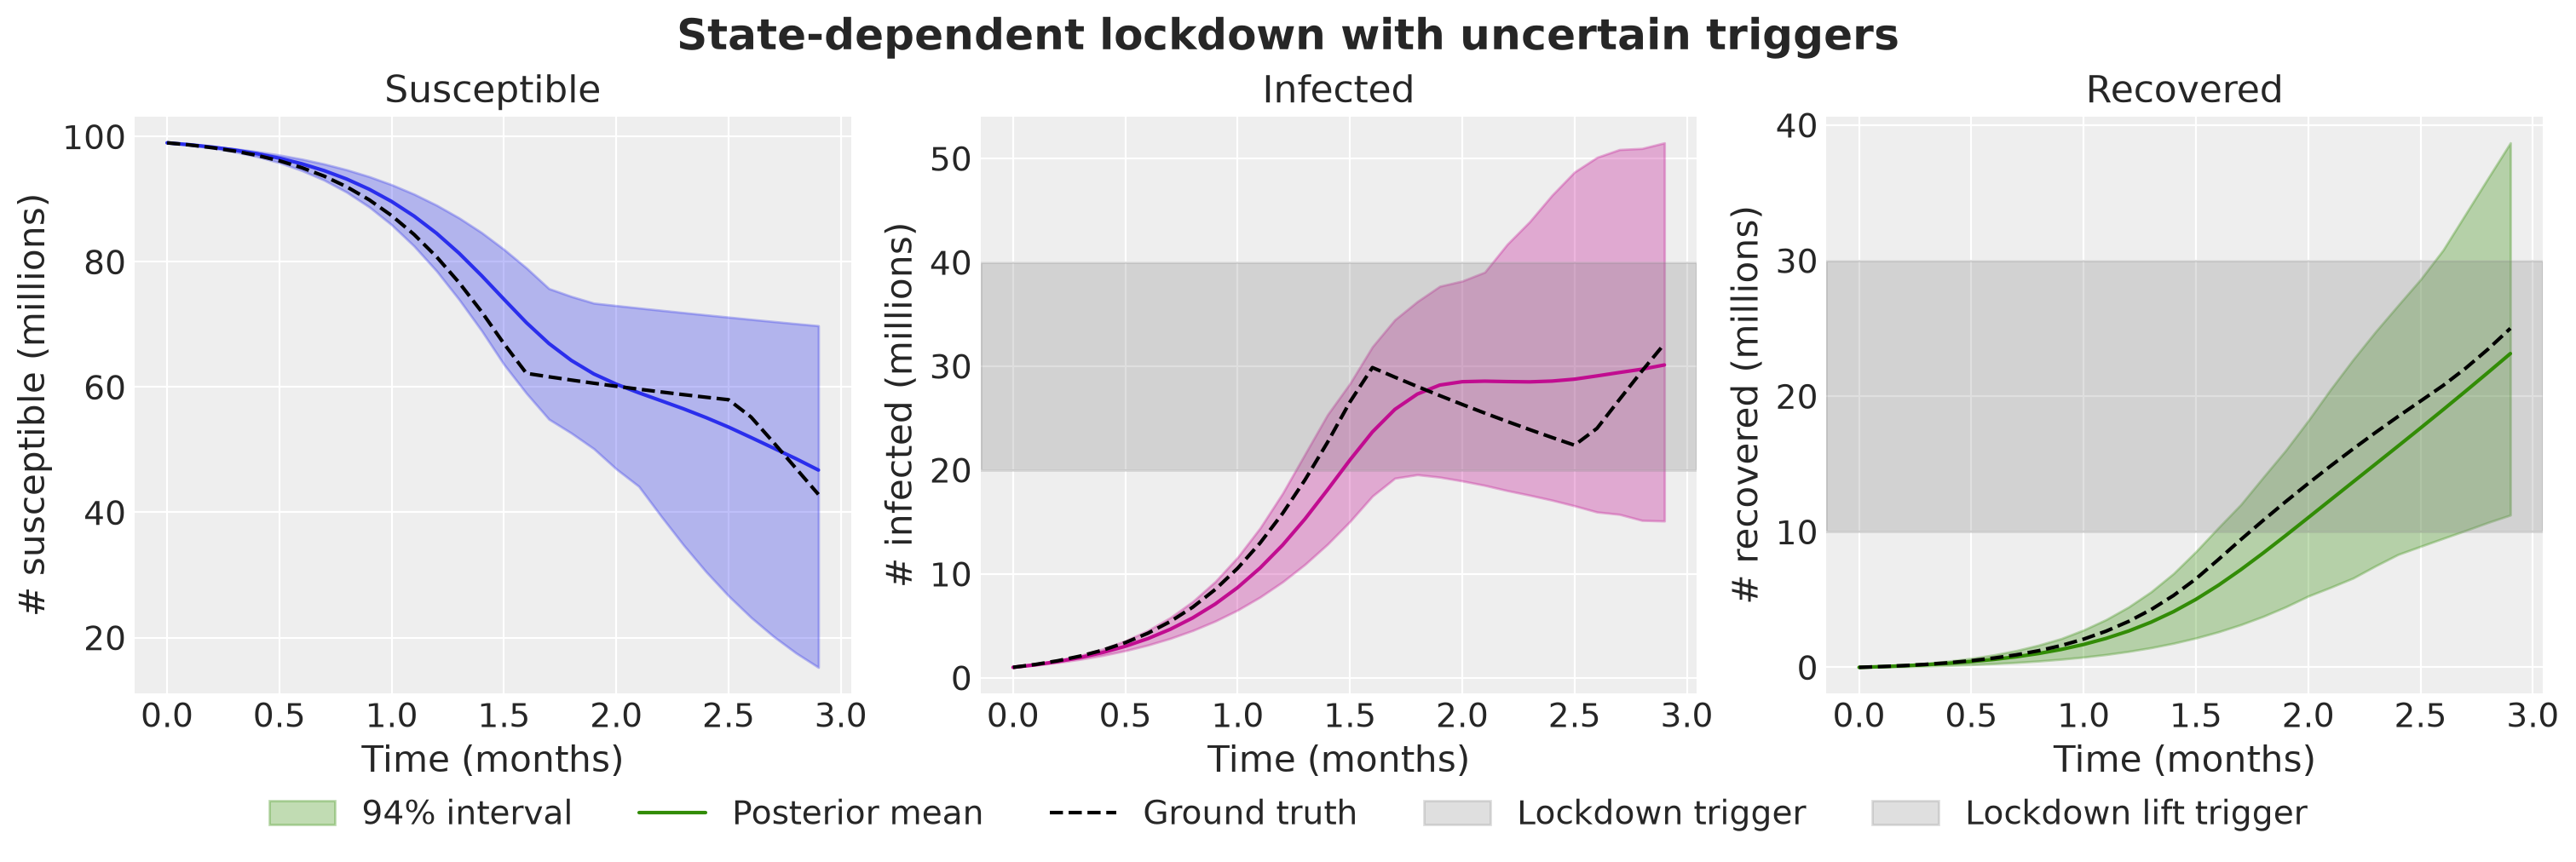

In [26]:
def uncertain_dynamic_intervened_sir(
    lockdown_strength: Number,
    init_state: State,
    start_time: Number,
    logging_times: Times,
) -> Trajectory:
    """`dynamic_intervened_sir` with the two triggers drawn from uniforms."""
    lockdown_trigger = numpyro.sample("lockdown_trigger", dist.Uniform(20.0, 40.0))
    lockdown_lift_trigger = numpyro.sample(
        "lockdown_lift_trigger", dist.Uniform(10.0, 30.0)
    )
    return dynamic_intervened_sir(
        lockdown_trigger,
        lockdown_lift_trigger,
        lockdown_strength,
        init_state,
        start_time,
        logging_times,
    )


rng_key, rng_subkey = random.split(rng_key)
uncertain_dynamic_intervened_predictive = jax.jit(
    Predictive(uncertain_dynamic_intervened_sir, posterior_samples=sir_posterior)
)
uncertain_dynamic_intervened_samples = uncertain_dynamic_intervened_predictive(
    rng_subkey,
    dynamic_lockdown_strength,
    init_state_lockdown,
    start_time,
    logging_times,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
plot_trajectories(
    uncertain_dynamic_intervened_samples,
    true_dynamic_intervened_traj,
    logging_times,
    axes,
)
axes[1].axhspan(20.0, 40.0, color="gray", alpha=0.25, label="Lockdown trigger")
axes[2].axhspan(10.0, 30.0, color="gray", alpha=0.25, label="Lockdown lift trigger")
figure_legend(fig, axes, ncol=5)
fig.suptitle(
    "State-dependent lockdown with uncertain triggers", fontsize=18, fontweight="bold"
);

The uncertainty about the triggers shows up as a wider band on the plateau of the infected and on the time at which the epidemic resumes.

## Comparing Interventions

This section is not in the original tutorial. We summarize each simulated epidemic by two numbers: the peak number of infected, and the number of people infected at some point before the end of the forecast, which is $I + R$ at the last logging time. A forest plot then puts the five scenarios side by side.

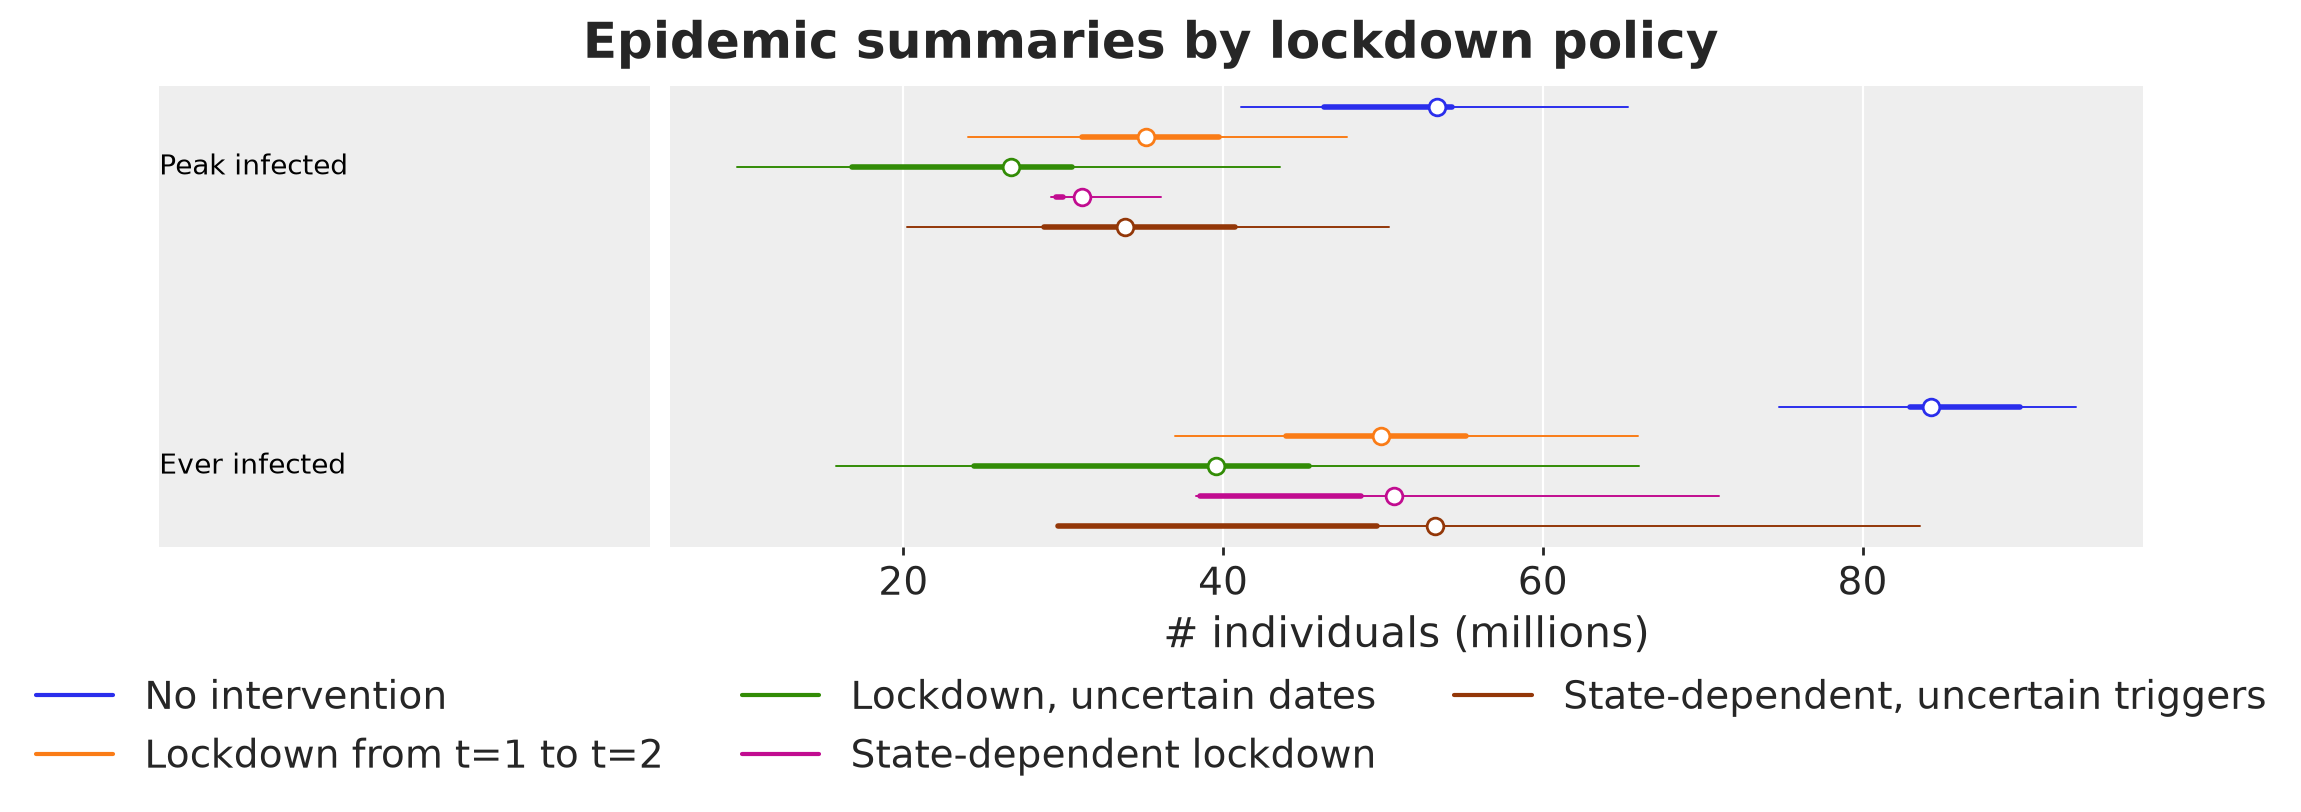

In [27]:
def epidemic_summaries(samples: Samples) -> Samples:
    """Peak number of infected, and number ever infected by the last logging time."""
    return {
        "peak_infected": samples["I"].max(axis=-1),
        "ever_infected": samples["I"][..., -1] + samples["R"][..., -1],
    }


SUMMARY_LABELS = az.labels.MapLabeller(
    var_name_map={"peak_infected": "Peak infected", "ever_infected": "Ever infected"}
)


def plot_summaries(
    scenarios: dict[str, Samples],
    title: str,
    units: str = "millions",
    figsize: tuple[int, int] = (10, 4),
    **kwargs,
) -> None:
    """Forest plot of the two epidemic summaries, one color per scenario."""
    pc = az.plot_forest(
        {
            name: to_datatree(posterior=epidemic_summaries(samples), **kwargs)
            for name, samples in scenarios.items()
        },
        combined=True,
        labeller=SUMMARY_LABELS,
        figure_kwargs={"figsize": figsize, "layout": "constrained"},
    )
    pc.add_legend("model", title="", loc="outside lower center", ncol=3)
    pc.viz["plot"].sel(column="labels").item().set_xticks([])
    pc.viz["plot"].sel(column="forest").item().set_xlabel(f"# individuals ({units})")
    pc.viz["figure"].item().suptitle(title, fontsize=18, fontweight="bold")


scenarios = {
    "No intervention": sir_posterior_samples,
    "Lockdown from t=1 to t=2": intervened_samples,
    "Lockdown, uncertain dates": uncertain_intervened_samples,
    "State-dependent lockdown": dynamic_intervened_samples,
    "State-dependent, uncertain triggers": uncertain_dynamic_intervened_samples,
}
plot_summaries(scenarios, title="Epidemic summaries by lockdown policy");

Every lockdown lowers both summaries by the end of the forecast. The state-dependent lockdown has by far the narrowest interval for the peak, because the policy holds the number of infected near its trigger whatever the rates are. The lockdowns at fixed or uncertain dates delay the epidemic rather than cap it: once they are lifted, the infections grow again, and at the end of the forecast they are still growing.

The compiled predictive distribution makes further questions cheap. Sweeping the strength of the lockdown between $t = 1$ and $t = 2$ calls the same program with another argument value, so each additional strength only costs the ODE solves.

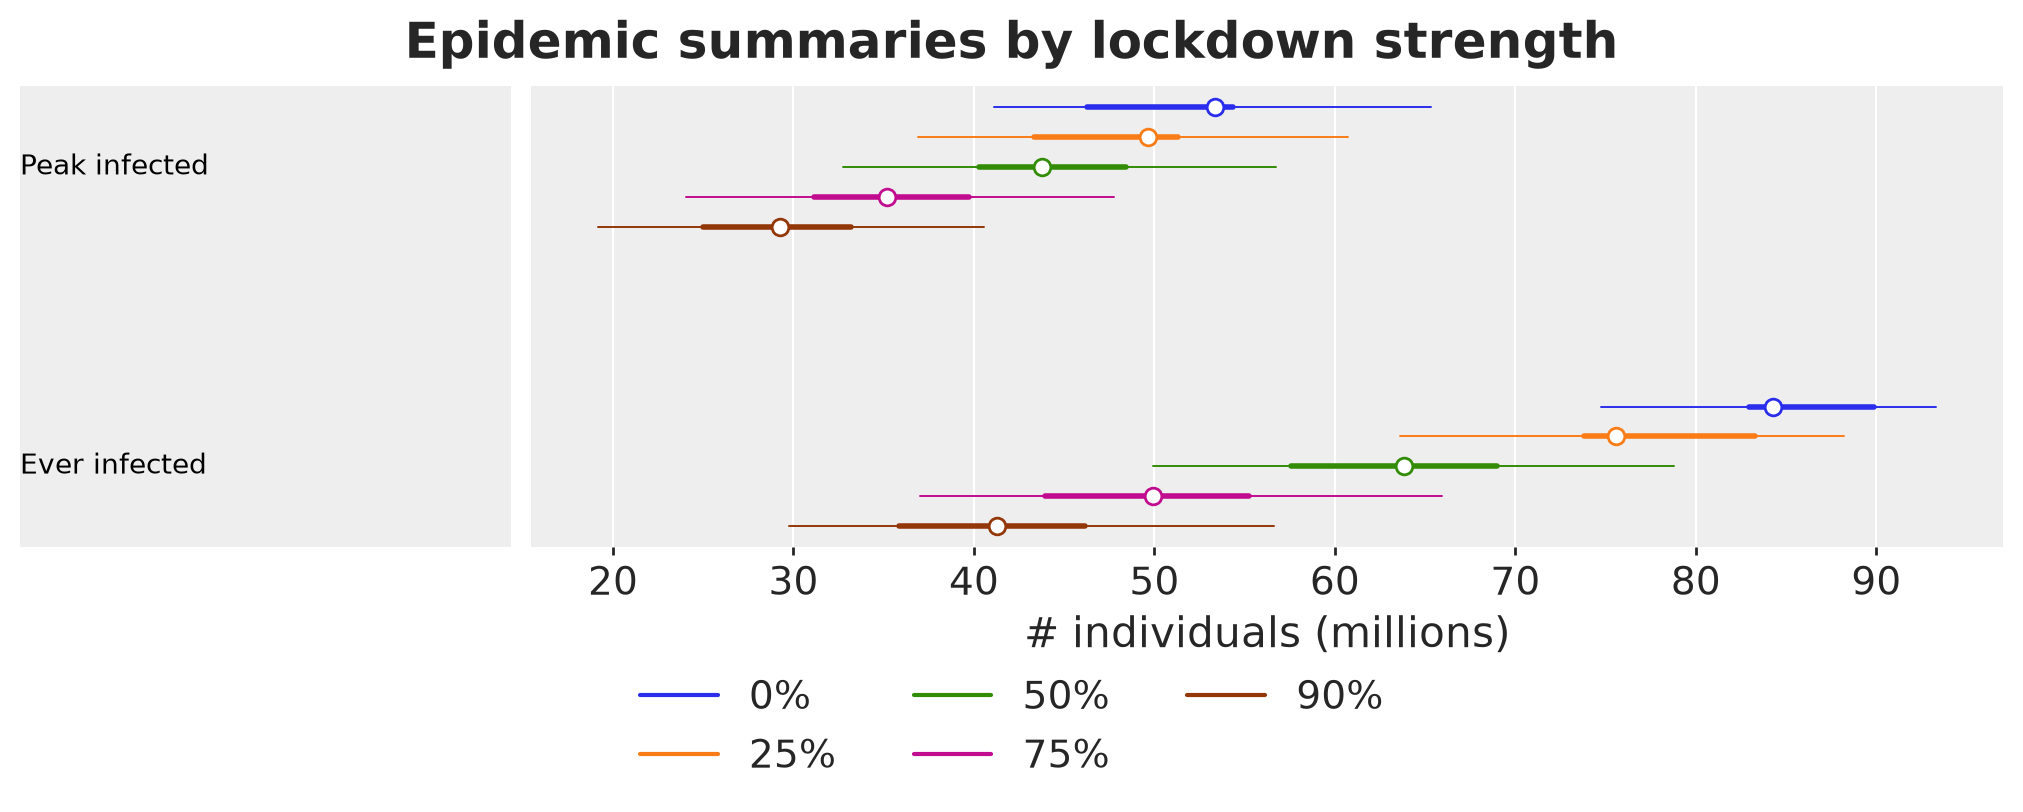

In [28]:
rng_key, rng_subkey = random.split(rng_key)
strength_sweep = {
    f"{strength:.0%}": intervened_predictive(
        rng_subkey,
        lockdown_start,
        lockdown_end,
        strength,
        init_state_lockdown,
        start_time,
        logging_times,
    )
    for strength in [0.0, 0.25, 0.5, 0.75, 0.9]
}
plot_summaries(strength_sweep, title="Epidemic summaries by lockdown strength");

The stronger the lockdown, the lower both summaries. A $90\%$ lockdown roughly halves the peak and the number ever infected by the end of the forecast, from $53$ to $29$ million and from $84$ to $41$ million.

## Three Towns

Now we move to the second tutorial. Multilevel regression pools information across groups by drawing the coefficients of each group from a shared distribution whose parameters are themselves uncertain (see chapter $5$ of Gelman et al., *Bayesian Data Analysis*). The same construction works when the regression equation is replaced by a differential equation. Each town $k$ has its own rates $\beta_k$ and $\gamma_k$, drawn around global means $\bar\beta$ and $\bar\gamma$. Measurements from Town 1 inform its rates, these inform the global means, and the global means inform the rates of Towns 2 and 3. Data from one town therefore tighten the predictions for towns where nothing was measured, including the predictions under an intervention.

ChiRho solves one system whose states are vectors with one entry per town. Here we map the simulator over towns with `jax.vmap` instead, so nothing in it changes: each town is solved with its own adaptive steps and its own event times. The measurements are taken in the first town only.

In [29]:
TownParams = dict[str, Float[Array, " town"]]  # one beta and one gamma per town
TownState = dict[str, Float[Array, " town"]]  # one S, I and R per town
TownTrajectories = dict[str, Float[Array, "town time"]]


def simulate_towns(
    dynamics: Dynamics,
    params: TownParams,
    init_state: TownState,
    start_time: Number,
    logging_times: Times,
    interventions: tuple[Intervention, ...] = (),
) -> TownTrajectories:
    """`simulate` mapped over towns. The interventions apply to every town."""

    def simulate_town(params: Params, init_state: State) -> Trajectory:
        return simulate(
            dynamics, params, init_state, start_time, logging_times, interventions
        )

    return jax.vmap(simulate_town)(params, init_state)


def single_observation_model(trajectories: TownTrajectories) -> None:
    """Measurements of the first town only."""
    sir_observation_model({k: v[0] for k, v in trajectories.items()})

Each town starts like the population of the first tutorial, with $99$ susceptible, $1$ infected and $0$ recovered, now counted in thousands. The true rates are similar across towns, but not the same. We follow the epidemics for $6$ months, and we measure the infected and the recovered of Town 1 once a week from $t = 0.5$.

In [30]:
n_towns = 3
TOWNS = [f"Town {k + 1}" for k in range(n_towns)]

towns_init_state = {k: jnp.full(n_towns, v) for k, v in init_state.items()}
towns_end_time = 6.0
towns_logging_times = jnp.arange(start_time, towns_end_time, 0.1)

towns_true_params = {
    "beta": jnp.array([0.03, 0.04, 0.035]),
    "gamma": jnp.array([0.4, 0.385, 0.405]),
}
towns_true_traj = simulate_towns(
    sir_dynamics, towns_true_params, towns_init_state, start_time, towns_logging_times
)

towns_obs_times = jnp.arange(0.5, towns_end_time, 1 / 7)  # weekly
towns_obs_traj = simulate_towns(
    sir_dynamics, towns_true_params, towns_init_state, start_time, towns_obs_times
)

rng_key, rng_subkey = random.split(rng_key)
with trace() as tr, seed(rng_seed=rng_subkey):
    single_observation_model(towns_obs_traj)
towns_data = {k: tr[k]["value"] for k in ["I_obs", "R_obs"]}

Let's look at the three epidemics. The line style tells the towns apart.

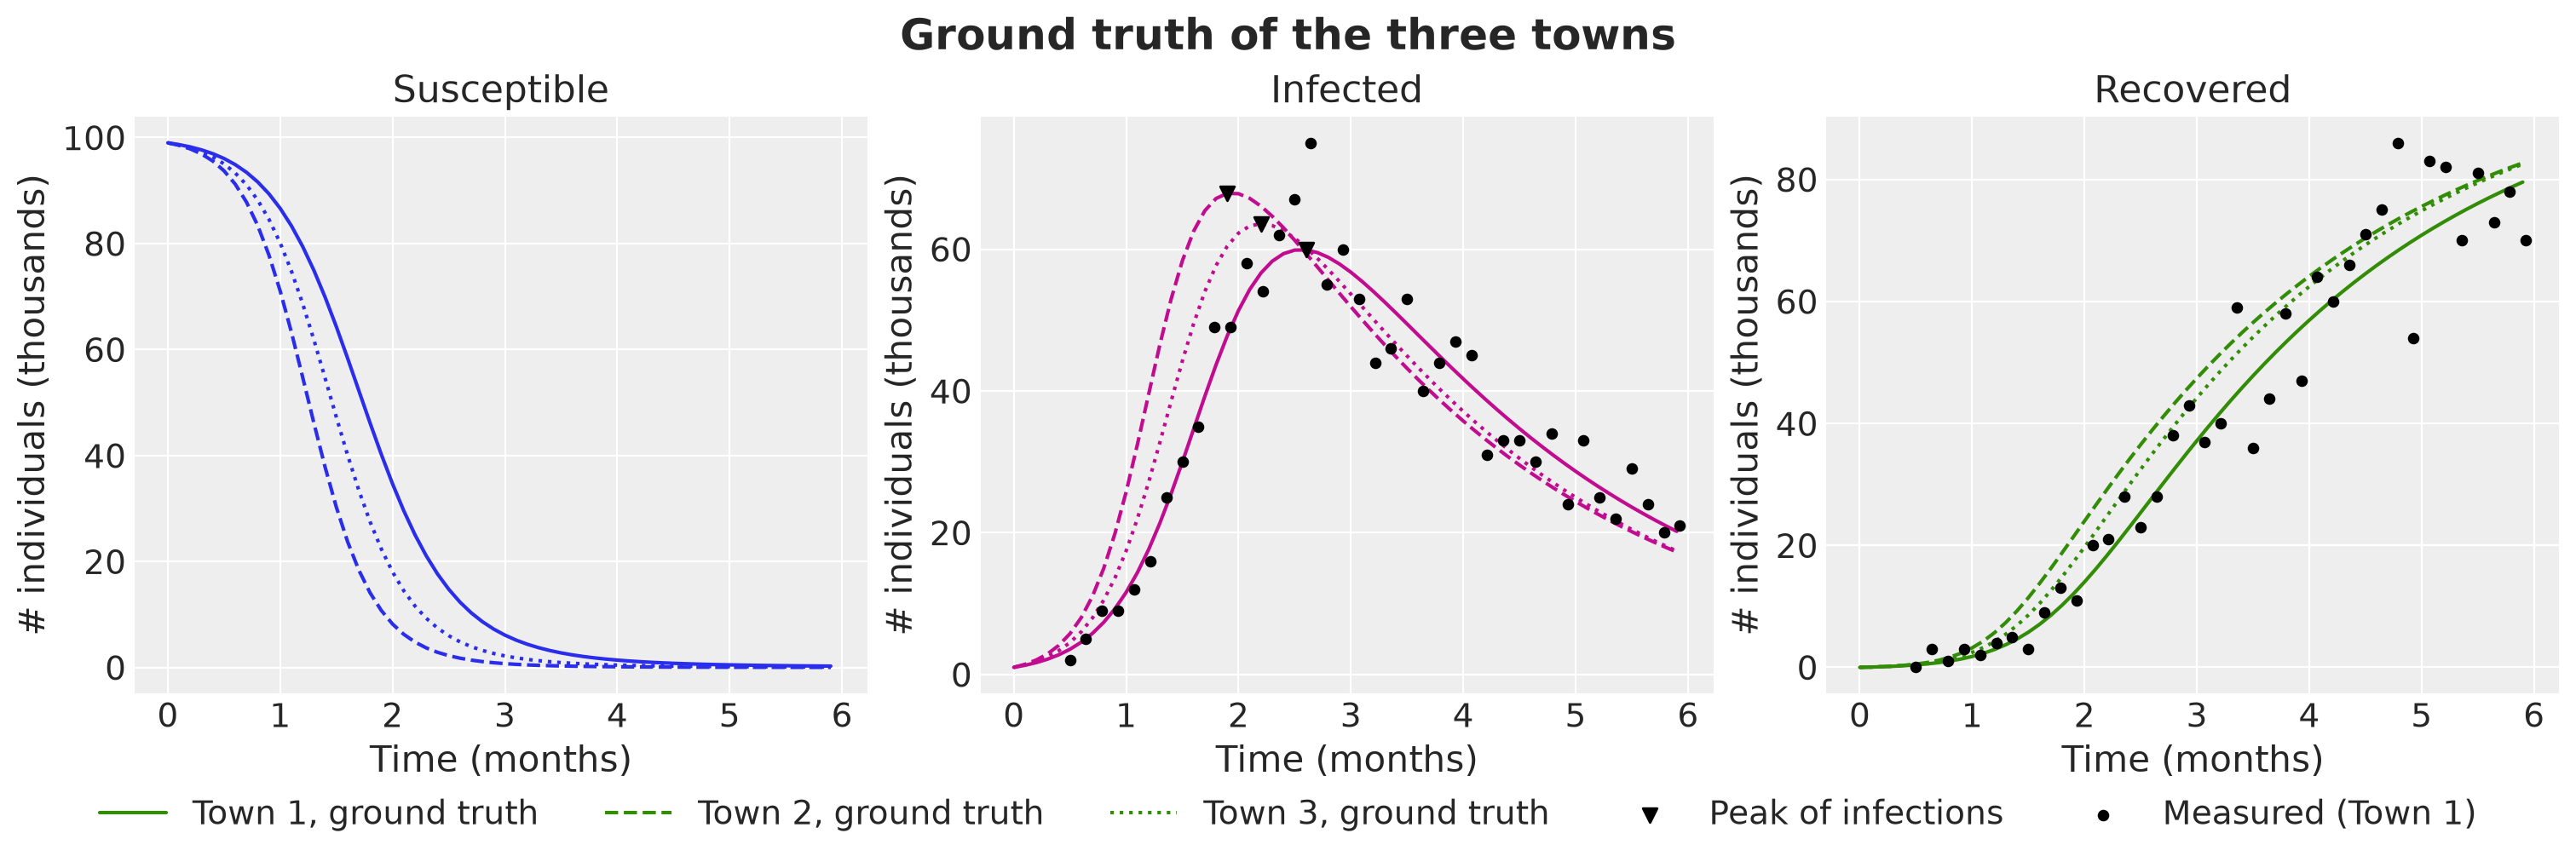

In [31]:
LINESTYLES = ["solid", "dashed", "dotted"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, layout="constrained")
for ax, (name, long_name) in zip(axes, COMPARTMENTS.items(), strict=True):
    for k, town in enumerate(TOWNS):
        ax.plot(
            towns_logging_times,
            towns_true_traj[name][k],
            color=COLORS[name],
            linestyle=LINESTYLES[k],
            label=f"{town}, ground truth",
        )
    ax.set(title=long_name, xlabel="Time (months)", ylabel="# individuals (thousands)")
peaks = towns_true_traj["I"].argmax(axis=-1)
axes[1].scatter(
    towns_logging_times[peaks],
    towns_true_traj["I"][jnp.arange(n_towns), peaks],
    color="black",
    marker="v",
    zorder=4,
    label="Peak of infections",
)
plot_measurements(towns_data, towns_obs_times, axes[1:], label="Measured (Town 1)")
figure_legend(fig, axes, ncol=5)
fig.suptitle("Ground truth of the three towns", fontsize=18, fontweight="bold");

Town 2, with the highest infection rate, peaks first, and Town 1 last. The measurements of Town 1 cover its whole epidemic.

## Multilevel Model

The town-level rates follow inverse gamma distributions, parametrized by their mean and standard deviation. Their means are global parameters with Beta priors:

$$
\bar\beta \sim \text{Beta}(1, 10), \qquad \bar\gamma \sim \text{Beta}(10, 10), \qquad
\beta_k \sim \text{InverseGamma}(\text{mean } \bar\beta, \text{ sd } 0.01), \qquad
\gamma_k \sim \text{InverseGamma}(\text{mean } \bar\gamma, \text{ sd } 0.01).
$$

The town-level rates are drawn inside a `numpyro.plate`, so they are conditionally independent given the global means.

In [32]:
def reparameterize_inverse_gamma(mean: Scalar, std: float) -> tuple[Scalar, Scalar]:
    """Concentration and rate of the inverse gamma with this mean and std."""
    concentration = 2 + mean**2 / std**2
    rate = mean * (concentration - 1)
    return concentration, rate


def bayesian_multilevel_sir(n_towns: int) -> TownParams:
    """Global means with Beta priors, and town-level rates drawn around them."""
    beta_mean = numpyro.sample("beta_mean", dist.Beta(1, 10))
    gamma_mean = numpyro.sample("gamma_mean", dist.Beta(10, 10))
    with numpyro.plate("towns", n_towns):
        beta = numpyro.sample(
            "beta", dist.InverseGamma(*reparameterize_inverse_gamma(beta_mean, 0.01))
        )
        gamma = numpyro.sample(
            "gamma", dist.InverseGamma(*reparameterize_inverse_gamma(gamma_mean, 0.01))
        )
    return {"beta": beta, "gamma": gamma}

To see what this prior says, we compare the prior of one town's rates with their distribution once the global means are known, here $\bar\beta = 0.05$ and $\bar\gamma = 0.75$. Knowing the global means is an observation, so we `condition` on them. Sampling the rates alone involves no ODE, so we can afford $50{,}000$ draws.

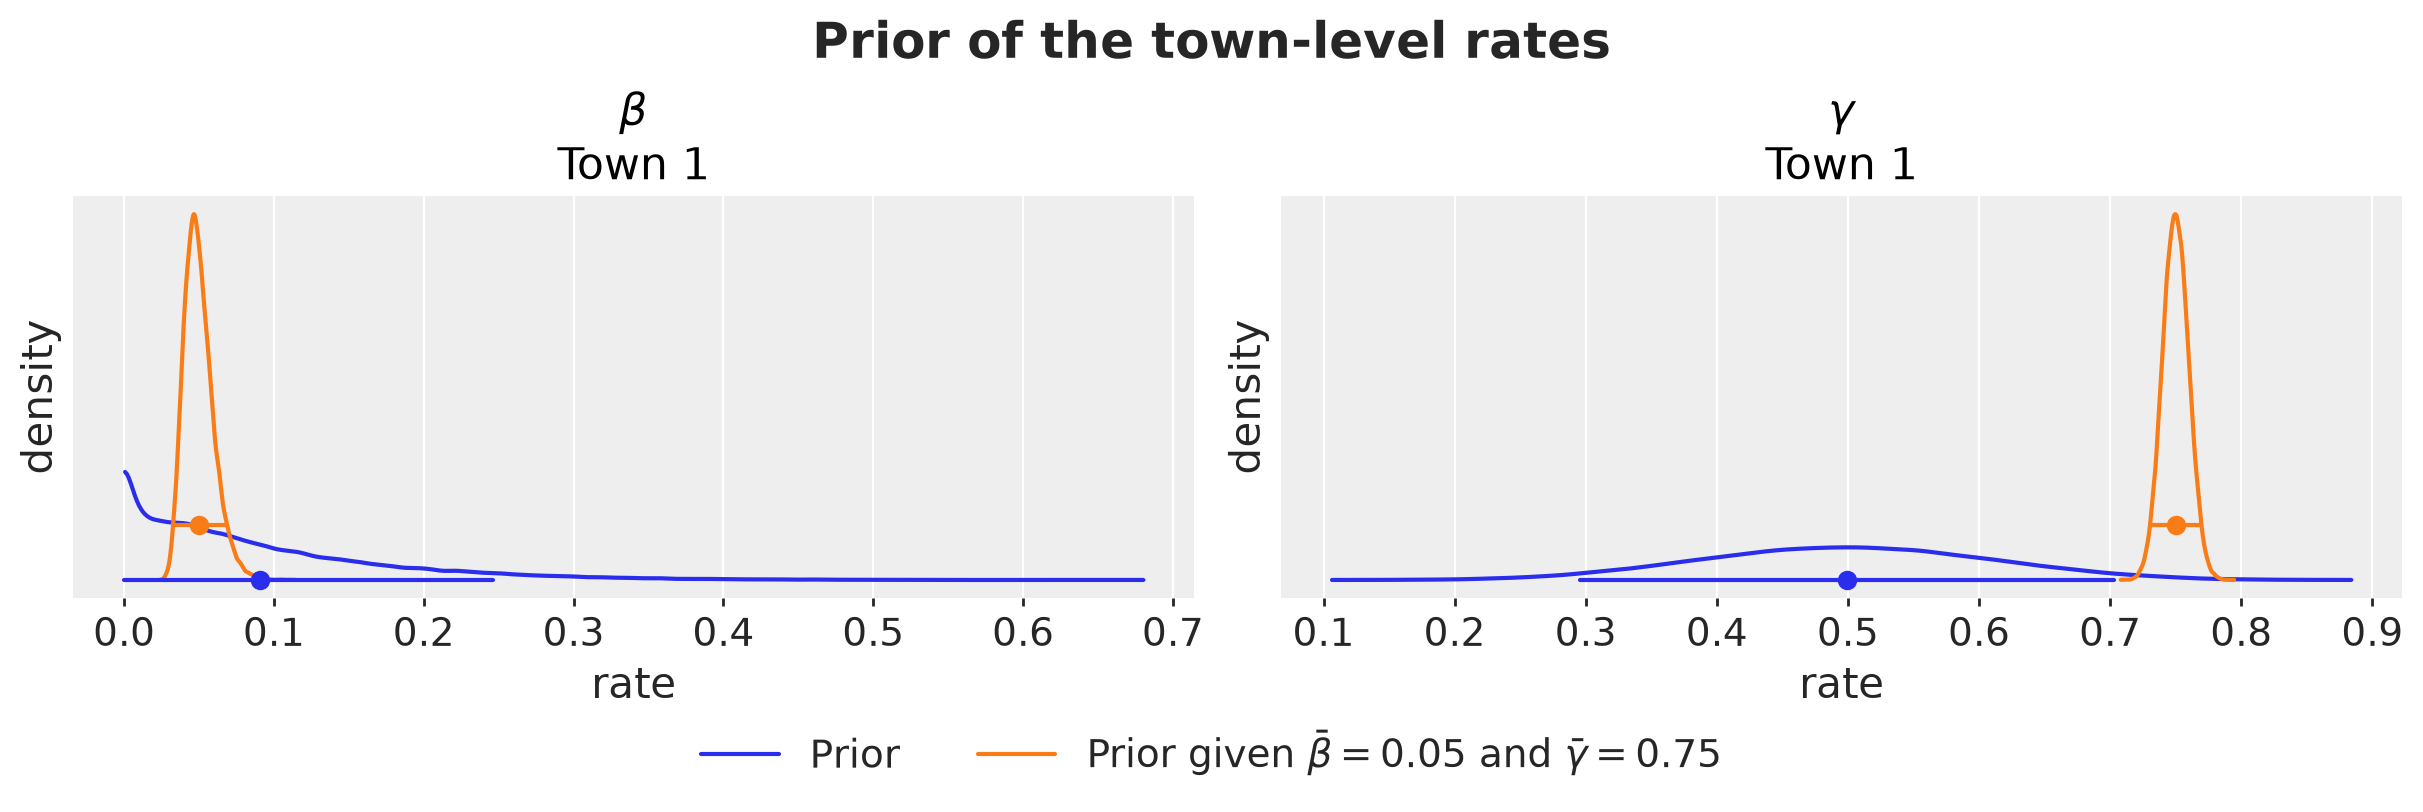

In [33]:
TOWN_DIMS = {"beta": ["town"], "gamma": ["town"]}
TOWN_COORDS = {"town": TOWNS}
MULTILEVEL_LABELS = az.labels.MapLabeller(
    var_name_map=PARAMETER_LABELS.var_name_map
    | {"beta_mean": r"$\bar\beta$", "gamma_mean": r"$\bar\gamma$"}
)

rng_key, rng_subkey = random.split(rng_key)
parameter_prior_samples = Predictive(
    bayesian_multilevel_sir, num_samples=50_000, parallel=True
)(rng_subkey, n_towns)

rng_key, rng_subkey = random.split(rng_key)
conditional_parameter_samples = Predictive(
    condition(
        bayesian_multilevel_sir,
        data=as_scalars({"beta_mean": 0.05, "gamma_mean": 0.75}),
    ),
    num_samples=50_000,
    parallel=True,
)(rng_subkey, n_towns)

pc = az.plot_dist(
    {
        "Prior": to_datatree(
            prior=parameter_prior_samples, dims=TOWN_DIMS, coords=TOWN_COORDS
        ),
        r"Prior given $\bar\beta = 0.05$ and $\bar\gamma = 0.75$": to_datatree(
            prior=conditional_parameter_samples, dims=TOWN_DIMS, coords=TOWN_COORDS
        ),
    },
    group="prior",
    var_names=["beta", "gamma"],
    coords={"town": [TOWNS[0]]},
    kind="kde",
    labeller=MULTILEVEL_LABELS,
    visuals={"point_estimate_text": False},
    figure_kwargs={"figsize": (12, 4), "layout": "constrained"},
)
pc.add_legend("model", title="", loc="outside lower center", ncol=2)
label_density_axes(pc)
pc.viz["figure"].item().suptitle(
    "Prior of the town-level rates", fontsize=18, fontweight="bold"
);

The prior of a town's rates is broad, but given the global means it is narrow. In other words, most of the prior uncertainty is uncertainty about the global means. This is what lets data from one town inform the others. The prior of a town's rates is the same for every town, so we only show Town 1.

The probabilistic program simulates every town with rates drawn from this prior. It is `simulated_bayesian_sir` with the multilevel prior and `simulate_towns`. The helper `plot_towns` draws a grid with one row of panels per town and returns it, so that we can add lines to the panels before the legend.

In [34]:
def simulated_multilevel_bayesian_sir(
    init_state: TownState, start_time: Number, logging_times: Times
) -> TownTrajectories:
    """The trajectories of every town under the multilevel prior."""
    params = bayesian_multilevel_sir(n_towns=len(init_state["S"]))
    return log_trajectory(
        simulate_towns(sir_dynamics, params, init_state, start_time, logging_times)
    )


def select_town(tree: dict[str, Array], k: int) -> dict[str, Array]:
    """The compartments of town `k`, whose axis is the second to last."""
    return {name: tree[name][..., k, :] for name in COMPARTMENTS}


def plot_towns(
    samples: Samples, truth: dict[str, Array], times: Times, **kwargs
) -> tuple[plt.Figure, np.ndarray]:
    """`plot_trajectories` for every town, on a grid with one row per town."""
    fig, axes = plt.subplots(
        3, 3, figsize=(15, 12), sharex=True, sharey="col", layout="constrained"
    )
    for k, (town, row) in enumerate(zip(TOWNS, axes, strict=True)):
        plot_trajectories(
            select_town(samples, k),
            select_town(truth, k),
            times,
            row,
            units="thousands",
            **kwargs,
        )
        for ax, long_name in zip(row, COMPARTMENTS.values(), strict=True):
            ax.set_title(f"{town}: {long_name}")
    for ax in axes[:-1].flat:  # the x label only on the last row
        ax.set_xlabel("")
    return fig, axes

Here is the prior predictive distribution of the three epidemics, with $500$ draws as in the original tutorial.

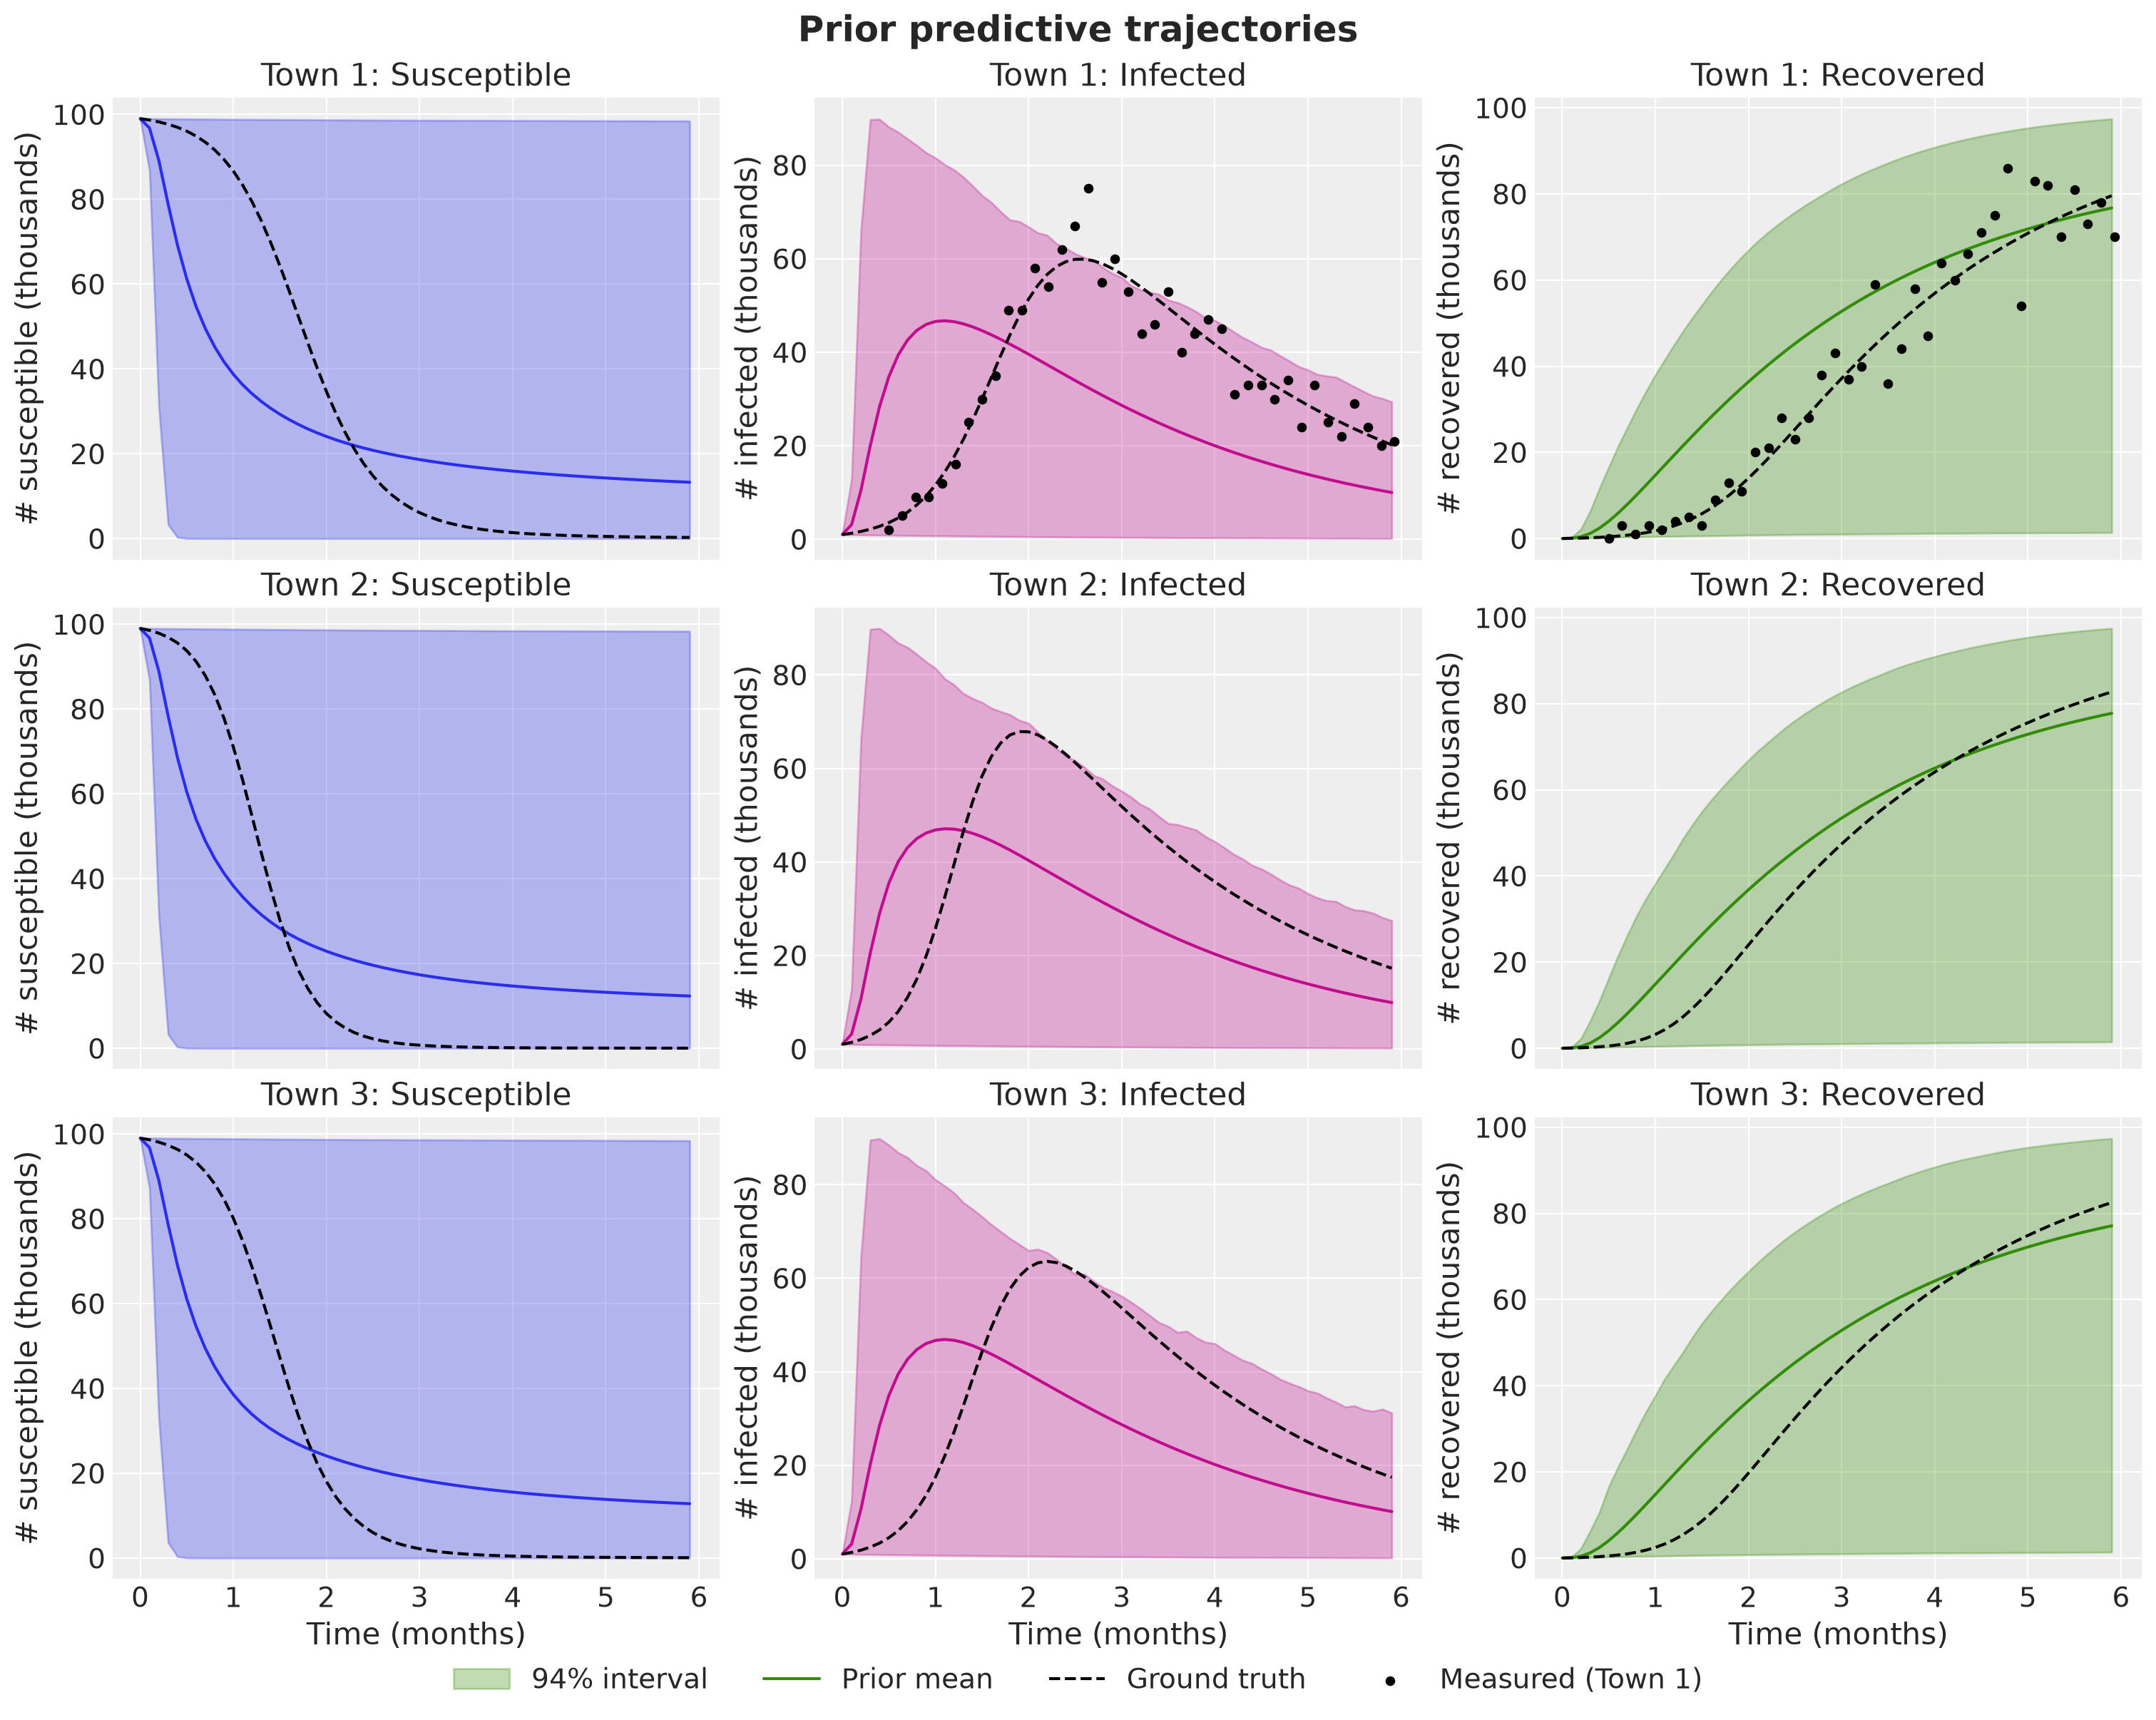

In [35]:
multilevel_num_samples = 500

rng_key, rng_subkey = random.split(rng_key)
multilevel_prior_predictive = jax.jit(
    Predictive(simulated_multilevel_bayesian_sir, num_samples=multilevel_num_samples)
)
towns_prior_samples = multilevel_prior_predictive(
    rng_subkey, towns_init_state, start_time, towns_logging_times
)

fig, axes = plot_towns(
    towns_prior_samples,
    towns_true_traj,
    towns_logging_times,
    estimate_label="Prior mean",
)
plot_measurements(towns_data, towns_obs_times, axes[0, 1:], label="Measured (Town 1)")
figure_legend(fig, axes)
fig.suptitle("Prior predictive trajectories", fontsize=18, fontweight="bold");

Without any data, the prior puts extremely broad uncertainty on the dynamics in every town.

## Inference from One Town

The conditioned model mirrors `observed_sir`: it simulates every town at the measurement times and scores the measurements of Town 1. As in the original, SVI with a multivariate normal guide runs for $200$ steps.

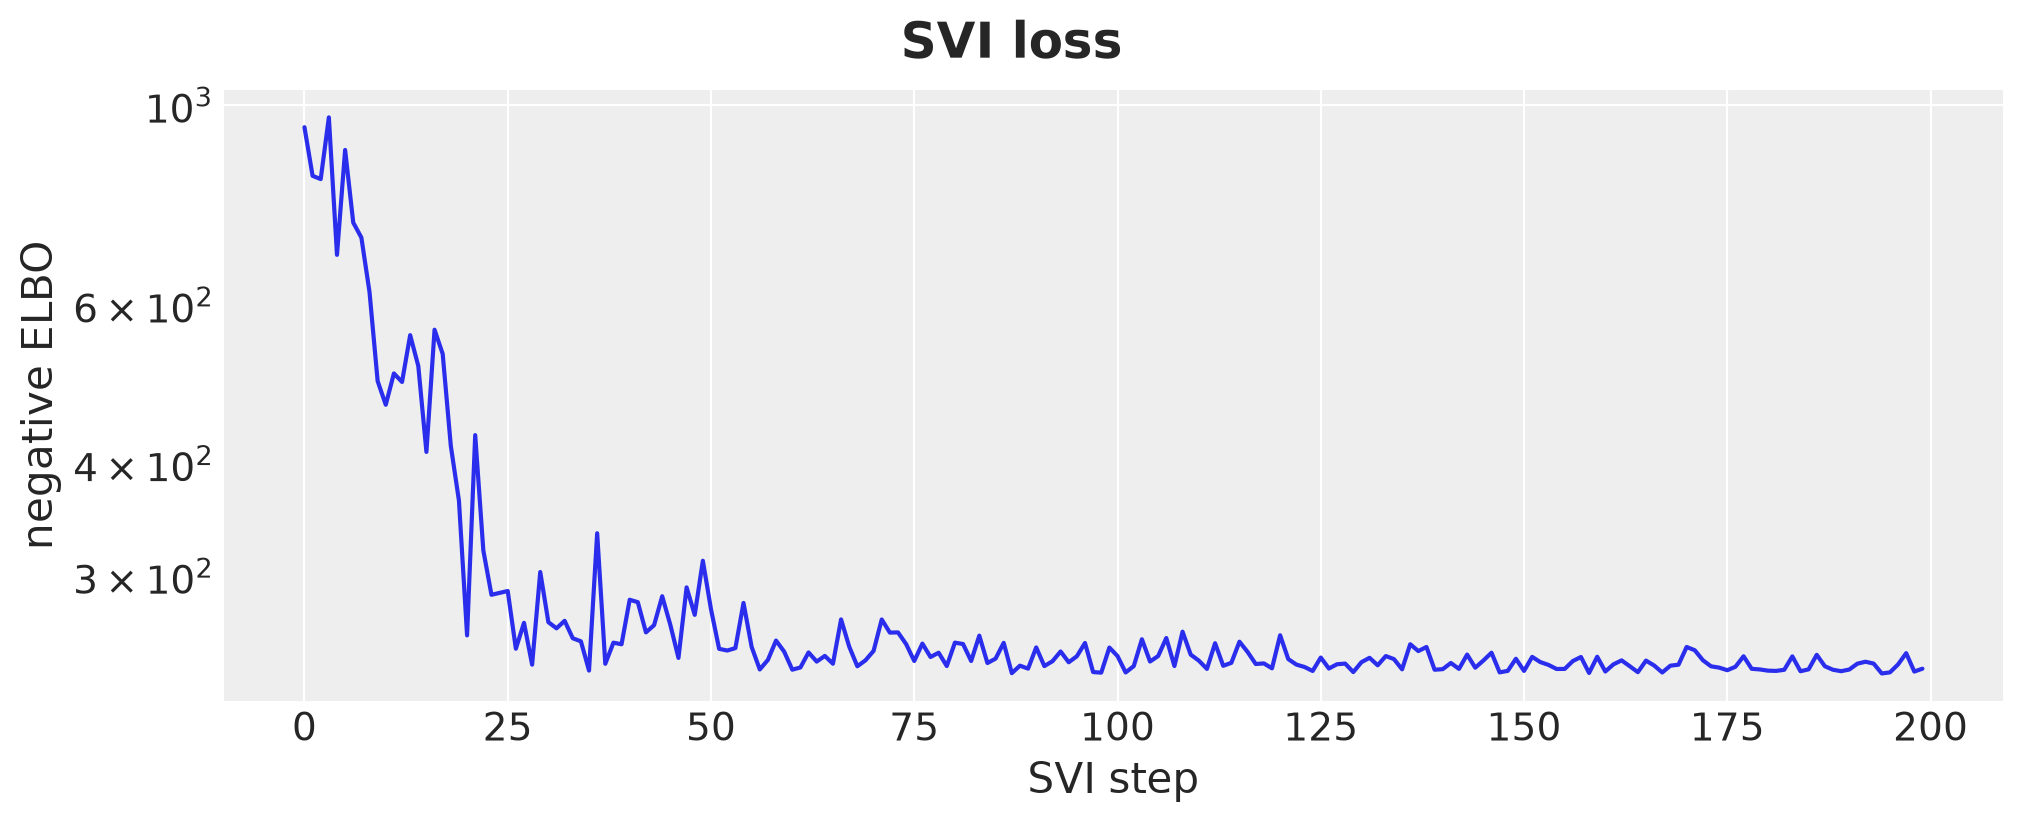

In [36]:
def observed_multilevel_sir(
    obs_times: Times, init_state: TownState, start_time: Number
) -> None:
    """The generative model of the measurements, taken in the first town only."""
    params = bayesian_multilevel_sir(n_towns=len(init_state["S"]))
    single_observation_model(
        simulate_towns(sir_dynamics, params, init_state, start_time, obs_times)
    )


multilevel_num_steps = 200

rng_key, rng_subkey = random.split(rng_key)
towns_guide, towns_svi_result = run_svi(
    condition(observed_multilevel_sir, data=towns_data),
    rng_subkey,
    towns_obs_times,
    towns_init_state,
    start_time,
    num_steps=multilevel_num_steps,
)

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(towns_svi_result.losses)
ax.set(xlabel="SVI step", ylabel="negative ELBO", yscale="log")
fig.suptitle("SVI loss", fontsize=18, fontweight="bold");

The loss flattens after about $50$ steps, at about $240$.

As before, we draw the parameters from the guide once and reuse the draws for every predictive distribution below. We compare them with the $500$ prior draws of the prior predictive check, as in the original. The dashed lines are the true town-level rates.

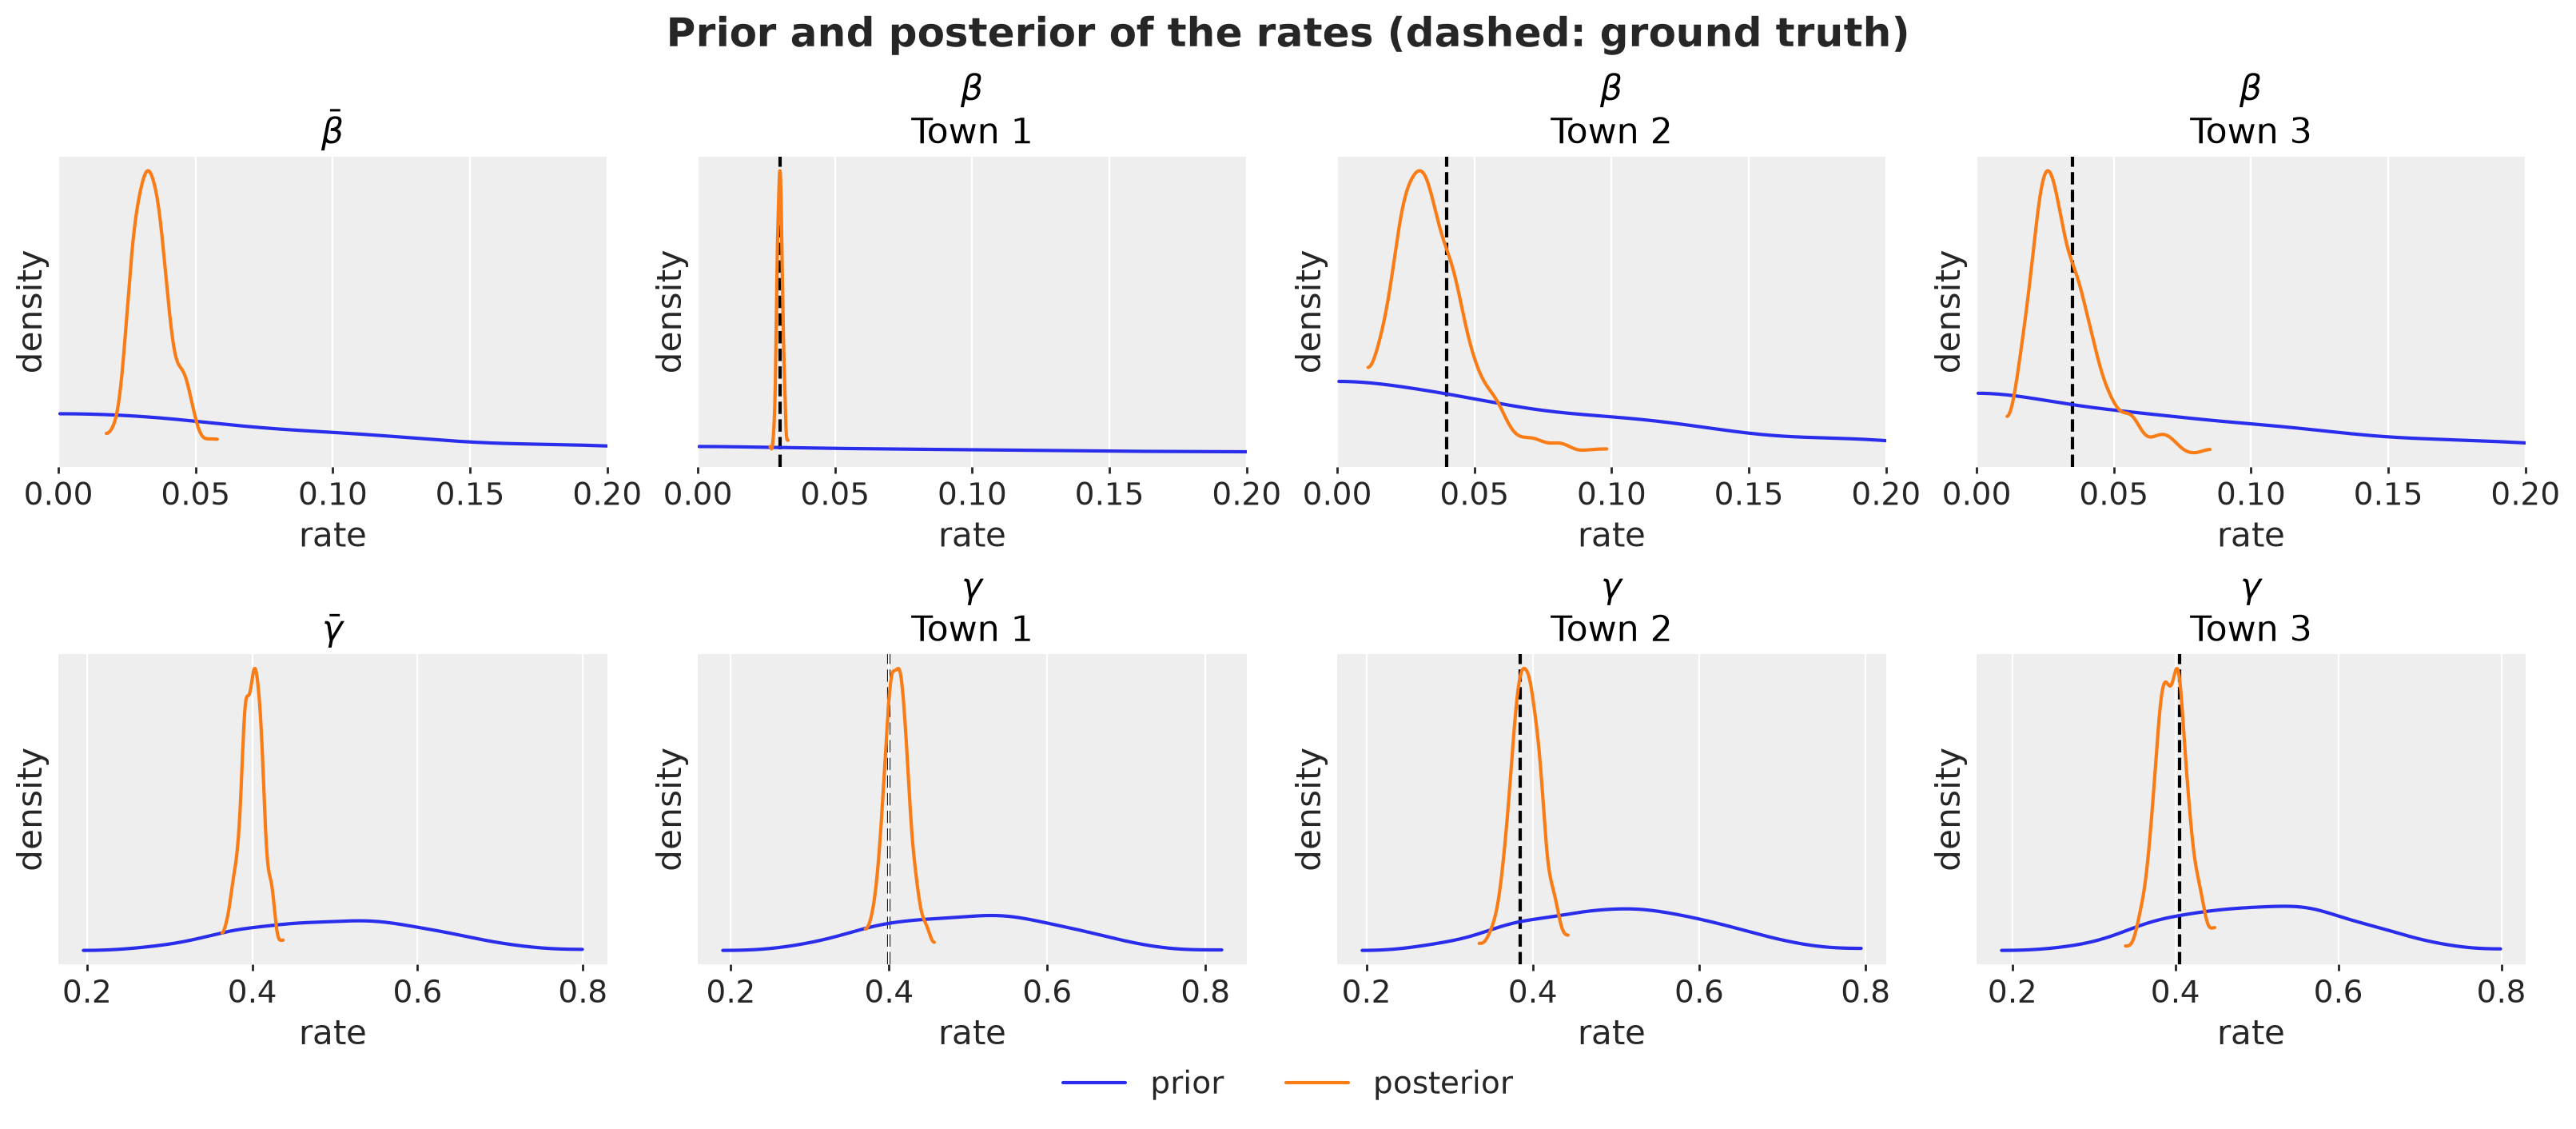

In [37]:
rng_key, rng_subkey = random.split(rng_key)
towns_posterior = towns_guide.sample_posterior(
    rng_subkey, towns_svi_result.params, sample_shape=(multilevel_num_samples,)
)

towns_true_values = xr.Dataset(
    {k: ("town", np.asarray(v)) for k, v in towns_true_params.items()},
    coords=TOWN_COORDS,
)

pc = az.plot_prior_posterior(
    to_datatree(
        prior={k: towns_prior_samples[k] for k in towns_posterior},
        posterior=towns_posterior,
        dims=TOWN_DIMS,
        coords=TOWN_COORDS,
    ),
    var_names=["beta_mean", "beta", "gamma_mean", "gamma"],
    kind="kde",
    labeller=MULTILEVEL_LABELS,
    cols=["__variable__", "town"],
    col_wrap=1 + n_towns,
    figure_kwargs={"figsize": (16, 7), "layout": "constrained"},
)
az.add_lines(
    pc, towns_true_values, visuals={"ref_line": {"color": "black", "linestyle": "--"}}
)
for ax in [pc.viz["plot"]["beta_mean"].item(), *pc.viz["plot"]["beta"].values]:
    ax.set_xlim(0, 0.2)  # the prior has a long tail
label_density_axes(pc)
fig = pc.viz["figure"].item()
fig.legends[0].remove()  # the default legend sits on the title row
pc.add_legend("group", title="", loc="outside lower center", ncol=2)
fig.suptitle(
    "Prior and posterior of the rates (dashed: ground truth)",
    fontsize=18,
    fontweight="bold",
);

The posterior narrows the most for Town 1, whose rates the measurements constrain directly. But the rates of Towns 2 and 3 move too. Information flows through the model: the measurements of Town 1 inform its rates, its rates inform the global means $\bar\beta$ and $\bar\gamma$, and, as the prior showed, given the global means the rates of the other towns are narrow.

Now we compare the posterior predictive trajectories of every town with the ground truth.

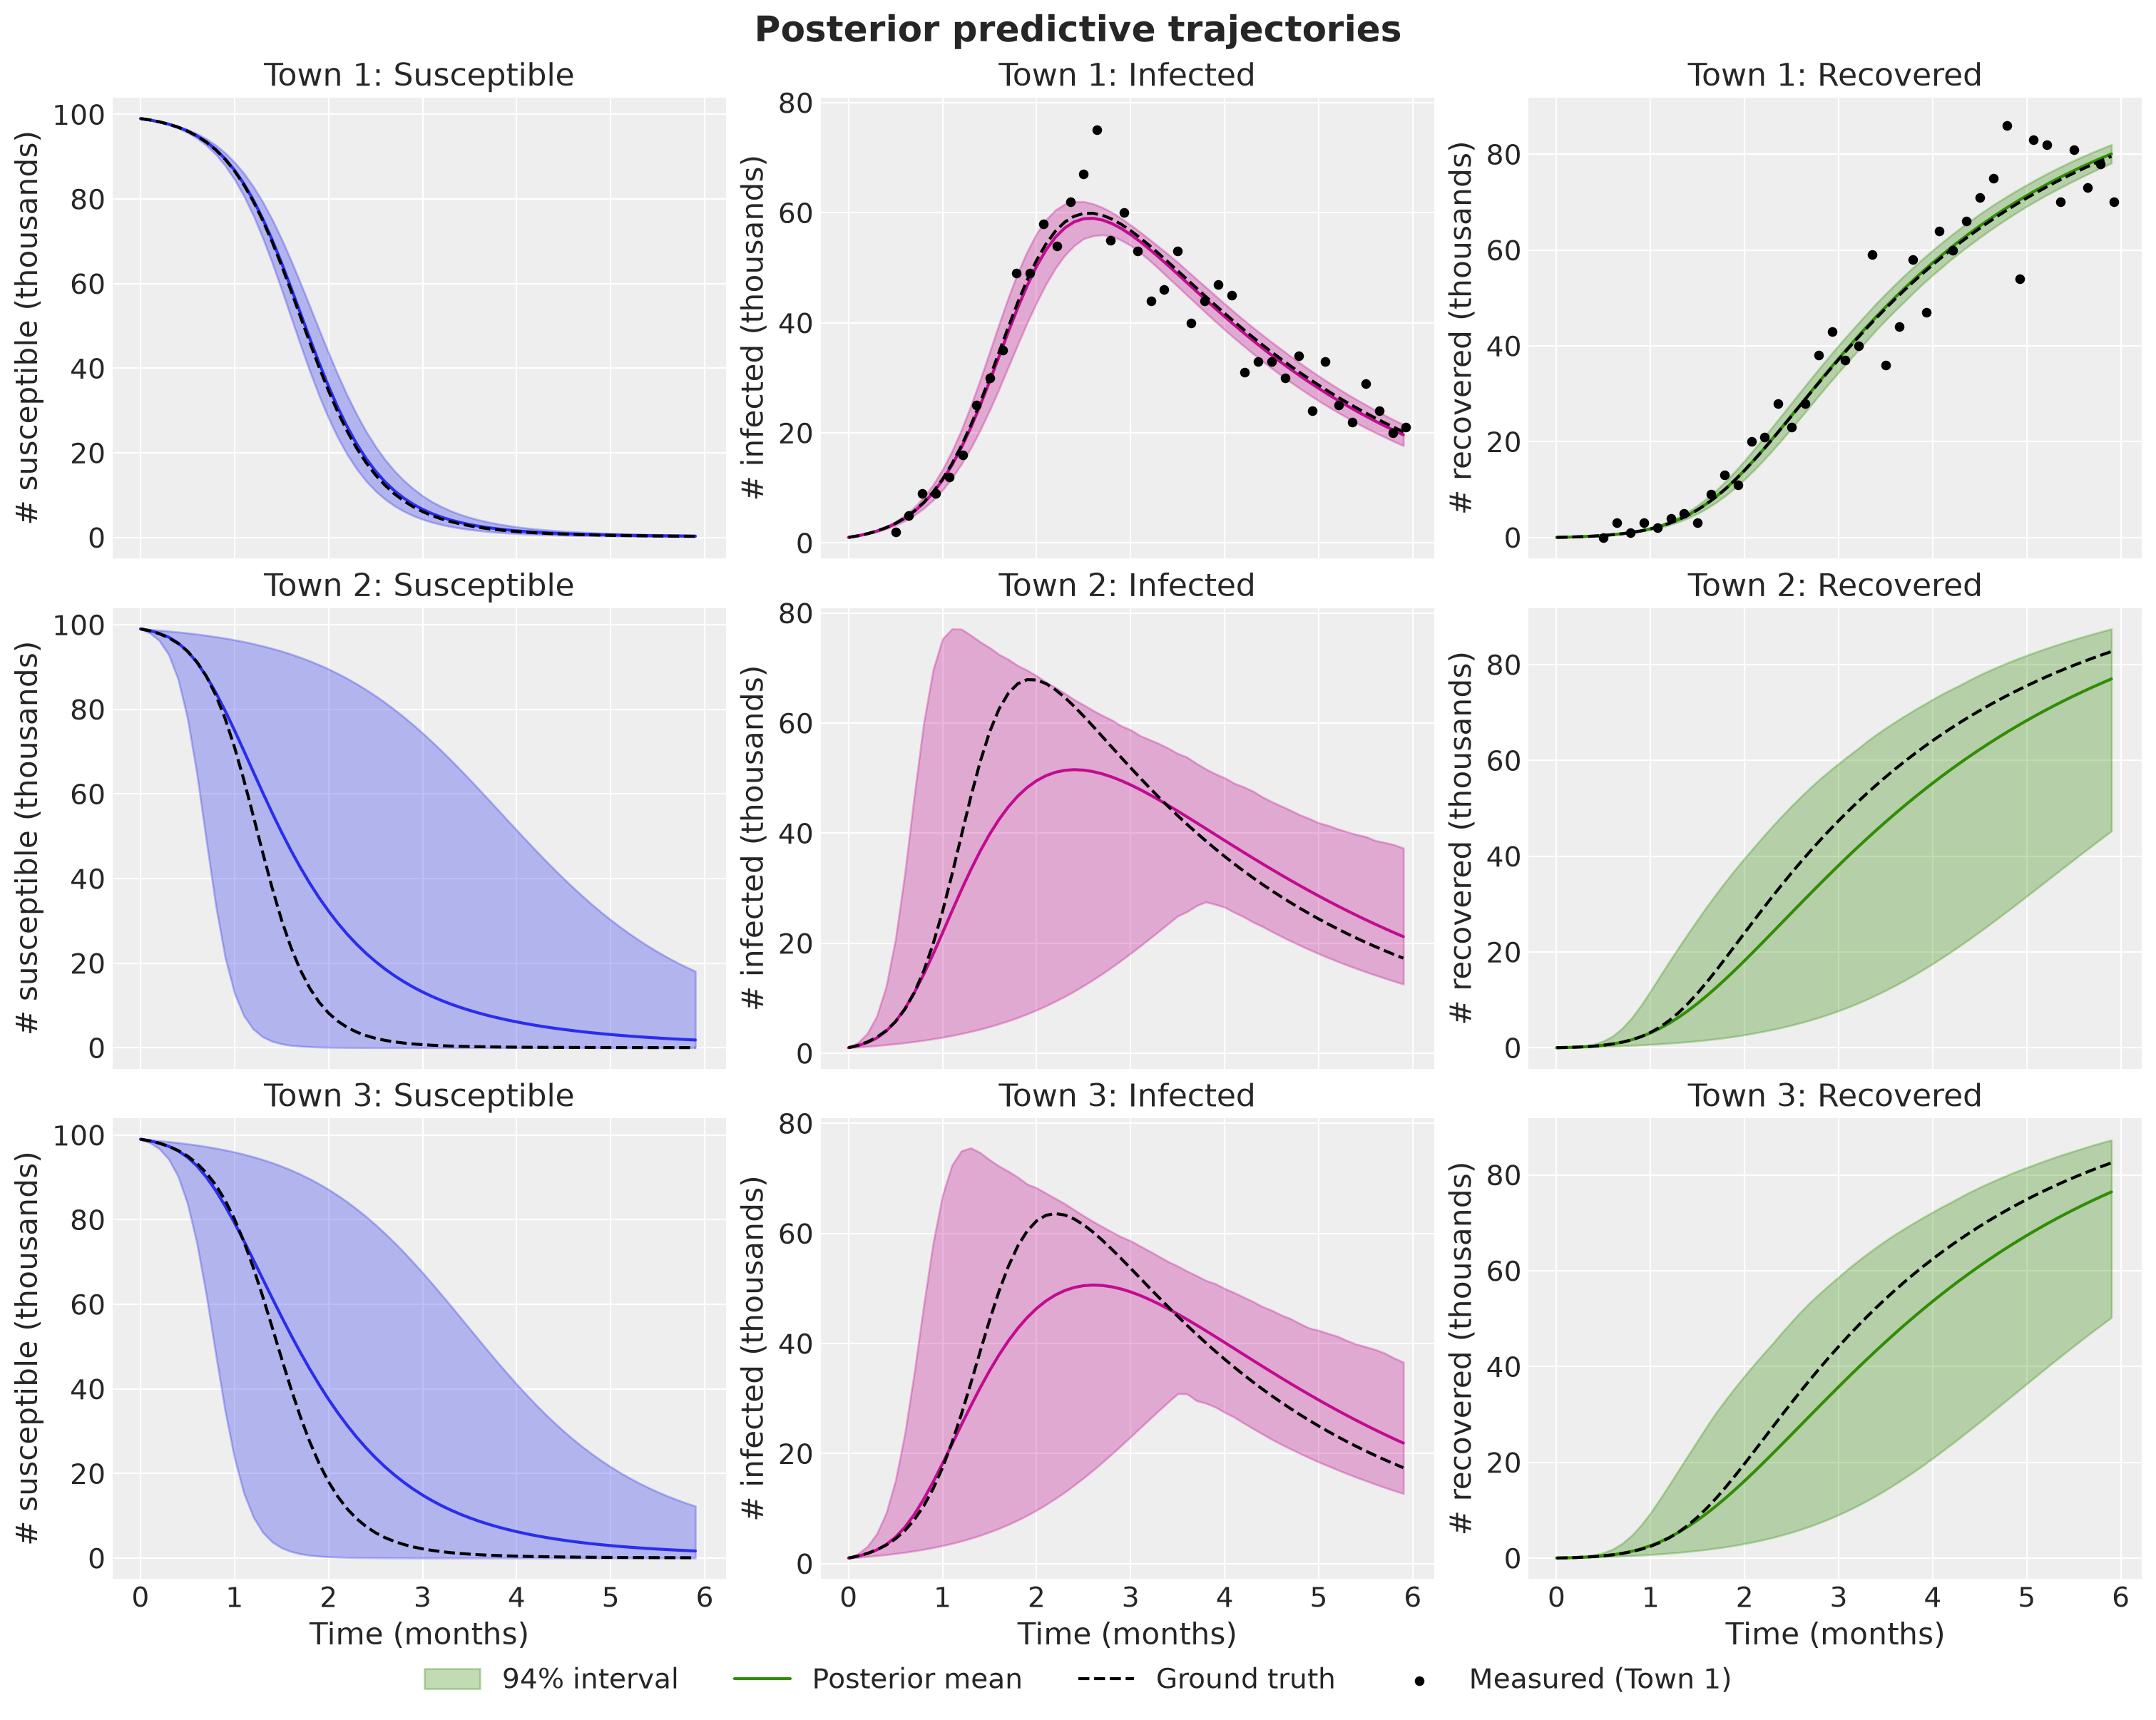

In [38]:
rng_key, rng_subkey = random.split(rng_key)
multilevel_predictive = jax.jit(
    Predictive(simulated_multilevel_bayesian_sir, posterior_samples=towns_posterior)
)
towns_posterior_samples = towns_posterior | multilevel_predictive(
    rng_subkey, towns_init_state, start_time, towns_logging_times
)

fig, axes = plot_towns(towns_posterior_samples, towns_true_traj, towns_logging_times)
plot_measurements(towns_data, towns_obs_times, axes[0, 1:], label="Measured (Town 1)")
figure_legend(fig, axes)
fig.suptitle("Posterior predictive trajectories", fontsize=18, fontweight="bold");

The posterior predictive distribution is much narrower for Town 1, where we have measurements, than for Towns 2 and 3. Still, the predictions for Towns 2 and 3 are narrower than under the prior, because of what Town 1 taught us about the global rates.

## Lockdown in Every Town

As in the first tutorial, the government can enact a lockdown of strength $l(t)$ that scales the transmission rate, and `sir_dynamics_lockdown` applies to each town unchanged. Following the original, a lockdown of strength $0.7$ starts at $t = 1$ in every town and is never lifted. A single `static_intervention` suffices, because `simulate_towns` applies its interventions in every town.

In [39]:
def intervened_multilevel_sir(
    lockdown_start: Number,
    lockdown_strength: Number,
    init_state: TownState,
    start_time: Number,
    logging_times: Times,
) -> TownTrajectories:
    """Every town locks down at `lockdown_start` with strength `lockdown_strength`."""
    params = bayesian_multilevel_sir(n_towns=len(init_state["S"]))
    interventions = (static_intervention(lockdown_start, {"l": lockdown_strength}),)
    return log_trajectory(
        simulate_towns(
            sir_dynamics_lockdown,
            params,
            init_state,
            start_time,
            logging_times,
            interventions,
        )
    )

The ground truth fixes the town-level rates to their true values with `condition`. The global means are still drawn, hence the `seed`, but they do not affect the trajectories. We draw the prior and the posterior predictive distributions under the lockdown.

In [40]:
towns_init_state_lockdown = towns_init_state | {"l": jnp.zeros(n_towns)}
towns_lockdown_strength = 0.7

true_intervened_multilevel_sir = seed(
    condition(intervened_multilevel_sir, data=towns_true_params), rng_seed=0
)
towns_true_intervened_traj = true_intervened_multilevel_sir(
    lockdown_start,
    towns_lockdown_strength,
    towns_init_state_lockdown,
    start_time,
    towns_logging_times,
)

rng_key, rng_subkey = random.split(rng_key)
intervened_multilevel_prior_predictive = jax.jit(
    Predictive(intervened_multilevel_sir, num_samples=multilevel_num_samples)
)
intervened_towns_prior_samples = intervened_multilevel_prior_predictive(
    rng_subkey,
    lockdown_start,
    towns_lockdown_strength,
    towns_init_state_lockdown,
    start_time,
    towns_logging_times,
)

rng_key, rng_subkey = random.split(rng_key)
intervened_multilevel_predictive = jax.jit(
    Predictive(intervened_multilevel_sir, posterior_samples=towns_posterior)
)
intervened_towns_posterior_samples = intervened_multilevel_predictive(
    rng_subkey,
    lockdown_start,
    towns_lockdown_strength,
    towns_init_state_lockdown,
    start_time,
    towns_logging_times,
)

First, let's look at the prior predictive distribution under the lockdown.

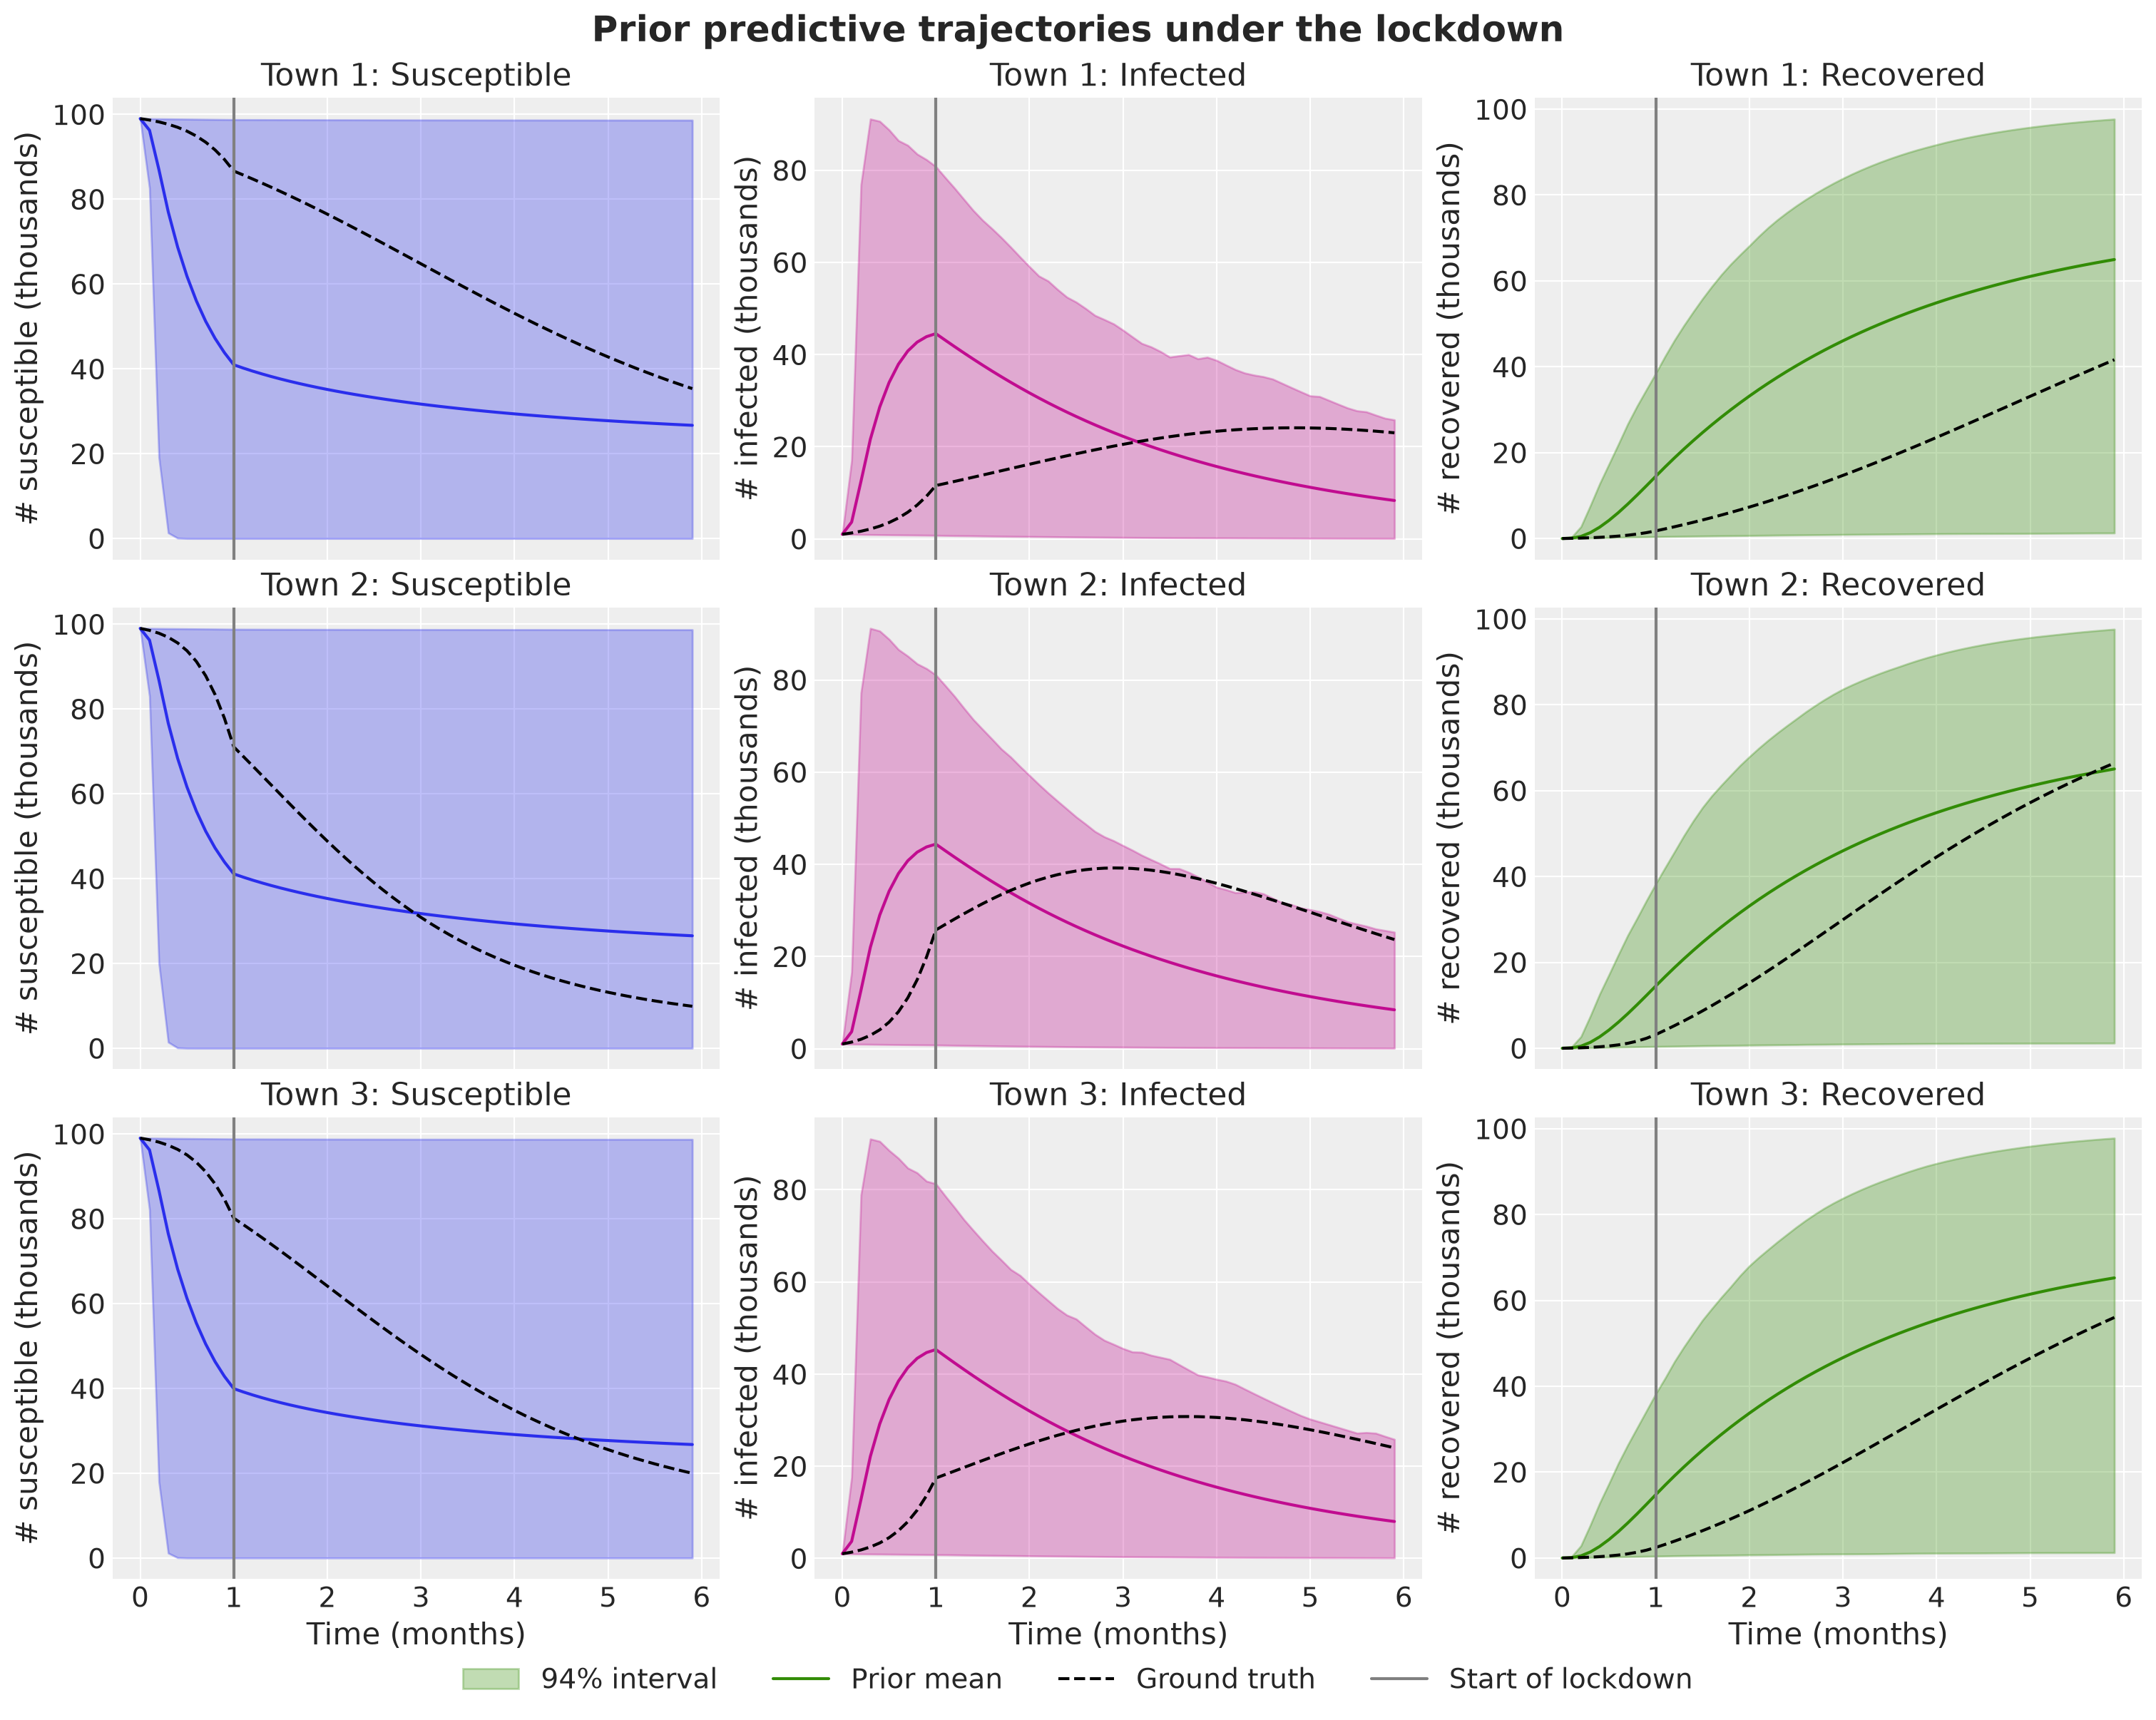

In [41]:
fig, axes = plot_towns(
    intervened_towns_prior_samples,
    towns_true_intervened_traj,
    towns_logging_times,
    estimate_label="Prior mean",
)
for ax in axes.flat:
    ax.axvline(lockdown_start, color="gray", label="Start of lockdown")
figure_legend(fig, axes)
fig.suptitle(
    "Prior predictive trajectories under the lockdown", fontsize=18, fontweight="bold"
);

Before seeing any data, the predicted effect of the lockdown is extremely uncertain, although the bands cover the true intervened trajectories.

Next, we draw the same figure with the posterior draws.

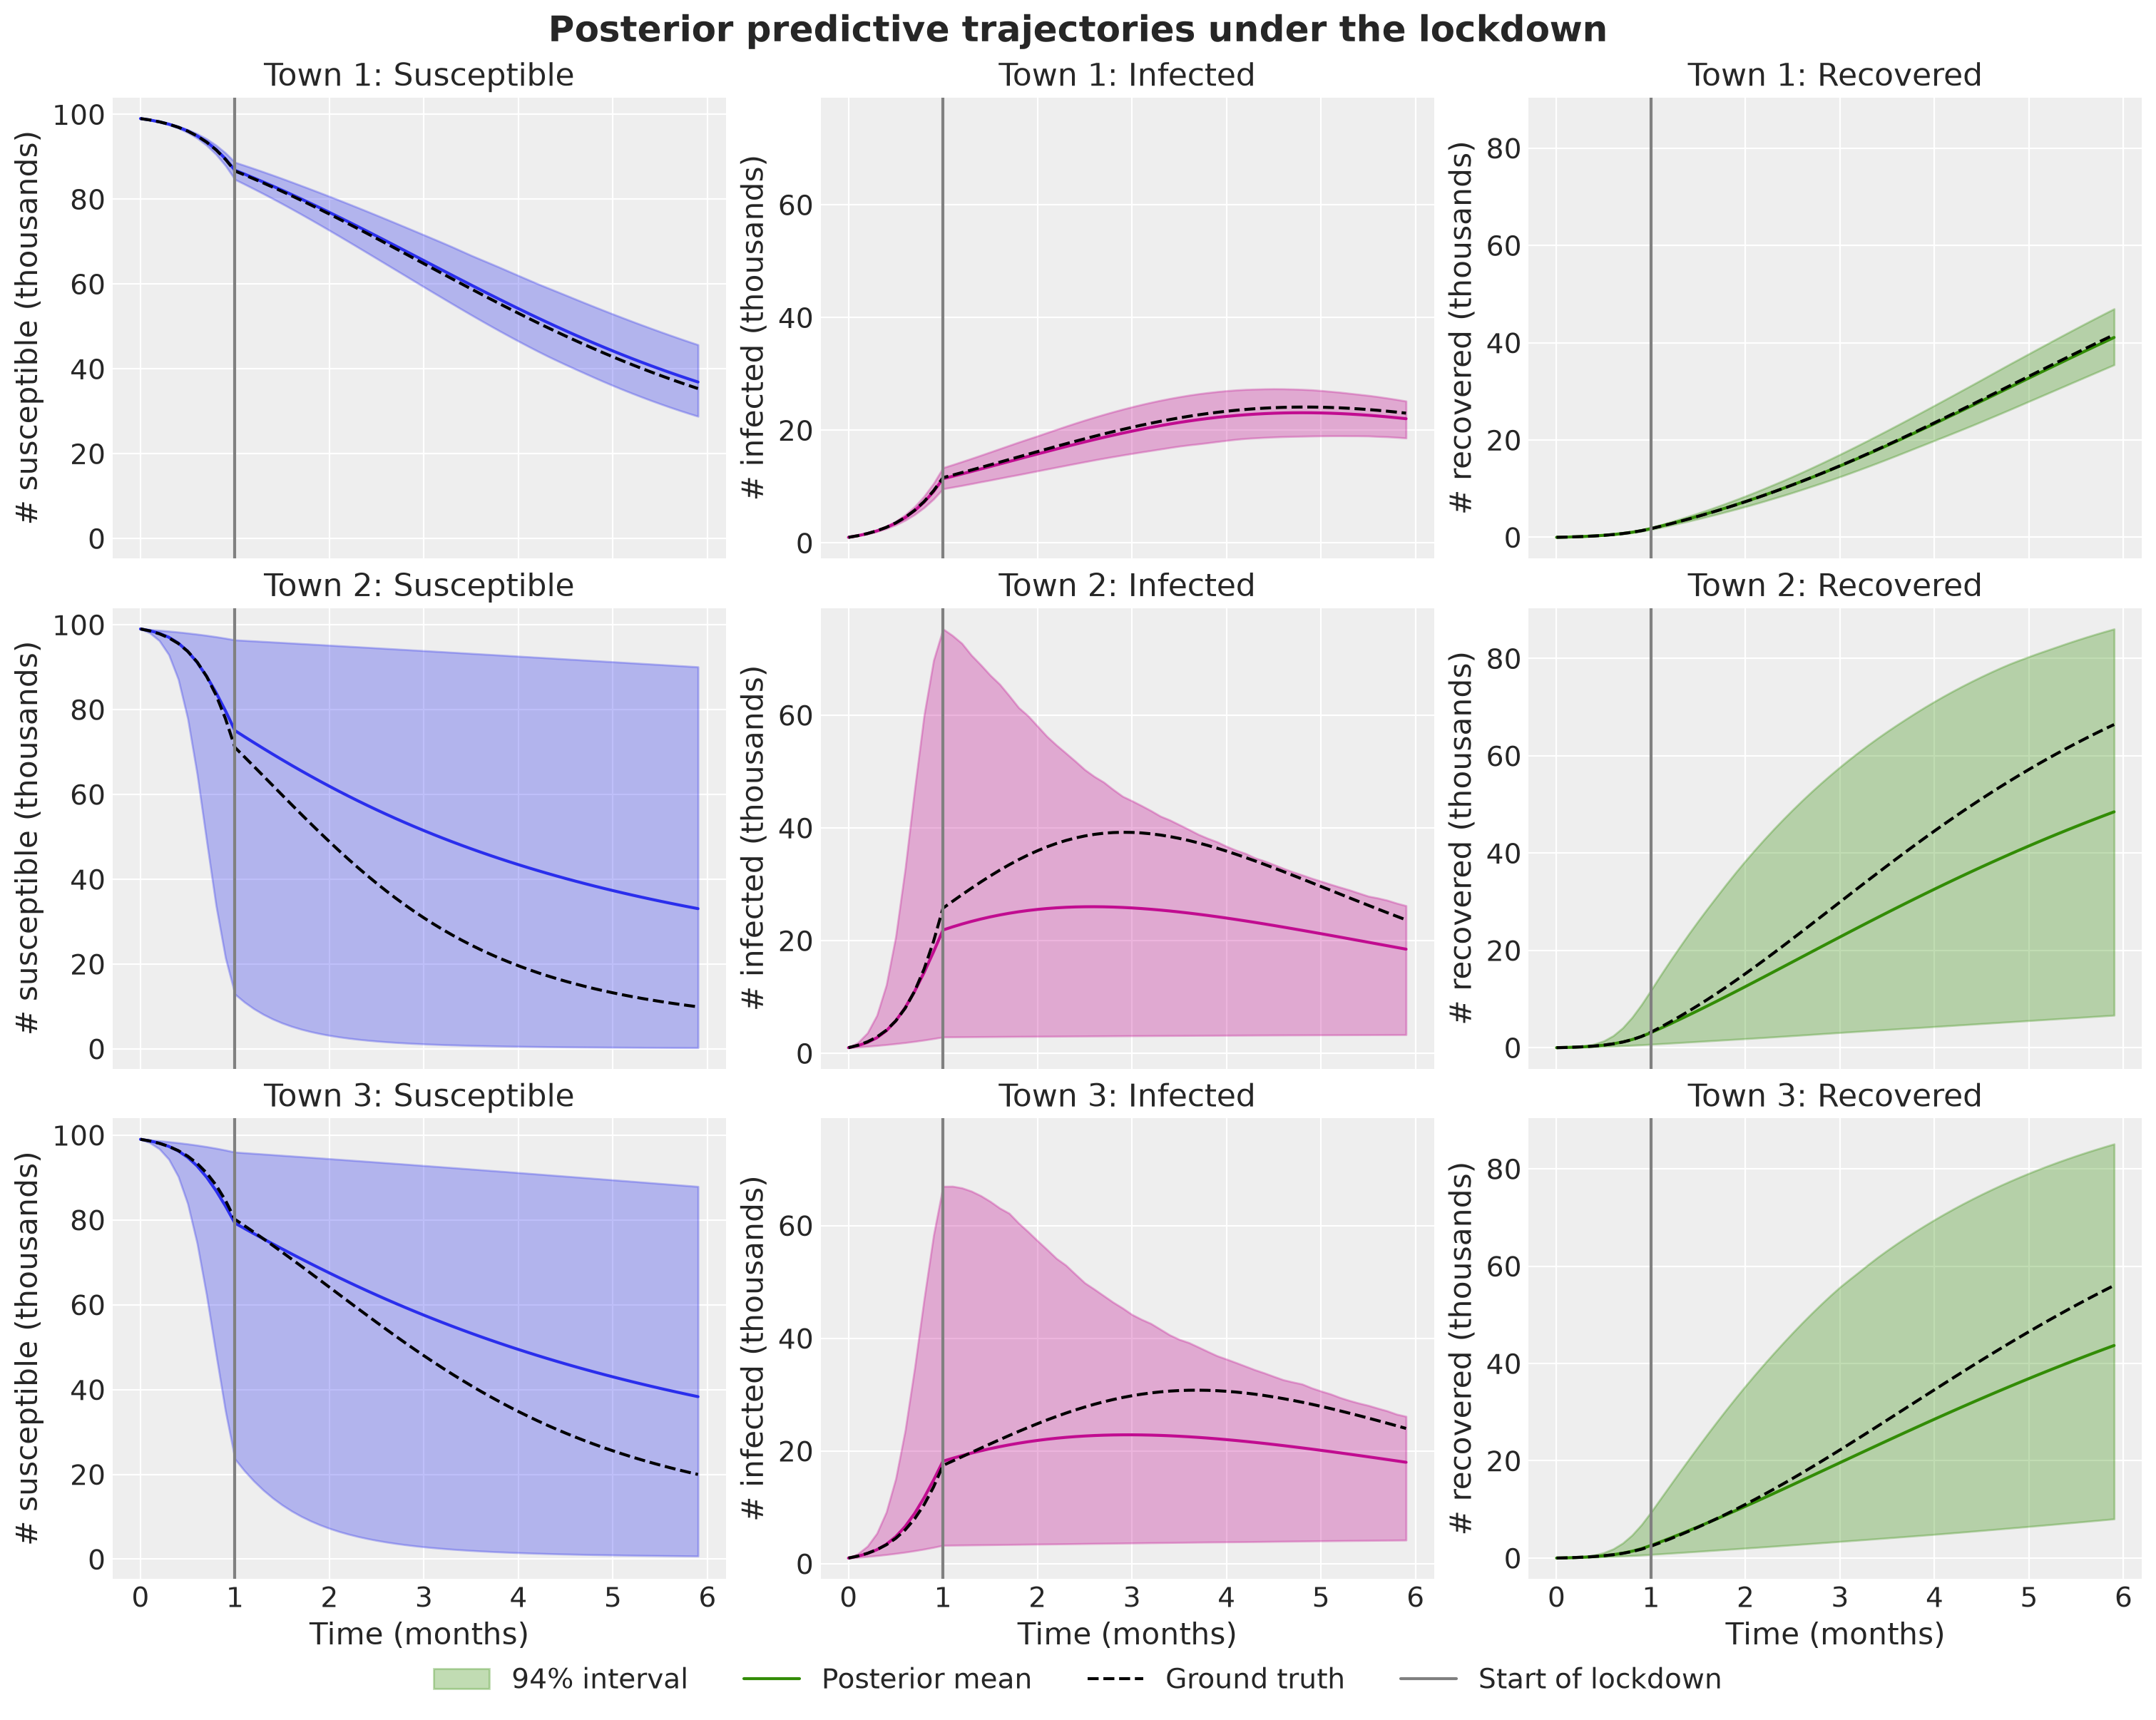

In [42]:
fig, axes = plot_towns(
    intervened_towns_posterior_samples, towns_true_intervened_traj, towns_logging_times
)
for ax in axes.flat:
    ax.axvline(lockdown_start, color="gray", label="Start of lockdown")
figure_legend(fig, axes)
fig.suptitle(
    "Posterior predictive trajectories under the lockdown",
    fontsize=18,
    fontweight="bold",
);

After seeing the measurements of Town 1, the predictions under the lockdown are much more certain. As without the lockdown, they are much more certain for Town 1 than for Towns 2 and 3, whose predictions are still informed by the measurements of Town 1.

## Comparing Towns

This section is not in the original tutorial. As at the end of the first part, we compare the peak number of infected and the number of people ever infected by the end of the forecast, now with one row per town. We contrast the lockdown predicted before seeing any data, the posterior without a lockdown, and the posterior with the lockdown.

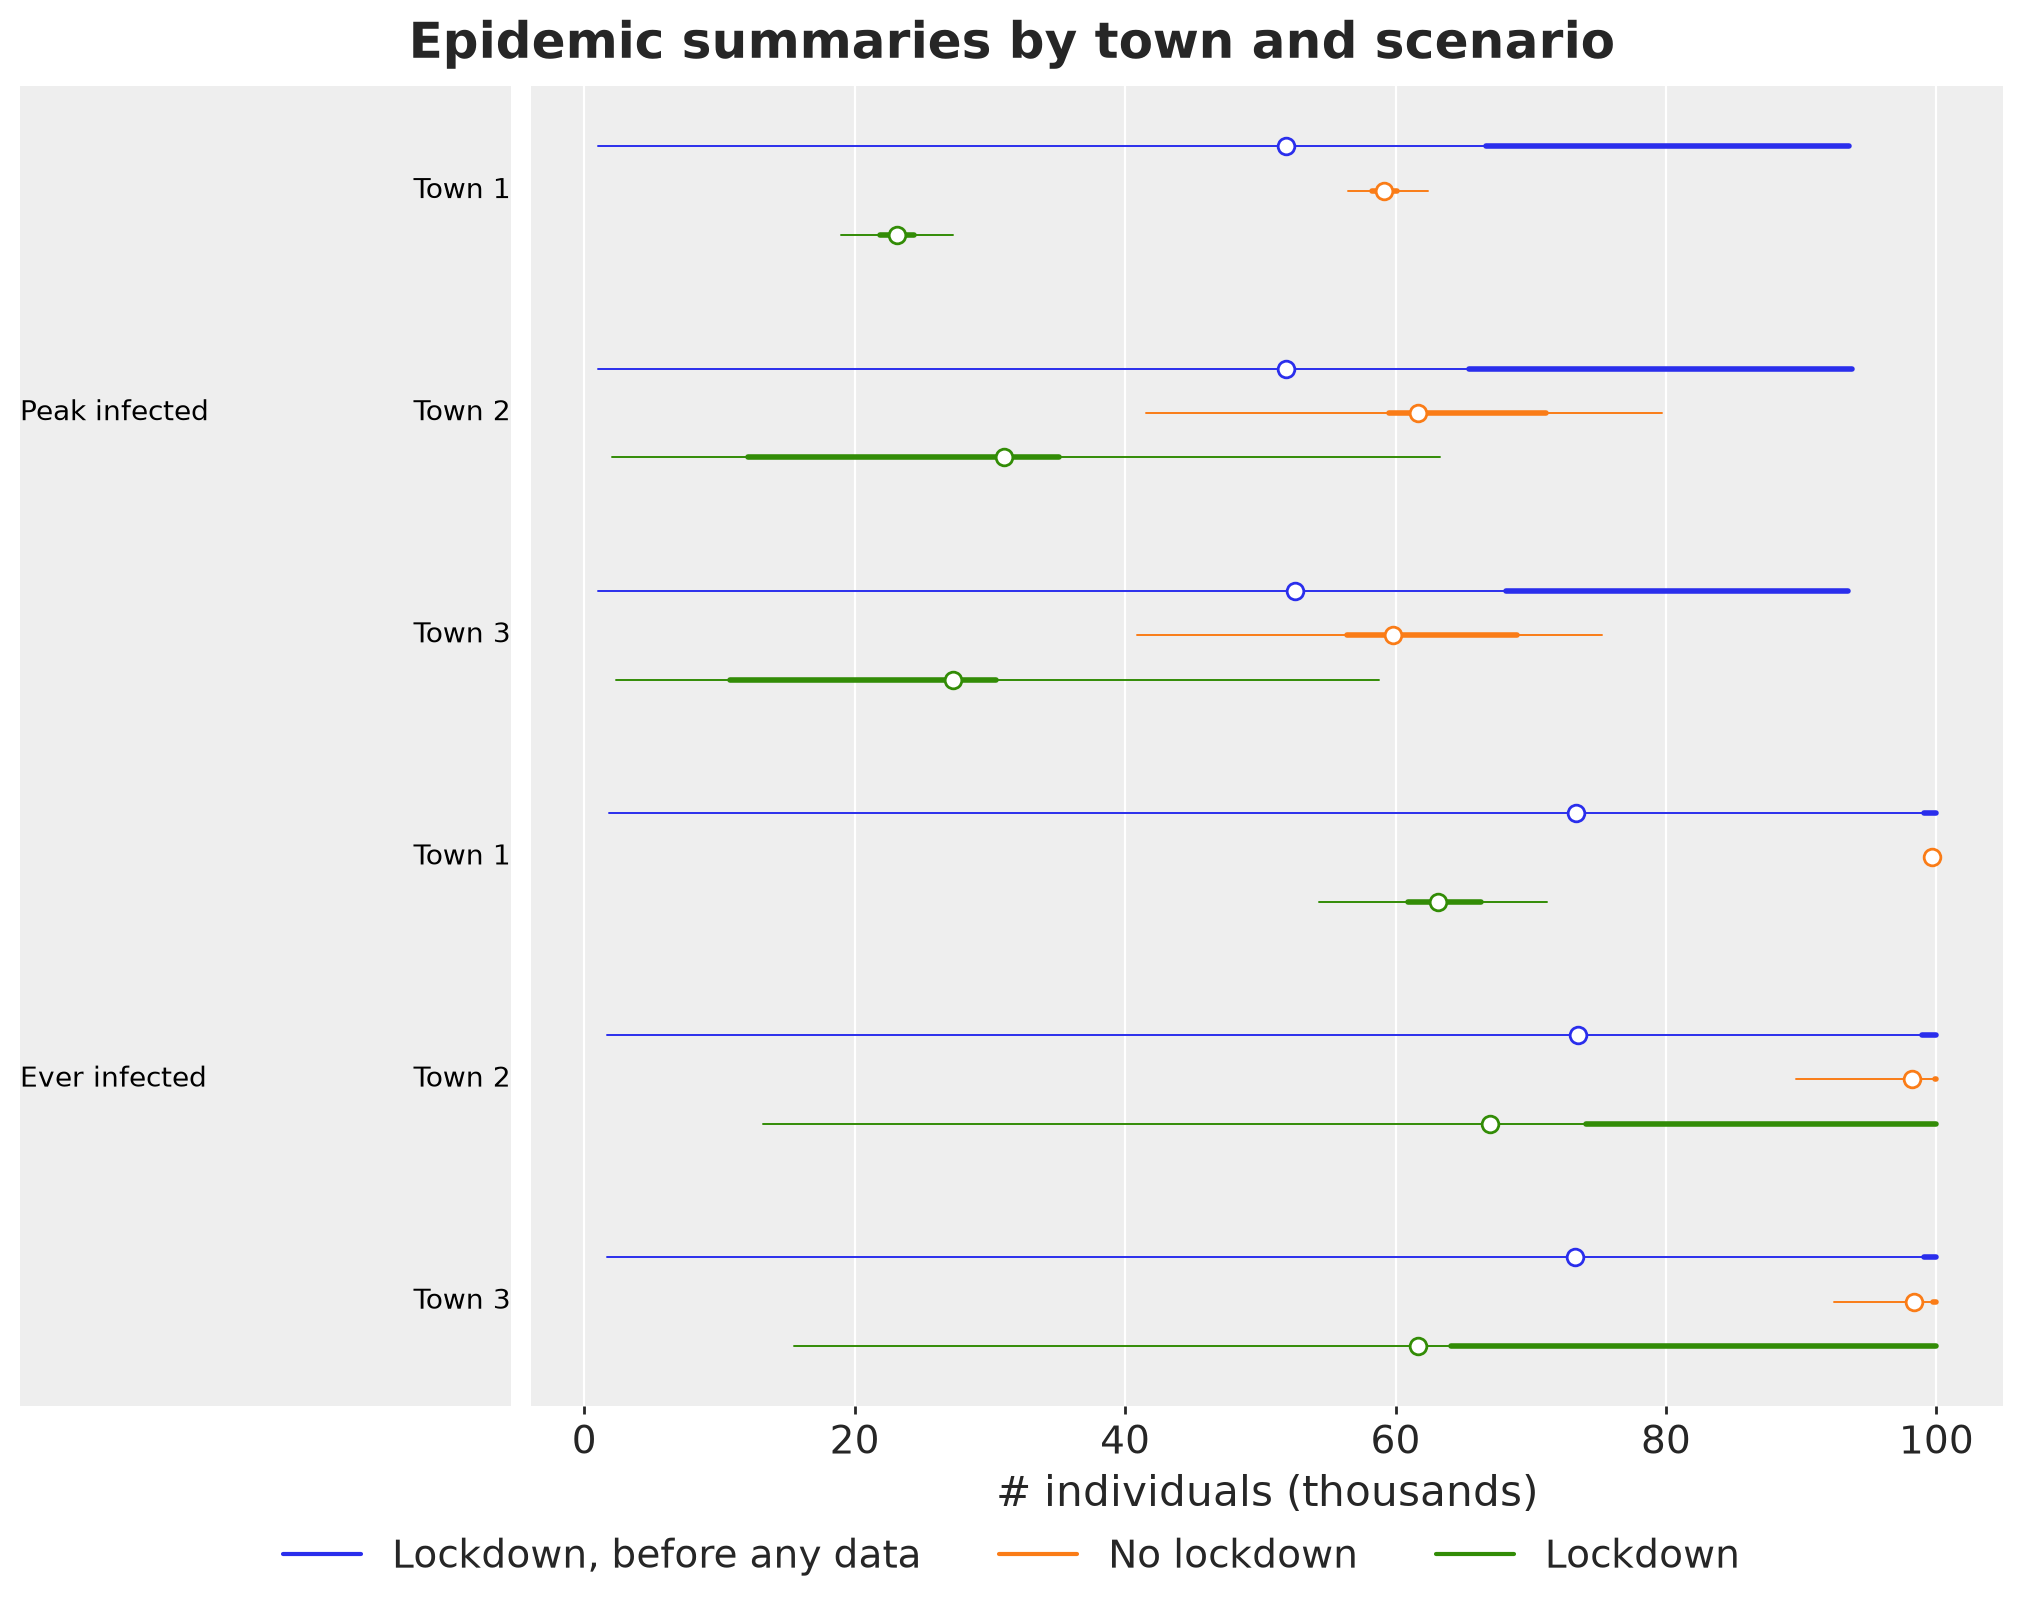

In [43]:
town_scenarios = {
    "Lockdown, before any data": intervened_towns_prior_samples,
    "No lockdown": towns_posterior_samples,
    "Lockdown": intervened_towns_posterior_samples,
}
plot_summaries(
    town_scenarios,
    title="Epidemic summaries by town and scenario",
    units="thousands",
    figsize=(10, 8),
    dims={"peak_infected": ["town"], "ever_infected": ["town"]},
    coords=TOWN_COORDS,
);

Before any data, the three towns are interchangeable and every interval is wide. The measurements of Town 1 make its own intervals narrow. For Towns 2 and 3 they help less, and how much depends on the question. Without a lockdown, almost everyone is infected by the end of the forecast whatever the exact rates, so the number ever infected is well predicted in every town. Under the lockdown, the outcome is sensitive to the infection rate, which the data of Town 1 only partly pin down for Towns 2 and 3, so their intervals stay wide. In every town, the lockdown lowers both summaries.

## Conclusion

Let's recap what we did and what we learned.

We ported two ChiRho tutorials to NumPyro and Diffrax. The only new code is a simulator that solves an ODE in segments: it stops at the first zero crossing of an event function, overwrites part of the state, and continues. A static intervention is an event function of time alone, and a state-dependent one is any other event function. Everything else is standard NumPyro: `condition` attaches the measurements, SVI fits the rates, `Predictive` propagates the posterior through the simulator, and `jax.vmap` maps the simulator over towns.

### Key Findings

- **The port reproduces both tutorials.** With the same priors, the same inference settings and the same interventions, the posterior of the rates, the predicted trajectories and the effect of every lockdown agree with the originals.
- **One compiled simulator serves every question.** The simulator is compiled once per dynamics and set of event functions. Other parameter draws, lockdown dates, strengths or triggers reuse the compiled program, so sweeping the strength of a lockdown only costs the ODE solves.
- **State-dependent policies change the shape of the answer.** A lockdown at fixed dates delays the epidemic: the infections grow again once it is lifted and are still growing at the end of the forecast. A lockdown triggered by the number of infected holds the peak near its trigger whatever the rates are.
- **Measurements in one town tighten the predictions in the others.** Under the hierarchical prior, most of the uncertainty about a town's rates is uncertainty about the global means. The measurements of Town 1 pin down the global means, and the predictions for Towns 2 and 3 narrow, with and without a lockdown.

### Model Limitations

- **The dynamics are deterministic and the model is correct.** The data were simulated from the same SIR equations that we fit. On real data the model is misspecified, and the measurements carry more than Poisson noise.
- **There are no unobserved confounders of the parameters.** The rates are not influenced by anything that also influences the measurements. The original tutorials make the same assumption.
- **The posterior is a Gaussian approximation.** SVI with a multivariate normal guide can be overconfident, in particular for the town-level rates of the towns without data.
- **The interventions apply to every town at once.** `simulate_towns` maps over parameters and initial states, not over interventions.

### Recommendations

1. **Keep the dynamics and the event functions pure.** Pass the parameters and the thresholds as arguments, so that JAX can trace them and the simulator compiles once.
2. **Compile the predictive distribution.** Wrap `Predictive` in `jax.jit` whenever you ask several what-if questions of the same program.
3. **Keep the number of segments fixed.** Each intervention fires at most once, so $n$ interventions need at most $n + 1$ segments. A fixed count is what lets `lax.fori_loop` trace the solver once and keeps the simulator differentiable.

## Next Steps

1. **Town-specific policies.** Lockdowns that start at different times in each town only require mapping over the interventions as well as over the parameters. `eqx.filter_vmap` maps over the arrays inside each `Intervention` and leaves its event function alone.
2. **Covariates on the rates.** As the original tutorial notes, the town-level rates could be correlated according to geographic proximity, or regressed on covariates of each town.
3. **MCMC instead of SVI.** The simulator is differentiable, so NUTS applies without changes and would give a check on the Gaussian approximation of the posterior.

## References

- ChiRho, [Causal reasoning in dynamical systems](https://basisresearch.github.io/chirho/dynamical_intro.html). The tutorial the first part ports.
- ChiRho, [Hierarchical Bayesian models with dynamical systems](https://basisresearch.github.io/chirho/dynamical_multi.html). The tutorial the second part ports.
- Diffrax, [Events](https://docs.kidger.site/diffrax/api/events/). The event API used by the simulator.
- NumPyro, [Effect handlers](https://num.pyro.ai/en/stable/handlers.html). `condition`, `seed` and `trace`.
- Generable, [Fitting a basic SIR model in Stan](https://www.generable.com/post/fitting-a-basic-sir-model-in-stan).
- Moll, B. (2020). [Lockdowns in SIR models](https://benjaminmoll.com/wp-content/uploads/2020/05/SIR_notes.pdf).
- Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., and Rubin, D. B. (2013). *Bayesian Data Analysis*, third edition. Chapman and Hall/CRC.